# WP6: 3 stages optimization tool

## 1. Importing libraries and dataset

In [7]:
import numpy as np
import math
import os

# Install pyarrow if not already installed
import subprocess
import sys

try:
    import pyarrow
    print("pyarrow is already installed")
except ImportError:
    print("Installing pyarrow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--user", "pyarrow", "-q"])
    print("pyarrow installed successfully!")
    print("NOTE: If you encounter extension type errors, restart the kernel (Kernel -> Restart)")

pyarrow is already installed


### 1.1 Importing TokWise´s parquet data, and aFRR data.

TokWise's data

In [9]:
import pandas as pd
from pathlib import Path
import pyarrow.parquet as pq

parquet_path = Path.cwd() / "filtered_solar_data.parquet"  # same folder as this notebook when run from its directory

# Workaround for pyarrow extension type conflict: use pyarrow directly then convert to pandas
# This avoids pandas' extension type registration that causes conflicts
table = pq.read_table(parquet_path)
df = table.to_pandas()

# Rename columns to match what the notebook expects
df = df.rename(columns={
    "DayAheadPrice":                             "DA",
    "IntradayVolumeWeightedAveragePrice":        "closest_VWAP",
    "ImbalanceSettlementPrice":                  "ISP",
    "IntradayForecastCreationtLeadTimeMinutes":  "lead_time",
    "Capacity_kWh":                              "Capacity",
})

# Convert kWh columns to MWh so units match the rest of the notebook
df["fc_mwh_curr"] = df["Intraday_Forecast_kWh"] / 1000
df["act_mwh"]     = df["Generation_kWh"] / 1000


# Diagnostic: Check date range in raw data
print(f"Raw dataset info:")
print(f"  Total rows: {len(df)}")
if 'PeriodStartUTC' in df.columns:
    print(f"  Date range (UTC): {df['PeriodStartUTC'].min()} to {df['PeriodStartUTC'].max()}")


Raw dataset info:
  Total rows: 35014
  Date range (UTC): 2024-12-31 23:45:00+00:00 to 2025-12-30 23:45:00+00:00


In [11]:
print(df.groupby('SolarId').agg(
    Capacity=('Capacity', 'first'),
    Rows=('PeriodStartUTC', 'count'),
    Max_Generation_kWh=('Generation_kWh', 'max')
).sort_values('Capacity', ascending=False))

          Capacity   Rows  Max_Generation_kWh
SolarId                                      
Solar_04      1411  35014              1222.5


In [13]:
df_full = pd.read_parquet('full_dataset_ino_energy_final.parquet')
print(df_full.columns.tolist())
print(df_full.groupby('SolarId').agg(
    Capacity=('Capacity_kWh', 'first'),
    Rows=('PeriodStartUTC', 'count')
).sort_values('Capacity', ascending=False).head(10))

['PeriodStartUTC', 'PeriodStartLocal', 'IntradayForecastCreationtLeadTimeMinutes', 'SolarId', 'Capacity_kWh', 'Intraday_Forecast_kWh', 'DayAhead_Forecast_kWh', 'Generation_kWh', 'IntradayVolumeWeightedAveragePrice', 'DayAheadPrice', 'ImbalanceSettlementPrice']
          Capacity    Rows
SolarId                   
Solar_07      3163  437658
Solar_10      1863  437658
Solar_04      1411  437658
Solar_08      1289  437658
Solar_02      1015  437658
Solar_09       745  437658
Solar_12       709  437658
Solar_03       693  437658
Solar_11       684  437658
Solar_06       571  437658


In [14]:
df_full = pd.read_parquet('full_dataset_ino_energy_final.parquet')
print(df_full.groupby('SolarId').agg(
    Capacity_kW=('Capacity_kWh', 'first'),
    Missing_Generation=('Generation_kWh', lambda x: x.isna().sum()),
    Missing_Forecast=('Intraday_Forecast_kWh', lambda x: x.isna().sum()),
    Total_Rows=('PeriodStartUTC', 'count')
).sort_values('Capacity_kW', ascending=False))

          Capacity_kW  Missing_Generation  Missing_Forecast  Total_Rows
SolarId                                                                
Solar_07         3163                6959                 0      437658
Solar_10         1863                  27                 0      437658
Solar_04         1411                   0                 0      437658
Solar_08         1289                5496                 0      437658
Solar_02         1015                1236                 0      437658
Solar_09          745                1535                 0      437658
Solar_12          709                  14                 0      437658
Solar_03          693                   0                 0      437658
Solar_11          684                  26                 0      437658
Solar_06          571                1328                 0      437658
Solar_01          336                1225                 0      437658
Solar_05          275                 100                 0     

In [16]:
print(df.columns.tolist())

['PeriodStartUTC', 'PeriodStartLocal', 'lead_time', 'SolarId', 'Capacity', 'Intraday_Forecast_kWh', 'DayAhead_Forecast_kWh', 'Generation_kWh', 'closest_VWAP', 'DA', 'ISP', 'fc_mwh_curr', 'act_mwh']


aFRR data

In [18]:
import os
# Define the folder name
folder = "Market_data"

BCap_p = pd.read_excel(os.path.join(folder, "RESULT_OVERVIEW_CAPACITY_MARKET_aFRR_2025-10-05_2025-10-05.xlsx"))
EAM_price_data = pd.read_parquet(os.path.join(folder,"aFRR_EAM_optimal_bids_2025_10_05"))

C:\Users\hp\anaconda3\lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


Convert aFRR data to standard format

In [22]:
# 1. Extract the direction (POS/NEG) and the Hour from Column 3
# Column 3 (index 3) format: "POS_00_04"
direction = BCap_p.iloc[:, 3].str[:3]      # Gets "POS" or "NEG"
hour_str = BCap_p.iloc[:, 3].str[4:6]       # Gets "00"

# 3. Create the combined datetime
# We take the date from Column 0 and add the extracted hour
BCap_p['PeriodStartLocal'] = pd.to_datetime(
    BCap_p.iloc[:, 0].astype(str) + ' ' + hour_str + ':00:00'
).dt.tz_localize("Europe/Berlin")

# 4. Get the numerical value from Column J (Index 9), which is the marginal price of activation [(EUR/MWh)/h] i.e. the highest priced bid cleared.
BCap_p['BCap_price'] = pd.to_numeric(BCap_p.iloc[:, 9], errors='coerce')

# 5. Split into two DataFrames based on the direction
BCap_Pos_p = BCap_p[direction == "POS"][['PeriodStartLocal', 'BCap_price']].copy()
BCap_Neg_p = BCap_p[direction == "NEG"][['PeriodStartLocal', 'BCap_price']].copy()

# 6. Clean up indices
BCap_Pos_p.reset_index(drop=True, inplace=True)
BCap_Neg_p.reset_index(drop=True, inplace=True)

print("Negative Capacity Head:")
BCap_Neg_p.head(6)

Negative Capacity Head:


,PeriodStartLocal,BCap_price
0,2025-10-05 00:00:00+02:00,16.47
1,2025-10-05 04:00:00+02:00,16.01
2,2025-10-05 08:00:00+02:00,34.99
3,2025-10-05 12:00:00+02:00,60.72
4,2025-10-05 16:00:00+02:00,24.95
5,2025-10-05 20:00:00+02:00,8.00


Convert BCap data to quarterly data, for easier model handling, and latter the constraints will be set so bid periods act as blocks of 4 hours.

In [26]:
import pandas as pd

# Ensure PeriodStartLocal is datetime and tz-aware
BCap_Neg_p["PeriodStartLocal"] = pd.to_datetime(BCap_Neg_p["PeriodStartLocal"])
if BCap_Neg_p["PeriodStartLocal"].dt.tz is None:
    BCap_Neg_p["PeriodStartLocal"] = BCap_Neg_p["PeriodStartLocal"].dt.tz_localize("Europe/Berlin")

# Determine the day (date) for the data
day_start = BCap_Neg_p["PeriodStartLocal"].dt.normalize().iloc[0]
day_end = day_start + pd.Timedelta(days=1)  # next day

# Create full quarter-hourly index for the entire day (96 periods)
full_index = pd.date_range(
    start=day_start,
    end=day_end,
    freq="15T",
    tz="Europe/Berlin",
    inclusive="left"  # replace closed='left'
)

# Set original data index
BCap_Neg_p = BCap_Neg_p.set_index("PeriodStartLocal")

# Reindex to full day and forward-fill
BCap_Neg_p = BCap_Neg_p.reindex(full_index).ffill().reset_index()
BCap_Neg_p.rename(columns={"index": "PeriodStartLocal"}, inplace=True)

BCap_Neg_p.tail()

C:\Users\hp\AppData\Local\Temp\ipykernel_18500\4090918996.py:13: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(


,PeriodStartLocal,BCap_price
91,2025-10-05 22:45:00+02:00,8.0
92,2025-10-05 23:00:00+02:00,8.0
93,2025-10-05 23:15:00+02:00,8.0
94,2025-10-05 23:30:00+02:00,8.0
95,2025-10-05 23:45:00+02:00,8.0


In [28]:
EAM_price_data.head()

,Date,period,bid_price,n_hist_obs,activation_probability,expected_price_term_eur_per_mwh,expected_eam_compensation_coeff_eur_per_mw_per_interval,expected_activated_energy_mwh,expected_eam_compensation_eur
0,2025-10-05,1,16.62,1,1.0,16.62,4.1550,0.25,4.1550
1,2025-10-05,2,29.70,1,1.0,29.70,7.4250,0.25,7.4250
2,2025-10-05,3,9.89,1,1.0,9.89,2.4725,0.25,2.4725
3,2025-10-05,4,100.14,1,1.0,100.14,25.0350,0.25,25.0350
4,2025-10-05,5,26.56,1,1.0,26.56,6.6400,0.25,6.6400


In [30]:
import pandas as pd

# Copy to avoid modifying original
EAM_p = EAM_price_data.copy()

# Ensure Date is datetime
EAM_p["Date"] = pd.to_datetime(EAM_p["Date"])

# Convert period (1–96) → minutes offset
EAM_p["PeriodStartLocal"] = (
    EAM_p["Date"]
    + pd.to_timedelta((EAM_p["period"] - 1) * 15, unit="m")
)

# Localize to Berlin timezone (handles CET/CEST automatically)
EAM_p["PeriodStartLocal"] = (
    EAM_p["PeriodStartLocal"]
    .dt.tz_localize("Europe/Berlin", ambiguous="infer", nonexistent="shift_forward")
)

# Select + rename columns
EAM_p = EAM_p[[
    "PeriodStartLocal",
    "expected_price_term_eur_per_mwh",
    "expected_activated_energy_mwh"
]].rename(columns={
    "expected_price_term_eur_per_mwh": "EAM_price"
})

In [32]:
EAM_p.head()

,PeriodStartLocal,EAM_price,expected_activated_energy_mwh
0,2025-10-05 00:00:00+02:00,16.62,0.25
1,2025-10-05 00:15:00+02:00,29.70,0.25
2,2025-10-05 00:30:00+02:00,9.89,0.25
3,2025-10-05 00:45:00+02:00,100.14,0.25
4,2025-10-05 01:00:00+02:00,26.56,0.25


### 1.2 Reading and understanding the dataset

In [35]:
# Display first 10 rows
df.head()

,PeriodStartUTC,PeriodStartLocal,lead_time,SolarId,Capacity,Intraday_Forecast_kWh,DayAhead_Forecast_kWh,Generation_kWh,closest_VWAP,DA,ISP,fc_mwh_curr,act_mwh
0,2024-12-31 23:45:00+00:00,2025-01-01 00:45:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,NaN,2.16,310.81,0.0,0.0
1,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,178.45,1.60,180.13,0.0,0.0
2,2025-01-01 00:15:00+00:00,2025-01-01 01:15:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,83.87,1.60,119.78,0.0,0.0
3,2025-01-01 00:30:00+00:00,2025-01-01 01:30:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,58.40,1.60,294.04,0.0,0.0
4,2025-01-01 00:45:00+00:00,2025-01-01 01:45:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,42.65,1.60,235.55,0.0,0.0


In [37]:
df.tail()

,PeriodStartUTC,PeriodStartLocal,lead_time,SolarId,Capacity,Intraday_Forecast_kWh,DayAhead_Forecast_kWh,Generation_kWh,closest_VWAP,DA,ISP,fc_mwh_curr,act_mwh
35009,2025-12-30 22:45:00+00:00,2025-12-30 23:45:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,72.68,77.73,75.338791,0.0,0.0
35010,2025-12-30 23:00:00+00:00,2025-12-31 00:00:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,76.69,94.87,107.031562,0.0,0.0
35011,2025-12-30 23:15:00+00:00,2025-12-31 00:15:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,73.29,90.31,93.080824,0.0,0.0
35012,2025-12-30 23:30:00+00:00,2025-12-31 00:30:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,81.72,86.19,105.487133,0.0,0.0
35013,2025-12-30 23:45:00+00:00,2025-12-31 00:45:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,68.07,80.96,76.888895,0.0,0.0


In [39]:
df.dtypes

PeriodStartUTC           datetime64[ns, UTC]
PeriodStartLocal         datetime64[ns, CET]
lead_time                              int64
SolarId                               object
Capacity                               int64
Intraday_Forecast_kWh                float64
DayAhead_Forecast_kWh                float64
Generation_kWh                       float64
closest_VWAP                         float64
DA                                   float64
ISP                                  float64
fc_mwh_curr                          float64
act_mwh                              float64
dtype: object

In [41]:
df.describe()

,lead_time,Capacity,Intraday_Forecast_kWh,DayAhead_Forecast_kWh,Generation_kWh,closest_VWAP,DA,ISP,fc_mwh_curr,act_mwh
count,35014.0,35014.0,35014.000000,35014.000000,35014.000000,33623.000000,34998.000000,35000.000000,35014.000000,35014.000000
mean,20.0,1411.0,145.561968,183.109733,115.528378,89.903051,89.323151,90.678609,0.145562,0.115528
std,0.0,0.0,235.905831,290.941327,229.230289,84.613631,52.539049,138.872408,0.235906,0.229230
min,20.0,1411.0,0.000000,0.000000,0.000000,-740.980000,-250.320000,-4390.790000,0.000000,0.000000
25%,20.0,1411.0,0.000000,0.000000,0.000000,65.620000,70.465000,43.630000,0.000000,0.000000
50%,20.0,1411.0,0.000000,0.770000,0.000000,90.530000,92.370000,87.350000,0.000000,0.000000
75%,20.0,1411.0,222.750000,278.625000,116.812500,115.890000,114.240000,128.030534,0.222750,0.116812
max,20.0,1411.0,1263.250000,1397.298000,1222.500000,3553.970000,583.400000,5399.930000,1.263250,1.222500


## 2. Data cleaning and prices extrapolation

In [45]:
# Ensure PeriodStartUTC is UTC-aware
df["PeriodStartUTC"] = pd.to_datetime(df["PeriodStartUTC"], utc=True)

# Convert to local time and store in new column
df["PeriodStartLocal"] = df["PeriodStartUTC"].dt.tz_convert("Europe/Berlin")

df.head()

,PeriodStartUTC,PeriodStartLocal,lead_time,SolarId,Capacity,Intraday_Forecast_kWh,DayAhead_Forecast_kWh,Generation_kWh,closest_VWAP,DA,ISP,fc_mwh_curr,act_mwh
0,2024-12-31 23:45:00+00:00,2025-01-01 00:45:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,NaN,2.16,310.81,0.0,0.0
1,2025-01-01 00:00:00+00:00,2025-01-01 01:00:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,178.45,1.60,180.13,0.0,0.0
2,2025-01-01 00:15:00+00:00,2025-01-01 01:15:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,83.87,1.60,119.78,0.0,0.0
3,2025-01-01 00:30:00+00:00,2025-01-01 01:30:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,58.40,1.60,294.04,0.0,0.0
4,2025-01-01 00:45:00+00:00,2025-01-01 01:45:00+01:00,20,Solar_04,1411,0.0,0.0,0.0,42.65,1.60,235.55,0.0,0.0


In [47]:
DA_p = (
    df[["PeriodStartLocal", "DA"]]
      .drop_duplicates(subset=["PeriodStartLocal"])
      .rename(columns={"DA": "DA_price"})
)

DA_p.head()


,PeriodStartLocal,DA_price
0,2025-01-01 00:45:00+01:00,2.16
1,2025-01-01 01:00:00+01:00,1.60
2,2025-01-01 01:15:00+01:00,1.60
3,2025-01-01 01:30:00+01:00,1.60
4,2025-01-01 01:45:00+01:00,1.60


In [49]:
# Use closest_VWAP as the latest intraday market price observed
# before the delivery interval, representing the market’s
# expectation of the intraday price at the decision time

ID_p = df.copy()

ID_p = (
    ID_p[["PeriodStartLocal", "closest_VWAP", "lead_time"]]
      .sort_values(["PeriodStartLocal", "lead_time"])          # closest first
      .drop_duplicates(subset=["PeriodStartLocal"], keep="first")
      .rename(columns={
                       "closest_VWAP": "ID_price"})[["PeriodStartLocal", "ID_price"]]
    .sort_values("PeriodStartLocal")
      .reset_index(drop=True)
)

# Fill any NaN ID prices with zero
ID_p["ID_price"] = ID_p["ID_price"].fillna(0)


ID_p.head()

,PeriodStartLocal,ID_price
0,2025-01-01 00:45:00+01:00,0.00
1,2025-01-01 01:00:00+01:00,178.45
2,2025-01-01 01:15:00+01:00,83.87
3,2025-01-01 01:30:00+01:00,58.40
4,2025-01-01 01:45:00+01:00,42.65


In [51]:
#Load the imbalance prices, not known until after the period is over.
Imb_p = (
    df[["PeriodStartLocal", "ISP"]]
      .drop_duplicates(subset=["PeriodStartLocal"])
      .rename(columns={"ISP": "Imb_price"})
)

Imb_p.head()

,PeriodStartLocal,Imb_price
0,2025-01-01 00:45:00+01:00,310.81
1,2025-01-01 01:00:00+01:00,180.13
2,2025-01-01 01:15:00+01:00,119.78
3,2025-01-01 01:30:00+01:00,294.04
4,2025-01-01 01:45:00+01:00,235.55


In [53]:
Imb_p.tail()

,PeriodStartLocal,Imb_price
35009,2025-12-30 23:45:00+01:00,75.338791
35010,2025-12-31 00:00:00+01:00,107.031562
35011,2025-12-31 00:15:00+01:00,93.080824
35012,2025-12-31 00:30:00+01:00,105.487133
35013,2025-12-31 00:45:00+01:00,76.888895


Below is the calculation of the EEG subsidies, based on publicly available data on the market premium (https://www.bundesnetzagentur.de/DE/Fachthemen/ElektrizitaetundGas/ErneuerbareEnergien/EEG_Foerderung/start.html ), for which the average value of all 2025 bidding rounds is taken, and on the monthly market values (https://www.netztransparenz.de/en/Renewable-energies-and-levies/EEG/Transparency-requirements/Market-premium/Market-value-overview ). Whilst the market values are published after trading, for simplicity we assume that these values are known to quantify the expected subsidy. In reality, this could be possible through forecasting tools, or simply replacing the actual market value by a realistic assumption.

In [56]:
# Market values in EUR/MWh by month (example values)
market_values_2025 = {
    1: 115.11,   # January
    2: 110.99,   # February
    3: 50.27,
    4: 30.41,
    5: 19.97,
    6: 18.43,
    7: 59.23,
    8: 38.32,
    9: 43.07,
    10: 69.8,  # October
    11: 91.02,
    12: 93.73
}

reference_value_2025 = 0.1016 * 1000,  # 101.6 EUR/MWh

In [58]:
def add_market_premium(DA_p: pd.DataFrame,
                       periods_per_hour: int,
                       reference_value: float,
                       market_values: dict) -> pd.DataFrame:
    """
    Adds a 'market premium' column using monthly market values.

    Parameters
    ----------
    DA_p : pd.DataFrame
        Must contain:
        - 'PeriodStartLocal'
        - 'DA_price'
    periods_per_hour : int
        Min number of consecutive periods from which the EEG subsidy 
        does not apply. (Currently 1 period, which is 15 min)
    reference_value : float
        Reference EEG value (EUR/MWh)
    market_values : dict
        Dictionary mapping month (1-12) to market value (EUR/MWh)

    Returns
    -------
    pd.DataFrame
    """

    df = DA_p.copy()

    # Ensure datetime
    df["PeriodStartLocal"] = pd.to_datetime(df["PeriodStartLocal"])

    # Sort chronologically
    df = df.sort_values("PeriodStartLocal").reset_index(drop=True)

    # Extract month
    df["month"] = df["PeriodStartLocal"].dt.month

    # Map monthly market values
    df["market_value"] = df["month"].map(market_values)

    # Calculate monthly premium
    df["market premium"] = np.maximum(reference_value - df["market_value"], 0)

    # Detect negative price periods
    negative = df["DA_price"] < 0

    # Identify blocks of consecutive negatives
    group = (negative != negative.shift()).cumsum()
    block_sizes = negative.groupby(group).transform("sum")

    # Set premium to zero where consecutive negatives >= periods_per_hour
    df.loc[(negative) & (block_sizes >= periods_per_hour),
           "market premium"] = 0

    # Clean helper columns
    df = df.drop(columns=["DA_price", "month", "market_value"])

    return df

In [60]:
EEG_p = add_market_premium(
    DA_p=DA_p,
    periods_per_hour=1,
    reference_value = reference_value_2025,
    market_values=market_values_2025
)

EEG_p.head()

,PeriodStartLocal,market premium
0,2025-01-01 00:45:00+01:00,0.0
1,2025-01-01 01:00:00+01:00,0.0
2,2025-01-01 01:15:00+01:00,0.0
3,2025-01-01 01:30:00+01:00,0.0
4,2025-01-01 01:45:00+01:00,0.0


### 2.1 DA Price Forecast: Previous Day's Prices (Naive Persistence Forecast)

In [63]:
def generate_day_lag_price_forecast(df, lag_periods=96):
    """
    Creates price forecasts using previous day's actual prices (naive persistence).
    
    IMPORTANT: Input dataframe must be sorted chronologically for shift() to work correctly!
    
    Parameters:
    - df: DataFrame with columns [timestamp, price_column] - MUST BE SORTED BY TIMESTAMP
    - lag_periods: Number of periods to shift (96 = 1 day for quarter-hourly data)
    
    Returns:
    - DataFrame with actual prices and lagged forecasts
    """
    df_new = df.copy()
    target_col_name = df.columns[1]
    
    # Shift prices by 1 day (96 periods) to create forecast
    # For the first day, use the actual price (no previous day available)
    df_new[f"{target_col_name}_Forecast_1"] = df_new[target_col_name].shift(lag_periods)
    
    # Fill NaN values in the first day with the actual prices (fallback)
    df_new[f"{target_col_name}_Forecast_1"] = df_new[f"{target_col_name}_Forecast_1"].fillna(df_new[target_col_name])
    
    # Create Forecast_2 as duplicate of Forecast_1 (same persistence forecast)
    df_new[f"{target_col_name}_Forecast_2"] = df_new[f"{target_col_name}_Forecast_1"]
    
    # Return forecast columns
    cols_to_return = [f"{target_col_name}_Forecast_1", f"{target_col_name}_Forecast_2"]
    return df_new[[df.columns[0], target_col_name] + cols_to_return]

print("DA Price Forecast Method: Using previous day's actual prices (lag = 96 periods)")

DA Price Forecast Method: Using previous day's actual prices (lag = 96 periods)


In [65]:
# NOTE: Forecast generation has been moved to Section 4 (before filtering)
# This ensures forecasts are generated from the full dataset including previous day's data
# The code below is kept for reference but not executed

# # Generate DA forecast using previous day's prices
# DA_p_forecasts = generate_day_lag_price_forecast(DA_p, lag_periods=96)

# For ID prices, keep synthetic forecasts (or use same method)
def generate_synthetic_price_forecasts(df, phi=0.9, base_error_scale=0.05):
    """
    Creates two synthetic forecasts using AR(1) noise and variance scaling.
    For ID market prices (kept for comparison).
    """
    df_new = df.copy()
    target_col_name = df.columns[1]
    actual_values = df.iloc[:, 1].values
    n = len(actual_values)

    sample_val = str(actual_values[0])
    if '.' in sample_val:
        precision = len(sample_val.split('.')[1])
    else:
        precision = 0
    
    def create_ar_noise(intensity):
        noise = np.zeros(n)
        innovation = np.random.normal(0, intensity, n) * (actual_values + 1.0)
        noise[0] = innovation[0]
        for t in range(1, n):
            noise[t] = phi * noise[t-1] + innovation[t]
        return noise

    noise_1 = create_ar_noise(base_error_scale * 0.5)
    df_new[f"{target_col_name}_Forecast_1"] = (actual_values + noise_1).round(precision)
    noise_2 = create_ar_noise(base_error_scale * 1.5)
    df_new[f"{target_col_name}_Forecast_2"] = (actual_values + noise_2).round(precision)
    
    cols_to_fix = [f"{target_col_name}_Forecast_1", f"{target_col_name}_Forecast_2"]
    return df_new[[df.columns[0], target_col_name] + cols_to_fix]

## 3. Solar generation data extrapolation from TokWise's dataset

In [68]:
# Select, for each delivery period, the snapshot closest to delivery start
# to align the latest available forecast with the corresponding actual outcome

Solar = (
    df[["PeriodStartLocal", "fc_mwh_curr", "act_mwh"]]
      .drop_duplicates(subset=["PeriodStartLocal"], keep="first")
      .sort_values("PeriodStartLocal")
      .rename(columns={
          "fc_mwh_curr": "Forecast [MW]",
          "act_mwh":     "Actual [MW]",
      })[["PeriodStartLocal", "Forecast [MW]", "Actual [MW]"]]
)
Solar.head()

,PeriodStartLocal,Forecast [MW],Actual [MW]
0,2025-01-01 00:45:00+01:00,0.0,0.0
1,2025-01-01 01:00:00+01:00,0.0,0.0
2,2025-01-01 01:15:00+01:00,0.0,0.0
3,2025-01-01 01:30:00+01:00,0.0,0.0
4,2025-01-01 01:45:00+01:00,0.0,0.0


In [70]:
# Extract capacity and convert to float and MW
capacity = float(df["Capacity"].iloc[0])/1000

Solar = Solar.assign(
    Forecast_Load_Factor_1=lambda d: d["Forecast [MW]"].astype(float) / capacity,
    Actual_Load_Factor=lambda d: d["Actual [MW]"].astype(float) / capacity,
)


Solar.head()

,PeriodStartLocal,Forecast [MW],Actual [MW],Forecast_Load_Factor_1,Actual_Load_Factor
0,2025-01-01 00:45:00+01:00,0.0,0.0,0.0,0.0
1,2025-01-01 01:00:00+01:00,0.0,0.0,0.0,0.0
2,2025-01-01 01:15:00+01:00,0.0,0.0,0.0,0.0
3,2025-01-01 01:30:00+01:00,0.0,0.0,0.0,0.0
4,2025-01-01 01:45:00+01:00,0.0,0.0,0.0,0.0


## 4. Selecting Data for Model Run

In [73]:
#The Model is ran for the selected time period, in this case one day to improve results interpretability
start = pd.Timestamp("2025-10-05 00:00:00")
end   = pd.Timestamp("2025-10-05 23:45:00")

# IMPORTANT: Reload full unfiltered data from raw dataset for forecast generation
# This ensures forecasts can use previous day's data (October 4th for October 5th analysis)
# KEY FIX: Data must be sorted chronologically before shift() operation to ensure correct day-lag
print("\n=== Reloading full price data from raw dataset ===")
DA_p_full = (
    df[["PeriodStartLocal", "DA"]]
      .drop_duplicates(subset=["PeriodStartLocal"])
      .rename(columns={"DA": "DA_price"})
      .sort_values("PeriodStartLocal")  # CRITICAL: Sort chronologically for shift() to work correctly!
      .reset_index(drop=True)
)

# IMPORTANT: Generate ID forecast from full dataset before filtering
# so shift(96) can access October 4th prices for October 5th forecast
ID_p_full = (
    df[["PeriodStartLocal", "closest_VWAP", "lead_time"]]
      .sort_values(["PeriodStartLocal", "lead_time"])
      .drop_duplicates(subset=["PeriodStartLocal"], keep="first")
      .rename(columns={"closest_VWAP": "ID_price"})[["PeriodStartLocal", "ID_price"]]
      .sort_values("PeriodStartLocal")
      .reset_index(drop=True)
)
ID_p_full["ID_price"] = ID_p_full["ID_price"].ffill().bfill()
ID_p_forecasts = generate_day_lag_price_forecast(ID_p_full, lag_periods=96)

# Generate forecasts from FULL unfiltered data to ensure October 4th prices are used
print("=== Generating price forecasts from full dataset ===")
DA_p_forecasts = generate_day_lag_price_forecast(DA_p_full, lag_periods=96)
ID_p_forecasts = generate_synthetic_price_forecasts(ID_p_full)
BCap_Neg_p_forecasts = generate_synthetic_price_forecasts(BCap_Neg_p)
EAM_p_forecasts = generate_synthetic_price_forecasts(EAM_p)
print("✓ Forecasts generated successfully! October 5th forecasts use October 4th actual prices.\n")

# Create a complete 15-minute interval index (96 periods)
complete_time_index = pd.date_range(start=start, end=end, freq='15min')
print(f"Created complete time index with {len(complete_time_index)} periods")

# Filter and align each dataframe for the selected day with complete time index
def filter_and_align(df, start, end, complete_index):
    df_copy = df.copy()
    df_copy["PeriodStartLocal"] = pd.to_datetime(df_copy["PeriodStartLocal"])
    
    # Handle timezone compatibility: if PeriodStartLocal is timezone-aware, convert start/end/complete_index to match
    if df_copy["PeriodStartLocal"].dt.tz is not None:
        # PeriodStartLocal is timezone-aware, convert start and end to match
        tz = df_copy["PeriodStartLocal"].dt.tz
        start = pd.Timestamp(start).tz_localize(tz) if start.tz is None else start.tz_convert(tz)
        end = pd.Timestamp(end).tz_localize(tz) if end.tz is None else end.tz_convert(tz)
        # Also convert complete_index to match timezone
        if complete_index.tz is None:
            complete_index = complete_index.tz_localize(tz)
        else:
            complete_index = complete_index.tz_convert(tz)
    
    df_copy = df_copy[(df_copy["PeriodStartLocal"] >= start) & (df_copy["PeriodStartLocal"] <= end)]
    
    # Sort by PeriodStartLocal to ensure monotonic index
    df_copy = df_copy.sort_values("PeriodStartLocal")
    
    # Set PeriodStartLocal as index and reindex to complete time index
    df_copy = df_copy.set_index("PeriodStartLocal")
    
    # Use reindex without method parameter, then ffill to fill missing values
    df_copy = df_copy.reindex(complete_index)
    # df_copy = df_copy.ffill()  # Forward fill any missing values - removed after comments
    # df_copy = df_copy.bfill()  # Backward fill any remaining NaN (e.g., at start) - removed after comments
    
    df_copy = df_copy.reset_index()
    df_copy = df_copy.rename(columns={'index': 'PeriodStartLocal'})
    
    return df_copy

# Now filter all data to the analysis day
DA_p = filter_and_align(DA_p_full, start, end, complete_time_index)
ID_p = filter_and_align(ID_p_full, start, end, complete_time_index)
DA_p_forecasts = filter_and_align(DA_p_forecasts, start, end, complete_time_index)
ID_p_forecasts = filter_and_align(ID_p_forecasts, start, end, complete_time_index)
EAM_p_forecasts = filter_and_align(EAM_p_forecasts, start, end, complete_time_index)
BCap_Neg_p_forecasts = filter_and_align(BCap_Neg_p_forecasts, start, end, complete_time_index)

# Regenerate EEG premium data from full dataset then filter
EEG_p_full = add_market_premium(
    DA_p=DA_p_full,
    periods_per_hour=1,
    reference_value=reference_value_2025,
    market_values=market_values_2025
)
EEG_p = filter_and_align(EEG_p_full, start, end, complete_time_index)

Solar = filter_and_align(Solar, start, end, complete_time_index)

print(f"\nFiltered data verification:")
print(f"  DA_p: {len(DA_p)} periods from {DA_p['PeriodStartLocal'].min()} to {DA_p['PeriodStartLocal'].max()}")
print(f"  ID_p: {len(ID_p)} periods from {DA_p['PeriodStartLocal'].min()} to {ID_p['PeriodStartLocal'].max()}")
print(f"  EAM_p: {len(EAM_p)} periods from {EAM_p['PeriodStartLocal'].min()} to {EAM_p['PeriodStartLocal'].max()}")
print(f"  BCap_Neg_p: {len(BCap_Neg_p)} periods from {BCap_Neg_p['PeriodStartLocal'].min()} to {BCap_Neg_p['PeriodStartLocal'].max()} converted data from 4h blocks to 15 min.")
print(f"  EEG_p: {len(EEG_p)} periods from {EEG_p['PeriodStartLocal'].min()} to {EEG_p['PeriodStartLocal'].max()}")
print(f"  Solar: {len(Solar)} periods from {DA_p['PeriodStartLocal'].min()} to {Solar['PeriodStartLocal'].max()}")

# Verify we have exactly 96 entries
assert len(DA_p) == 96, f"Expected 96 periods but got {len(DA_p)}"
assert len(ID_p) == 96, f"Expected 96 periods but got {len(ID_p)}"
assert len(EAM_p) == 96, f"Expected 96 periods but got {len(EAM_p)}"
assert len(BCap_Neg_p) == 96, f"Expected 96 periods but got {len(BCap_Neg_p)}"
assert len(EEG_p) == 96, f"Expected 96 periods but got {len(EEG_p)}"
assert len(Solar) == 96, f"Expected 96 periods but got {len(Solar)}"
print("\n✓ All dataframes have exactly 96 periods!")



=== Reloading full price data from raw dataset ===
=== Generating price forecasts from full dataset ===
✓ Forecasts generated successfully! October 5th forecasts use October 4th actual prices.

Created complete time index with 96 periods

Filtered data verification:
  DA_p: 96 periods from 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00
  ID_p: 96 periods from 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00
  EAM_p: 96 periods from 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00
  BCap_Neg_p: 96 periods from 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00 converted data from 4h blocks to 15 min.
  EEG_p: 96 periods from 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00
  Solar: 96 periods from 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00

✓ All dataframes have exactly 96 periods!


### Verify Correct Implementation of Forecast

In [76]:
# Verify that October 5th forecasts match October 4th actual prices
print("\n=== Verifying Naive Persistence Forecast ===")
print("Checking that October 5th forecasts = October 4th actual prices")

# Get October 4th actual prices from full dataset
oct4_start = pd.Timestamp("2025-10-04 00:00:00").tz_localize("Europe/Berlin")
oct4_end = pd.Timestamp("2025-10-04 23:45:00").tz_localize("Europe/Berlin")
oct4_data = DA_p_full[(DA_p_full['PeriodStartLocal'] >= oct4_start) & (DA_p_full['PeriodStartLocal'] <= oct4_end)]

# Get October 5th forecast from DA_p_forecasts
oct5_forecast = DA_p_forecasts[['PeriodStartLocal', 'DA_price_Forecast_1']]

# Compare
print(f"\nOctober 4th actual prices: {len(oct4_data)} periods")
print(f"  Mean: {oct4_data['DA_price'].mean():.2f} EUR/MWh")
print(f"  Min: {oct4_data['DA_price'].min():.2f}, Max: {oct4_data['DA_price'].max():.2f}")

print(f"\nOctober 5th forecast prices: {len(oct5_forecast)} periods")  
print(f"  Mean: {oct5_forecast['DA_price_Forecast_1'].mean():.2f} EUR/MWh")
print(f"  Min: {oct5_forecast['DA_price_Forecast_1'].min():.2f}, Max: {oct5_forecast['DA_price_Forecast_1'].max():.2f}")

# Check if they match
if len(oct4_data) == len(oct5_forecast):
    are_equal = (oct4_data['DA_price'].values == oct5_forecast['DA_price_Forecast_1'].values).all()
    if are_equal:
        print("\n✓ SUCCESS: October 5th forecasts exactly match October 4th actual prices!")
    else:
        # Check how close they are
        diff = abs(oct4_data['DA_price'].values - oct5_forecast['DA_price_Forecast_1'].values).mean()
        print(f"\n⚠ Mean absolute difference: {diff:.4f} EUR/MWh")
        print("Showing first few values for comparison:")
        comparison = pd.DataFrame({
            'Oct_4_Time': oct4_data['PeriodStartLocal'].iloc[:5].values,
            'Oct_4_Actual': oct4_data['DA_price'].iloc[:5].values,
            'Oct_5_Time': oct5_forecast['PeriodStartLocal'].iloc[:5].values,
            'Oct_5_Forecast': oct5_forecast['DA_price_Forecast_1'].iloc[:5].values
        })
        print(comparison)
else:
    print(f"\n⚠ Length mismatch: Oct 4 has {len(oct4_data)} periods, Oct 5 has {len(oct5_forecast)} periods")


=== Verifying Naive Persistence Forecast ===
Checking that October 5th forecasts = October 4th actual prices

October 4th actual prices: 96 periods
  Mean: -0.29 EUR/MWh
  Min: -5.02, Max: 4.02

October 5th forecast prices: 96 periods
  Mean: -0.29 EUR/MWh
  Min: -5.02, Max: 4.02

✓ SUCCESS: October 5th forecasts exactly match October 4th actual prices!


In [78]:
# More detailed verification - check the data structure
print("\n=== Detailed Data Inspection ===")
print(f"\nDA_p_forecasts shape: {DA_p_forecasts.shape}")
print(f"DA_p_forecasts columns: {DA_p_forecasts.columns.tolist()}")
print(f"\nFirst 5 rows of DA_p_forecasts:")
print(DA_p_forecasts.head())
print(f"\nDate range in DA_p_forecasts:")
print(f"  Min: {DA_p_forecasts['PeriodStartLocal'].min()}")
print(f"  Max: {DA_p_forecasts['PeriodStartLocal'].max()}")

print(f"\nDA_p (after filtering) shape: {DA_p.shape}")
print(f"DA_p columns: {DA_p.columns.tolist()}")
print(f"\nFirst 5 rows of DA_p:")
print(DA_p.head())

# Check if DA_price and DA_price_Forecast_1 are equal for October 5th
if 'DA_price' in DA_p_forecasts.columns:
    matching = (DA_p_forecasts['DA_price'].values == DA_p_forecasts['DA_price_Forecast_1'].values).sum()
    print(f"\n  Rows where actual = forecast: {matching} out of {len(DA_p_forecasts)}")
    
    print(f"\n  Actual prices mean: {DA_p_forecasts['DA_price'].mean():.2f} EUR/MWh")
    print(f"  Forecast prices mean: {DA_p_forecasts['DA_price_Forecast_1'].mean():.2f} EUR/MWh")


=== Detailed Data Inspection ===

DA_p_forecasts shape: (96, 4)
DA_p_forecasts columns: ['PeriodStartLocal', 'DA_price', 'DA_price_Forecast_1', 'DA_price_Forecast_2']

First 5 rows of DA_p_forecasts:
           PeriodStartLocal  DA_price  DA_price_Forecast_1  \
0 2025-10-05 00:00:00+02:00     -0.07                 2.93   
1 2025-10-05 00:15:00+02:00     -0.26                 0.10   
2 2025-10-05 00:30:00+02:00     -1.45                -0.05   
3 2025-10-05 00:45:00+02:00     -1.21                -0.08   
4 2025-10-05 01:00:00+02:00     -1.09                 0.00   

   DA_price_Forecast_2  
0                 2.93  
1                 0.10  
2                -0.05  
3                -0.08  
4                 0.00  

Date range in DA_p_forecasts:
  Min: 2025-10-05 00:00:00+02:00
  Max: 2025-10-05 23:45:00+02:00

DA_p (after filtering) shape: (96, 2)
DA_p columns: ['PeriodStartLocal', 'DA_price']

First 5 rows of DA_p:
           PeriodStartLocal  DA_price
0 2025-10-05 00:00:00+02:00     

In [80]:
# Check what the shift is actually doing
print("\n=== Investigating the shift operation ===")

# Manually check October 4th and 5th in the full dataset
oct4_start = pd.Timestamp("2025-10-04 00:00:00").tz_localize("Europe/Berlin") 
oct4_end = pd.Timestamp("2025-10-04 23:45:00").tz_localize("Europe/Berlin")
oct5_start = pd.Timestamp("2025-10-05 00:00:00").tz_localize("Europe/Berlin")
oct5_end = pd.Timestamp("2025-10-05 23:45:00").tz_localize("Europe/Berlin")

# Get the data from full dataset
oct4_full = DA_p_full[(DA_p_full['PeriodStartLocal'] >= oct4_start) & (DA_p_full['PeriodStartLocal'] <= oct4_end)].copy()
oct5_full = DA_p_full[(DA_p_full['PeriodStartLocal'] >= oct5_start) & (DA_p_full['PeriodStartLocal'] <= oct5_end)].copy()

oct4_full = oct4_full.sort_values('PeriodStartLocal').reset_index(drop=True)
oct5_full = oct5_full.sort_values('PeriodStartLocal').reset_index(drop=True)

print(f"\nOctober 4th in full dataset:")
print(f"  Rows: {len(oct4_full)}")
print(f"  Mean price: {oct4_full['DA_price'].mean():.2f} EUR/MWh")
print(f"  First 3 prices: {oct4_full['DA_price'].iloc[:3].values}")

print(f"\nOctober 5th in full dataset:")
print(f"  Rows: {len(oct5_full)}")
print(f"  Mean price: {oct5_full['DA_price'].mean():.2f} EUR/MWh")
print(f"  First 3 prices: {oct5_full['DA_price'].iloc[:3].values}")

# Now check what indices they occupy in DA_p_full sorted
DA_p_full_sorted = DA_p_full.sort_values('PeriodStartLocal').reset_index(drop=True)
oct4_indices = DA_p_full_sorted[
    (DA_p_full_sorted['PeriodStartLocal'] >= oct4_start) & 
    (DA_p_full_sorted['PeriodStartLocal'] <= oct4_end)
].index
oct5_indices = DA_p_full_sorted[
    (DA_p_full_sorted['PeriodStartLocal'] >= oct5_start) & 
    (DA_p_full_sorted['PeriodStartLocal'] <= oct5_end)
].index

print(f"\nOctober 4th index range in sorted full dataset: {oct4_indices.min()} to {oct4_indices.max()}")
print(f"October 5th index range in sorted full dataset: {oct5_indices.min()} to {oct5_indices.max()}")
print(f"Difference: {oct5_indices.min() - oct4_indices.min()} rows")

# Check if shift(96) from Oct 5 indices would get Oct 4
expected_oct4_start_idx = oct5_indices.min() - 96
print(f"\nIf we shift Oct 5 back by 96, we'd get index: {expected_oct4_start_idx}")
print(f"October 4th actually starts at index: {oct4_indices.min()}")
if expected_oct4_start_idx == oct4_indices.min():
    print("✓ Shift by 96 should correctly get October 4th!")
else:
    print(f"✗ Shift by 96 gets index {expected_oct4_start_idx}, but Oct 4 is at {oct4_indices.min()}")
    print(f"  Difference: {abs(expected_oct4_start_idx - oct4_indices.min())} rows")


=== Investigating the shift operation ===

October 4th in full dataset:
  Rows: 96
  Mean price: -0.29 EUR/MWh
  First 3 prices: [ 2.93  0.1  -0.05]

October 5th in full dataset:
  Rows: 96
  Mean price: 1.73 EUR/MWh
  First 3 prices: [-0.07 -0.26 -1.45]

October 4th index range in sorted full dataset: 26484 to 26579
October 5th index range in sorted full dataset: 26580 to 26675
Difference: 96 rows

If we shift Oct 5 back by 96, we'd get index: 26484
October 4th actually starts at index: 26484
✓ Shift by 96 should correctly get October 4th!


In [82]:
# Check if DA_p_full is sorted
print("\n=== Checking if DA_p_full is sorted ===")
is_sorted = (DA_p_full['PeriodStartLocal'].diff().dropna() >= pd.Timedelta(0)).all()
print(f"Is DA_p_full sorted chronologically? {is_sorted}")

if not is_sorted:
    print("\n✗ DA_p_full is NOT sorted! This explains why shift(96) doesn't work correctly.")
    print("The .shift() function shifts by row position, so if data is not in chronological order,")
    print("it will get the wrong day's prices.")
    
# Check the first few timestamps to see the ordering
print(f"\nFirst 10 timestamps in DA_p_full:")
print(DA_p_full['PeriodStartLocal'].iloc[:10].values)


=== Checking if DA_p_full is sorted ===
Is DA_p_full sorted chronologically? True

First 10 timestamps in DA_p_full:
['2024-12-31T23:45:00.000000000' '2025-01-01T00:00:00.000000000'
 '2025-01-01T00:15:00.000000000' '2025-01-01T00:30:00.000000000'
 '2025-01-01T00:45:00.000000000' '2025-01-01T01:00:00.000000000'
 '2025-01-01T01:15:00.000000000' '2025-01-01T01:30:00.000000000'
 '2025-01-01T01:45:00.000000000' '2025-01-01T02:00:00.000000000']


In [84]:
print(DA_p.head())
print(len(DA_p))
print(DA_p.tail())

           PeriodStartLocal  DA_price
0 2025-10-05 00:00:00+02:00     -0.07
1 2025-10-05 00:15:00+02:00     -0.26
2 2025-10-05 00:30:00+02:00     -1.45
3 2025-10-05 00:45:00+02:00     -1.21
4 2025-10-05 01:00:00+02:00     -1.09
96
            PeriodStartLocal  DA_price
91 2025-10-05 22:45:00+02:00      4.24
92 2025-10-05 23:00:00+02:00      4.88
93 2025-10-05 23:15:00+02:00      4.10
94 2025-10-05 23:30:00+02:00      3.96
95 2025-10-05 23:45:00+02:00      3.36


### Align Input Data

Then all data periods are aligned, including the forecasts.

In [88]:
# First, align all data to quarter-hourly periods
# Create a common time index based on DA prices (quarter-hourly)
# Use pd.DatetimeIndex to preserve timezone information
time_index_96 = pd.DatetimeIndex(DA_p['PeriodStartLocal'])
n_periods_96 = len(time_index_96)

# Align all price data to the common time index
def align_data_to_time(df, time_col='PeriodStartLocal', align_time=None, value_col=None):
    """Align dataframe to common time index using forward fill"""
    # Ensure align_time is a DatetimeIndex
    if not isinstance(align_time, pd.DatetimeIndex):
        align_time = pd.DatetimeIndex(align_time)
    
    # Convert time_col to datetime and ensure timezone compatibility
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # Handle timezone compatibility
    align_tz = align_time.tz
    df_tz = df[time_col].dt.tz
    
    if align_tz is not None and df_tz is None:
        df[time_col] = df[time_col].dt.tz_localize(align_tz)
    elif align_tz is None and df_tz is not None:
        df[time_col] = df[time_col].dt.tz_localize(None)
    elif align_tz is not None and df_tz is not None and align_tz != df_tz:
        df[time_col] = df[time_col].dt.tz_convert(align_tz)
    
    df_aligned = pd.DataFrame(index=align_time)
    df_aligned = df_aligned.join(df.set_index(time_col), how='left')
    if value_col:
        df_aligned = df_aligned[[value_col]].ffill()
    return df_aligned

# -----------------------------
# Align actual price data
# -----------------------------
DA_prices_actual = align_data_to_time(DA_p, value_col='DA_price', align_time=time_index_96)
DA_p_actual = DA_prices_actual.values.flatten()

ID_prices_actual = align_data_to_time(ID_p, value_col='ID_price', align_time=time_index_96)
ID_p_actual = ID_prices_actual.values.flatten()

Imb_prices_actual = align_data_to_time(Imb_p, value_col='Imb_price', align_time=time_index_96)
Imb_p_actual = Imb_prices_actual.values.flatten()

BCap_Neg_prices_actual = align_data_to_time(BCap_Neg_p, value_col='BCap_price', align_time=time_index_96)
BCap_Neg_p_actual = BCap_Neg_prices_actual.values.flatten()

EAM_prices_actual = align_data_to_time(EAM_p, value_col='EAM_price', align_time=time_index_96)
EAM_p_actual = EAM_prices_actual.values.flatten()

# Bug Solver
# Check if index name is already a column
if EEG_p.index.name is not None and EEG_p.index.name not in EEG_p.columns:
    EEG_p = EEG_p.reset_index()

# Optional: check result
print(EEG_p.head())

EEG_p = align_data_to_time(EEG_p, value_col='market premium', align_time=time_index_96)
EEG_p_actual = EEG_p.values.flatten()

# -----------------------------
# Align forecast 1 data
# -----------------------------
DA_prices_f1 = align_data_to_time(DA_p_forecasts, value_col='DA_price_Forecast_1', align_time=time_index_96)
DA_p_f1 = DA_prices_f1.values.flatten()

ID_prices_f1 = align_data_to_time(ID_p_forecasts, value_col='ID_price_Forecast_1', align_time=time_index_96)
ID_p_f1 = ID_prices_f1.values.flatten()

BCap_Neg_f1 = align_data_to_time(BCap_Neg_p_forecasts, value_col='BCap_price_Forecast_1', align_time=time_index_96)
BCap_Neg_p_f1 = BCap_Neg_f1.values.flatten()

EAM_f1 = align_data_to_time(EAM_p_forecasts, value_col='EAM_price_Forecast_1', align_time=time_index_96)
EAM_p_f1 = EAM_f1.values.flatten()

Solar_f1 = align_data_to_time(Solar[['PeriodStartLocal','Forecast_Load_Factor_1']], 
                              value_col='Forecast_Load_Factor_1', align_time=time_index_96)
Solar_f1_arr = Solar_f1.values.flatten()

# -----------------------------
# Align forecast 2 data
# -----------------------------
DA_prices_f2 = align_data_to_time(DA_p_forecasts, value_col='DA_price_Forecast_2', align_time=time_index_96)
DA_p_f2 = DA_prices_f2.values.flatten()

ID_prices_f2 = align_data_to_time(ID_p_forecasts, value_col='ID_price_Forecast_2', align_time=time_index_96)
ID_p_f2 = ID_prices_f2.values.flatten()

BCap_Neg_f2 = align_data_to_time(BCap_Neg_p_forecasts, value_col='BCap_price_Forecast_2', align_time=time_index_96)
BCap_Neg_p_f2 = BCap_Neg_f2.values.flatten()

EAM_f2 = align_data_to_time(EAM_p_forecasts, value_col='EAM_price_Forecast_2', align_time=time_index_96)
EAM_p_f2 = EAM_f2.values.flatten()

#USe forecast 1 of the solar in the same place as forecast 2, assuming they don´t deviate much from 9am to 12 pm.
Solar_f2 = align_data_to_time(Solar[['PeriodStartLocal','Forecast_Load_Factor_1']], 
                              value_col='Forecast_Load_Factor_1', align_time=time_index_96)
Solar_f2_arr = Solar_f2.values.flatten()

# -----------------------------
# Align actual Solar data
# -----------------------------
Solar_actual = align_data_to_time(Solar[['PeriodStartLocal', 'Actual_Load_Factor']], 
                                  value_col='Actual_Load_Factor', align_time=time_index_96)
Solar_actual_arr = Solar_actual.values.flatten()

# -----------------------------
# Calculate generation at each time step
# -----------------------------
Generation_actual = capacity * Solar_actual_arr
Generation_f1 = capacity * Solar_f1_arr
Generation_f2 = capacity * Solar_f2_arr

# -----------------------------
print(f"Time range of quarterly data: {time_index_96[0]} to {time_index_96[-1]}")
print(f"Number of periods (should be 96): {len(time_index_96)}")
assert len(time_index_96) == 96, f"Expected 96 periods but got {len(time_index_96)}"

           PeriodStartLocal  market premium
0 2025-10-05 00:00:00+02:00             0.0
1 2025-10-05 00:15:00+02:00             0.0
2 2025-10-05 00:30:00+02:00             0.0
3 2025-10-05 00:45:00+02:00             0.0
4 2025-10-05 01:00:00+02:00             0.0
Time range of quarterly data: 2025-10-05 00:00:00+02:00 to 2025-10-05 23:45:00+02:00
Number of periods (should be 96): 96


In [90]:
# ============================================================
# SCALE FACTOR: Multiply generation by 10 to simulate a
# larger asset that can participate in the aFRR market.
# 
# NOTE: The original Solar_04 asset (1.41 MW) cannot meet
# the German aFRR minimum bid of 1 MW after applying the
# 67% reservation margin (max aFRR bid = 0.25 MW < 1 MW).
# Scaling by 10 simulates a 14.1 MW asset where:
#   peak generation ~ 4.3 MW
#   max aFRR bid = 4.3 * 0.67 = 2.88 MW > 1 MW minimum
# This allows the model to demonstrate aFRR participation.
# ============================================================

SCALE_FACTOR = 10

Generation_f1     = Generation_f1     * SCALE_FACTOR
Generation_f2     = Generation_f2     * SCALE_FACTOR
Generation_actual = Generation_actual * SCALE_FACTOR
capacity          = capacity          * SCALE_FACTOR

print(f"Scale factor applied: {SCALE_FACTOR}x")
print(f"New capacity:             {capacity:.2f} MW")
print(f"New Generation_f2 max:    {max(Generation_f2):.2f} MW")
print(f"New max aFRR bid possible: {max(Generation_f2) * 0.67:.2f} MW")
print(f"aFRR minimum bid:          1.00 MW")
print(f"aFRR participation possible: {max(Generation_f2) * 0.67 >= 1.0}")

Scale factor applied: 10x
New capacity:             14.11 MW
New Generation_f2 max:    3.81 MW
New max aFRR bid possible: 2.55 MW
aFRR minimum bid:          1.00 MW
aFRR participation possible: True


## 5. Optimization Stages (3-stage model)

In [93]:
import pulp as pl

# Time sets - fixed at 96 quarter-hour periods
T = list(range(96))


### 5.1 Stage 1: Optimization with Forecast_2 data

Optimize DA, ID and aFRR markets, before the closing of the aFRR balancing capacity market (before 9 am of D-1)

In [97]:
print("\n=== STAGE 1: Optimization with Forecast_2 data ===")

aFRR_reservation_margin = 0.67

# Create the optimization model
model_stage1 = pl.LpProblem("Solar_Farm_Stage1", pl.LpMaximize)

# Decision variables (only DA and ID). The lower bound is set on 0, meaning
# that speculative trading by buying/over-selling energy in DA to be sold/bought 
# latter in ID to avoid imblanaces is not allowed.
DA_stage1 = pl.LpVariable.dicts("DA", T, lowBound=0, cat="Continuous")
ID_stage1 = pl.LpVariable.dicts("ID", T, lowBound=0, cat="Continuous")

#the aFRR energy bid is only placed in the negative aFRR market. A conservative upper bound
# must be taken to avoid unfilfillable commitment, which will be 67% of expected generation 
# (from observed limits in DE PV plant https://www.pv-magazine.com/2025/11/17/german-solar-plant-cleared-to-provide-secondary-control-reserve/?utm_source=chatgpt.com).
aFRR_N_stage1 = pl.LpVariable.dicts("aFRR Neg", T, lowBound=0, upBound=aFRR_reservation_margin*capacity, cat="Continuous")
aFRR_N_stage1_binary = pl.LpVariable.dicts("aFRR Neg Binary", T, cat="Binary")

#Finally, variables to ensure bidding for aFRR capacity is thr same for all quarter hours in each 4h block
# Define block size
block_size = 16 #15min*16=4h
n_blocks = len(T) // block_size

# New aFRR variables per block
aFRR_block = pl.LpVariable.dicts(
    "aFRR_block", range(n_blocks), lowBound=0, upBound=aFRR_reservation_margin*capacity, cat="Continuous"
)

# Constraints
for t in T:
    # 0. Overall scheduled dispatch
    # The actual generation after curtailment cannot be greater than the forecasted generation in MW. 
    # It is also bound to min=0, based on DA_stage2 and ID_stage 2 definitions
    model_stage1 += DA_stage1[t] + ID_stage1[t] <= Generation_f2[t]

    # As mentioned before, conservative bids for aFRR are needed to avoid unfulfilled commitments
    #  which will be 67% of expected generation (which is DA+ID after curtailment)
    model_stage1 += aFRR_N_stage1[t] <= (DA_stage1[t] + ID_stage1[t])*aFRR_reservation_margin

    #Finally, aFRR Capacity is given as quarterly periods, but in reality they are 4h blocks.
    # The model should choose to bid the same aFRR_N capacity in every 4h block.
    block_idx = t // block_size  # integer division
    model_stage1 += aFRR_N_stage1[t] == aFRR_block[block_idx]

    # If binary = 0 → aFRR = 0
    model_stage1 += aFRR_N_stage1[t] <= capacity * aFRR_reservation_margin * aFRR_N_stage1_binary[t]
    # If binary = 1 → aFRR ≥ 1
    model_stage1 += aFRR_N_stage1[t] >= 1 * aFRR_N_stage1_binary[t]

# Objective function: convert all rate terms to 15-min EUR with /4 only here
#In this stage, imbalance pricing is not considered since model is constrained to
# avoid a negative imbalance, and positive imbalance can always be curtailed.
model_stage1 += pl.lpSum(
    DA_stage1[t] / 4 * DA_p_f2[t] +                             # DA revenue (EUR/period)
    ID_stage1[t] / 4 * ID_p_f2[t] +                             # ID revenue (EUR/period)
    aFRR_N_stage1[t]/4 *(EAM_p_f2[t]+BCap_Neg_p_f2[t]*4)+       # aFRR revenue (EUR/period). SInce BCap_N price is in MW, *4 to cancel /4
    (EEG_p_actual[t]* (DA_stage1[t]+ID_stage1[t])/4 ) # EEG premium (EUR/period)
    for t in T
), "Total_Revenue_incl_EEG"


# Solve
model_stage1.solve(pl.PULP_CBC_CMD(msg=0))
print(f"Stage 1 Status: {pl.LpStatus[model_stage1.status]}")
print(f"Stage 1 Objective Value: {pl.value(model_stage1.objective):.2f} EUR")


# Extract results
DA_stage1_results = [DA_stage1[t].varValue for t in T]
ID_stage1_results = [ID_stage1[t].varValue for t in T]
Market_Premium_stage1_results = [
    EEG_p_actual[t] * (DA_stage1[t].varValue + ID_stage1[t].varValue) / 4 
    for t in T]
Generation_real_f2 = [(DA_stage1[t].varValue+ID_stage1[t].varValue) for t in T] # This represents the generation after curtailment.
aFRR_N_stage1_results = [aFRR_N_stage1[t].varValue for t in T]

print("Stage 1 completed. aFRR capacity is now fixed for Stages 2 and 3.")


=== STAGE 1: Optimization with Forecast_2 data ===
Stage 1 Status: Optimal
Stage 1 Objective Value: 1245.40 EUR
Stage 1 completed. aFRR capacity is now fixed for Stages 2 and 3.


In [99]:
print(f"Capacity: {capacity:.4f} MW")
print(f"Generation_f2 max: {max(Generation_f2):.4f} MW")
print(f"Generation_f2 mean: {sum(Generation_f2)/len(Generation_f2):.4f} MW")
print(f"DA_p_f2 mean: {sum(DA_p_f2)/len(DA_p_f2):.4f} EUR/MWh")
print(f"ID_p_f2 mean: {sum(ID_p_f2)/len(ID_p_f2):.4f} EUR/MWh")
print(f"EAM_p_f2 mean: {sum(EAM_p_f2)/len(EAM_p_f2):.4f} EUR/MWh")
print(f"BCap_Neg_p_f2 mean: {sum(BCap_Neg_p_f2)/len(BCap_Neg_p_f2):.4f} EUR/MW")

Capacity: 14.1100 MW
Generation_f2 max: 3.8125 MW
Generation_f2 mean: 0.7826 MW
DA_p_f2 mean: -0.2911 EUR/MWh
ID_p_f2 mean: 13.2238 EUR/MWh
EAM_p_f2 mean: 10.6920 EUR/MWh
BCap_Neg_p_f2 mean: 26.6970 EUR/MW


In [101]:
print(f"Raw Capacity value: {df['Capacity'].iloc[0]}")

Raw Capacity value: 1411


In [103]:
aFRR_N_stage1_results

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

### 5.2 Stage 2: Optimization with Forecast_1 data
Optimize only DA and ID markets, based on forecasts available before DA market closure.


In [106]:
print("\n=== STAGE 2: Optimization with Forecast_1 data ===")

aFRR_reservation_margin = 0.67

# Create the optimization model
model_stage2 = pl.LpProblem("Solar_Farm_Stage2", pl.LpMaximize)

# Fixed aFRR schedule from Stage 1 as committed position (earlier aFRR capacity decisions)
aFRR_N_fixed = {t: aFRR_N_stage1_results[t] for t in T}  # Minimum aFRR volume

# Decision variables (only DA and ID). The lower bound is set on 0, meaning
# that speculative trading by buying/over-selling energy in DA to be sold/bought 
# latter in ID to avoid imblanaces is not allowed.
DA_stage2 = pl.LpVariable.dicts("DA", T, lowBound=0, cat="Continuous")
ID_stage2 = pl.LpVariable.dicts("ID", T, lowBound=0, cat="Continuous")
aFRR_N_stage2 = pl.LpVariable.dicts("aFRR Neg", T, lowBound=0, upBound=aFRR_reservation_margin*capacity, cat="Continuous")
aFRR_N_stage2_binary = pl.LpVariable.dicts("aFRR Neg Binary", T, cat="Binary")



# Constraints
for t in T:
    # 0. Overall scheduled dispatch
    # The actual generation after curtailment cannot be greater than the forecasted generation in MW. 
    # It is also bound to min=0, based on DA_stage2 and ID_stage 2 definitions
    model_stage2 += DA_stage2[t] + ID_stage2[t] <= Generation_f1[t]

    # As mentioned before, conservative bids for aFRR are needed to avoid unfulfilled commitments
    #  which will be 67% of expected generation (which is DA+ID after curtailment).
    # The committed capacity in both markets cannot be lower than the required volume based on aFRR commitments.
    model_stage2 += aFRR_N_stage2[t] <= (DA_stage2[t] + ID_stage2[t])*aFRR_reservation_margin

    #The aFRR EAM stage allows bidding the more capacity than the one committed in the capacity market stage
    #Furthermore, the committed aFRR capacity in stage 1 must be offered in the EAM.
    # NOTe; THIS CONSTRAINT MIGHT MAKE THE MODEL INFEASIBLE IF FORECAST 2 DROPS BELOW 67% of FORECAST 1
    model_stage2 += aFRR_N_fixed[t] <= aFRR_N_stage2[t]

    # If binary = 0 → aFRR = 0
    model_stage2 += aFRR_N_stage2[t] <= capacity * aFRR_reservation_margin * aFRR_N_stage2_binary[t]
    # If binary = 1 → aFRR ≥ 1
    model_stage2 += aFRR_N_stage2[t] >= 1 * aFRR_N_stage2_binary[t]

# Objective function: convert all rate terms to 15-min EUR with /4 only here
#In this stage, imbalance pricing is not considered since model is constrained to
# avoid a negative imbalance, and positive imbalance can always be curtailed.
model_stage2 += pl.lpSum(
    DA_stage2[t] / 4 * DA_p_f1[t] +                             # expected DA revenue (EUR/period)
    ID_stage2[t] / 4 * ID_p_f1[t] +                             # expected ID revenue (EUR/period)
    aFRR_N_stage2[t]/4 *EAM_p_f1[t]+ # expected aFRR EAM revenue (EUR/period)
    aFRR_N_fixed[t] *BCap_Neg_p_actual[t]+     # actual aFRR capacity revenue (EUR/period), not divided by 4 since BCap_N_p is EUR/MW
    (EEG_p_actual[t]* (DA_stage2[t]+ID_stage2[t])/4 ) # EEG premium (EUR/period)
    for t in T
), "Total_Revenue_incl_EEG"

# Solve
model_stage2.solve(pl.PULP_CBC_CMD(msg=0))
print(f"Stage 2 Status: {pl.LpStatus[model_stage2.status]}")
print(f"Stage 2 Objective Value: {pl.value(model_stage2.objective):.2f} EUR")


# Extract results
DA_stage2_results = [DA_stage2[t].varValue for t in T]
ID_stage2_results = [ID_stage2[t].varValue for t in T]
Market_Premium_stage2_results = [
    EEG_p_actual[t] * (DA_stage2[t].varValue + ID_stage2[t].varValue) / 4 
    for t in T]
Generation_real_f1 = [(DA_stage2[t].varValue+ID_stage2[t].varValue) for t in T] # This represents the generation after curtailment.
aFRR_N_stage2_results = [aFRR_N_stage2[t].varValue for t in T]

print("Stage 2 completed. DA is now fixed for Stage 3.")


=== STAGE 2: Optimization with Forecast_1 data ===
Stage 2 Status: Optimal
Stage 2 Objective Value: 1278.31 EUR
Stage 2 completed. DA is now fixed for Stage 3.


In [108]:
Generation_f1

array([0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.0125, 0.0475,
       0.1575, 0.3575, 0.425 , 0.545 , 0.805 , 1.0125, 1.225 , 1.5175,
       1.8875, 2.38  , 2.14  , 2.3525, 2.015 , 2.2175, 2.4675, 2.295 ,
       2.625 , 3.0675, 3.8125, 3.22  , 1.8575, 2.165 , 2.44  , 1.845 ,
       2.3925, 1.96  , 2.1725, 2.225 , 2.2825, 2.575 , 2.6175, 2.995 ,
       2.4925, 2.1   , 1.925 , 1.25  , 1.2   , 0.585 , 0.7875, 0.435 ,
       0.175 , 0.07  , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ,
       0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    , 0.    ])

In [110]:
aFRR_N_stage2_results

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.016725,
 0.0,
 0.0,
 0.0,
 1.576175,
 1.35005,
 0.0,
 0.0,
 0.0,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.244525,
 1.23615,
 1.23615,
 1.23615,
 1.602975,
 1.3132,
 1.23615,
 1.23615,
 1.529275,
 1.23615,
 1.23615,
 1.23615,
 0.0,
 1.407,
 1.28975,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

### 5.3 Stage 3: Optimization with Actual data ##
BCap_Pos, BCap_Neg, and DA are fixed from previous stages; optimize only ID market, run once for each quarter-hour



In [113]:
print("\n=== STAGE 3: Optimization with fixed DA schedule (ID-only hedging, using actual data) ===")

aFRR_reservation_margin = 0.67

# Create the optimization model
model_stage3 = pl.LpProblem("Solar_Farm_Stage3", pl.LpMaximize)

# Fix DA schedule from Stage 2 as committed position (earlier DA decisions)
DA_fixed_stage3 = {t: DA_stage2_results[t] for t in T}  # Fixed DA trades
# Fixed aFRR schedule from Stage 1 as committed position (earlier aFRR capacity decisions)
aFRR_N_fixed = {t: aFRR_N_stage1_results[t] for t in T}  # Minimum aFRR volume

# Imbalance penalty costs (EUR/MWh), set arbitrarily high.
c_pos = 100000.0  # Positive imbalance (surplus) penalty
c_neg = 100000.0  # Negative imbalance (shortage) penalty

# Decision variables: ID market trades (positive=sell generation, negative=buy energy)
# The bounds are the installed capacity, which is the logical limit to compensate for DA deviations or trade the available energy.
ID_stage3 = pl.LpVariable.dicts("ID_trade", T, lowBound=-capacity, upBound=capacity, cat="Continuous")
aFRR_N_stage3 = pl.LpVariable.dicts("aFRR Neg", T, lowBound=0, upBound=aFRR_reservation_margin*capacity, cat="Continuous")
aFRR_N_stage3_binary = pl.LpVariable.dicts("aFRR Neg Binary", T, cat="Binary")


# Imbalance variables (split positive/negative)
Imb_pos_stage3 = pl.LpVariable.dicts("Imb_pos", T, lowBound=0, upBound=capacity , cat="Continuous")
Imb_neg_stage3 = pl.LpVariable.dicts("Imb_neg", T, lowBound=0, upBound=capacity , cat="Continuous")
delta_imb_stage3 = pl.LpVariable.dicts("delta_imb", T, cat="Binary")

# BIG-M for constraints
BIGM = 100000

# Constraints: for each quarter hour
for t in T:
    #The real generation (DA+ ID + imbalances) can not exceed phyisical generation maximum Generation_acutal in MW
    model_stage3 += DA_fixed_stage3[t] + ID_stage3[t] + (Imb_pos_stage3[t] - Imb_neg_stage3[t]) <= Generation_actual[t]

    #The model should have a lower bound for real generation (DA+ ID + imbalances), which cannot be lower than 0 
    model_stage3 += 0 <= DA_fixed_stage3[t] + ID_stage3[t] + (Imb_pos_stage3[t] - Imb_neg_stage3[t])

    # Imbalance exclusivity (can't be both pos and neg)
    model_stage3 += Imb_pos_stage3[t] <= BIGM * delta_imb_stage3[t]
    model_stage3 += Imb_neg_stage3[t] <= BIGM * (1 - delta_imb_stage3[t])

    # As mentioned before, conservative bids for aFRR are needed to avoid unfulfilled commitments
    #  which will be 67% of expected generation (which is DA+ID after curtailment).
    # The committed capacity in both markets cannot be lower than the required volume based on aFRR commitments.
    model_stage3 += aFRR_N_stage3[t] <= (DA_fixed_stage3[t] + ID_stage3[t])*aFRR_reservation_margin

    #The aFRR EAM stage allows bidding the more capacity than the one committed in the capacity market stage
    #Furthermore, the committed aFRR capacity in stage 1 must be offered in the EAM.
    model_stage3 += aFRR_N_fixed[t] <= aFRR_N_stage3[t]

    # If binary = 0 → aFRR = 0
    model_stage3 += aFRR_N_stage3[t] <= capacity * aFRR_reservation_margin * aFRR_N_stage3_binary[t]
    # If binary = 1 → aFRR ≥ 1
    model_stage3 += aFRR_N_stage3[t] >= 1 * aFRR_N_stage3_binary[t]
  

# Objective: Maximize revenue - imbalance penalties
model_stage3 += pl.lpSum(
    # DA fixed revenue (actual prices)
    (DA_fixed_stage3[t] * DA_p_actual[t]) / 4 +
    # ID revenue (actual ID prices)
    (ID_stage3[t] * ID_p_actual[t]) / 4 +
    # Imbalance penalties (drive to zero)
    -c_pos * Imb_pos_stage3[t] / 4 -
    c_neg * Imb_neg_stage3[t] / 4 +
    aFRR_N_stage3[t]/4 *EAM_p_actual[t]+ # aFRR EAM revenue (EUR/period)
    aFRR_N_fixed[t] *BCap_Neg_p_actual[t]+  # aFRR capacity revenue (EUR/period), where BCap_Neg_p_actual is in EUR/MW
    (EEG_p_actual[t]* (DA_fixed_stage3[t]+ID_stage3[t]
                       + Imb_pos_stage3[t]-Imb_neg_stage3[t])/4 ) # EEG premium (EUR/period)
    for t in T
), "Total_Actual_Revenue"

# Solve
model_stage3.solve(pl.PULP_CBC_CMD(msg=0))
print(f"Stage 3 Status: {pl.LpStatus[model_stage3.status]}")
print(f"Stage 3 Objective Value (EUR): {pl.value(model_stage3.objective):.2f}")

# Extract results
DA_stage3_results = [DA_fixed_stage3[t] for t in T]  # DA remains fixed
ID_stage3_results = [ID_stage3[t].varValue for t in T]
Imb_pos_results = [Imb_pos_stage3[t].varValue for t in T]
Imb_neg_results = [Imb_neg_stage3[t].varValue for t in T]
Market_Premium_stage3_results = [
    EEG_p_actual[t] * (DA_fixed_stage3[t] + ID_stage3[t].varValue + Imb_pos_stage3[t].varValue - Imb_neg_stage3[t].varValue ) / 4 
    for t in T]
Generation_real = [(DA_fixed_stage3[t]+ID_stage3[t].varValue + Imb_pos_stage3[t].varValue - Imb_neg_stage3[t].varValue) for t in T]
aFRR_N_stage3_results = [aFRR_N_stage3[t].varValue for t in T]

print("Stage 3 completed. ID optimized to hedge DA imbalances using actual prices/generation.")


=== STAGE 3: Optimization with fixed DA schedule (ID-only hedging, using actual data) ===
Stage 3 Status: Optimal
Stage 3 Objective Value (EUR): -131019.84
Stage 3 completed. ID optimized to hedge DA imbalances using actual prices/generation.


In [115]:
Generation_real

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0375,
 0.0,
 0.0,
 0.0,
 1.0515,
 1.8315,
 3.123,
 2.436,
 0.0,
 0.0,
 0.0,
 3.1365,
 2.1015,
 0.0,
 0.0,
 4.335,
 4.0905,
 1.2585,
 2.8605,
 3.771,
 1.4595,
 2.6415,
 0.6359999999999999,
 0.558,
 0.5190000000000001,
 1.347,
 2.91,
 3.2415,
 3.9915,
 1.845,
 1.845,
 2.5935,
 0.0,
 1.7235,
 0.828,
 2.268,
 0.0,
 1.2135,
 0.7605,
 0.2745,
 0.0555,
 0.009,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [117]:
Imb_neg_results

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.5865,
 0.0,
 0.0,
 0.3855,
 0.0,
 1.209,
 1.287,
 1.326,
 0.498,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

In [119]:
aFRR_N_stage3_results

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 1.227105,
 2.09241,
 1.63212,
 0.0,
 0.0,
 0.0,
 2.101455,
 1.408005,
 0.0,
 0.0,
 0.0,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 1.23615,
 2.674305,
 1.23615,
 1.23615,
 1.23615,
 0.0,
 1.154745,
 0.0,
 1.51956,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0]

## 6. Results Summary


In [122]:
results_df = pd.DataFrame({
    'PeriodStartLocal': time_index_96,
    'Generation_Possible_MW': Generation_actual,
    'Generation_Delivered_MW': Generation_real,
    'DA_MW': DA_stage3_results,
    'ID_MW': ID_stage3_results,
    'Imb_pos_MW' : Imb_pos_results,
    'Imb_neg_MW' : Imb_neg_results,
    'Market premium_EUR' : Market_Premium_stage3_results,
    'DA_Price_EUR_MWh': DA_p_actual,
    'ID_Price_EUR_MWh': ID_p_actual,
    'Imb_price' : Imb_p_actual,
    'aFRR_N_Cap_MWh' : aFRR_N_stage1_results,
    'aFRR_N_EAM_MWh' : aFRR_N_stage3_results,
    'aFRR_N_price_cap_EUR_MWH' : BCap_Neg_p_actual,
    'aFRR_N_price_EAM_EUR_MWH' : EAM_p_actual
})

# --- Decompose ID into sell / buy (MW) ---
results_df['ID_Sell_MW'] = results_df['ID_MW'].clip(lower=0)          # ID > 0
results_df['ID_Buy_MW']  = (-results_df['ID_MW'].clip(upper=0))       # -ID where ID < 0

# Calculate revenue components (EUR per 15-min -> /4)
results_df['DA_Revenue_EUR']       = results_df['DA_MW']      / 4 * results_df['DA_Price_EUR_MWh']
results_df['ID_Revenue_EUR']       = results_df['ID_MW']      / 4 * results_df['ID_Price_EUR_MWh']
results_df['ID_Sell_Revenue_EUR']  = results_df['ID_Sell_MW'] / 4 * results_df['ID_Price_EUR_MWh']
results_df['ID_Buy_Cost_EUR']      = results_df['ID_Buy_MW']  / 4 * results_df['ID_Price_EUR_MWh']
#Imbalance settlement is positive if you received money, and negative otherwise
results_df['Imb_Settlement_EUR']   = results_df['Imb_pos_MW']  / 4 * results_df['Imb_price'] - results_df['Imb_neg_MW'] / 4 * results_df['Imb_price']

results_df['Total_Revenue_EUR'] = results_df['DA_Revenue_EUR'] + results_df['ID_Revenue_EUR'] + results_df['Imb_Settlement_EUR'] + results_df['Market premium_EUR']   

# Display summary statistics
print("\n=== OPTIMIZATION RESULTS SUMMARY ===")
print(f"\nTotal Revenue: {results_df['Total_Revenue_EUR'].sum():.2f} EUR")
print(f"\nRevenue Breakdown:")
print(f"  DA Market (net):      {results_df['DA_Revenue_EUR'].sum():.2f} EUR")
print(f"  ID Market (net):      {results_df['ID_Revenue_EUR'].sum():.2f} EUR")
print(f"    ID Sold Revenue:    {results_df['ID_Sell_Revenue_EUR'].sum():.2f} EUR")
print(f"    ID Buy-back Cost:   {-results_df['ID_Buy_Cost_EUR'].sum():.2f} EUR")
print(f"  EEG Market Premium:   {results_df['Market premium_EUR'].sum():.2f} EUR")
print(f"  Imbalance Settlement: {results_df['Imb_Settlement_EUR'].sum():.2f} EUR")

print(f"\nAverage Energy Traded per Period (MW):")
print(f"  DA (net):             {results_df['DA_MW'].mean():.2f} MW")
print(f"  ID (net):             {results_df['ID_MW'].mean():.2f} MW")
print(f"    ID Sold:            {results_df['ID_Sell_MW'].mean():.2f} MW")
print(f"    ID Bought:          {results_df['ID_Buy_MW'].mean():.2f} MW")

print(f"\nTotal Energy Traded (MWh):")
print(f"  Max production possible:  {(results_df['Generation_Possible_MW']/4).sum():.2f} MWh")
print(f"  DA (net):                 {(results_df['DA_MW']/4).sum():.2f} MWh")
print(f"  ID (net):                 {(results_df['ID_MW']/4).sum():.2f} MWh")
print(f"    ID Sold:                {(results_df['ID_Sell_MW']/4).sum():.2f} MWh")
print(f"    ID Bought:              {(results_df['ID_Buy_MW']/4).sum():.2f} MWh")
print(f"  Curtailed Energy:         {((results_df['Generation_Possible_MW']-results_df['DA_MW']-results_df['ID_MW'])/4).sum():.2f} MWh")

# Display first few rows (including explicit ID buy/sell)
print("\n=== First 10 Periods ===")
print(results_df[['PeriodStartLocal',
                  'Generation_Possible_MW',
                  'DA_MW',
                  'ID_MW',
                  'ID_Sell_MW',

                  'ID_Buy_MW',                  'Total_Revenue_EUR']].head(10))


=== OPTIMIZATION RESULTS SUMMARY ===

Total Revenue: 25.71 EUR

Revenue Breakdown:
  DA Market (net):      -7.06 EUR
  ID Market (net):      32.67 EUR
    ID Sold Revenue:    32.49 EUR
    ID Buy-back Cost:   0.18 EUR
  EEG Market Premium:   8.74 EUR
  Imbalance Settlement: -8.64 EUR

Average Energy Traded per Period (MW):
  DA (net):             0.09 MW
  ID (net):             0.60 MW
    ID Sold:            0.61 MW
    ID Bought:          0.01 MW

Total Energy Traded (MWh):
  Max production possible:  19.52 MWh
  DA (net):                 2.07 MWh
  ID (net):                 14.44 MWh
    ID Sold:                14.58 MWh
    ID Bought:              0.14 MWh
  Curtailed Energy:         3.01 MWh

=== First 10 Periods ===
           PeriodStartLocal  Generation_Possible_MW  DA_MW  ID_MW  ID_Sell_MW  \
0 2025-10-05 00:00:00+02:00                     0.0    0.0    0.0         0.0   
1 2025-10-05 00:15:00+02:00                     0.0    0.0    0.0         0.0   
2 2025-10-05 00:30:00+02

In [124]:
with pd.option_context('display.max_columns', None, 'display.width', 200):
    print(results_df.head())

           PeriodStartLocal  Generation_Possible_MW  Generation_Delivered_MW  DA_MW  ID_MW  Imb_pos_MW  Imb_neg_MW  Market premium_EUR  DA_Price_EUR_MWh  ID_Price_EUR_MWh  Imb_price  aFRR_N_Cap_MWh  \
0 2025-10-05 00:00:00+02:00                     0.0                      0.0    0.0    0.0         0.0         0.0                 0.0             -0.07              0.14     -36.03             0.0   
1 2025-10-05 00:15:00+02:00                     0.0                      0.0    0.0    0.0         0.0         0.0                 0.0             -0.26             -0.69     -31.11             0.0   
2 2025-10-05 00:30:00+02:00                     0.0                      0.0    0.0    0.0         0.0         0.0                 0.0             -1.45             -0.04     -36.30             0.0   
3 2025-10-05 00:45:00+02:00                     0.0                      0.0    0.0    0.0         0.0         0.0                 0.0             -1.21             -2.17     -91.38             0.

### 6.0 Benchmark: Naive Strategy (Always Sell Forecast in DA)

In [203]:
# ===== BENCHMARK MODEL: Always sell all forecasted generation in DA market =====
print("\n" + "="*70)
print("           BENCHMARK: NAIVE DA-ONLY STRATEGY")
print("="*70)
print("\nStrategy: Sell all forecasted generation in DA market (no optimization)")
print("          Accept all imbalances (no ID hedging)")

# Benchmark strategy: DA commitment = forecasted generation
benchmark_DA = Generation_f1  # Sell everything forecasted in DA

# Calculate imbalances (actual - committed)
benchmark_imbalance = Generation_actual - benchmark_DA
benchmark_imb_pos = np.maximum(benchmark_imbalance, 0)  # Surplus
benchmark_imb_neg = np.maximum(-benchmark_imbalance, 0)  # Shortage

# Revenue components
# DA revenue
benchmark_DA_revenue = (benchmark_DA * DA_p_actual / 4).sum()

# EEG premium (only on what's actually delivered)
benchmark_generation_delivered = benchmark_DA - benchmark_imb_neg + benchmark_imb_pos
benchmark_EEG_premium = (EEG_p_actual * benchmark_generation_delivered / 4).sum()

# Imbalance settlement (positive imbalances earn, negative cost)
benchmark_imb_settlement = (benchmark_imb_pos * Imb_p_actual / 4).sum() - (benchmark_imb_neg * Imb_p_actual / 4).sum()

# Total revenue
benchmark_total_revenue = benchmark_DA_revenue + benchmark_EEG_premium + benchmark_imb_settlement

# Print benchmark results
print("\n" + "─"*70)
print("BENCHMARK RESULTS")
print("─"*70)
print(f"\nRevenue Breakdown:")
print(f"  DA Market Revenue:    {benchmark_DA_revenue:>12.2f} EUR")
print(f"  EEG Market Premium:   {benchmark_EEG_premium:>12.2f} EUR")
print(f"  Imbalance Settlement: {benchmark_imb_settlement:>12.2f} EUR")
print(f"  ────────────────────────────────────")
print(f"  Total Revenue:        {benchmark_total_revenue:>12.2f} EUR")

print(f"\nImbalance Statistics:")
print(f"  Total Positive Imb:   {benchmark_imb_pos.sum():>10.2f} MW ({benchmark_imb_pos.sum()/4:.2f} MWh)")
print(f"  Total Negative Imb:   {benchmark_imb_neg.sum():>10.2f} MW ({benchmark_imb_neg.sum()/4:.2f} MWh)")
print(f"  Periods with Imb:     {np.sum((benchmark_imb_pos > 0) | (benchmark_imb_neg > 0))}/96")

# Compare to optimized model
optimized_total_revenue = results_df['Total_Revenue_EUR'].sum()
revenue_improvement = optimized_total_revenue - benchmark_total_revenue
improvement_percentage = (revenue_improvement / benchmark_total_revenue) * 100

print("\n" + "="*70)
print("           COMPARISON: OPTIMIZED vs BENCHMARK")
print("="*70)
print(f"\nOptimized Model Revenue:  {optimized_total_revenue:>12.2f} EUR")
print(f"Benchmark Model Revenue:  {benchmark_total_revenue:>12.2f} EUR")
print(f"────────────────────────────────────────────")
print(f"Revenue Improvement:      {revenue_improvement:>12.2f} EUR")
print(f"Improvement Percentage:   {improvement_percentage:>12.2f} %")

if revenue_improvement > 0:
    print(f"\n✓ The optimized model earns {improvement_percentage:.2f}% MORE than the naive benchmark")
else:
    print(f"\n✗ The benchmark performs better by {-improvement_percentage:.2f}%")

print("="*70)


           BENCHMARK: NAIVE DA-ONLY STRATEGY

Strategy: Sell all forecasted generation in DA market (no optimization)
          Accept all imbalances (no ID hedging)

──────────────────────────────────────────────────────────────────────
BENCHMARK RESULTS
──────────────────────────────────────────────────────────────────────

Revenue Breakdown:
  DA Market Revenue:          -45.89 EUR
  EEG Market Premium:           8.74 EUR
  Imbalance Settlement:        23.79 EUR
  ────────────────────────────────────
  Total Revenue:              -13.36 EUR

Imbalance Statistics:
  Total Positive Imb:        17.51 MW (4.38 MWh)
  Total Negative Imb:        14.57 MW (3.64 MWh)
  Periods with Imb:     44/96

           COMPARISON: OPTIMIZED vs BENCHMARK

Optimized Model Revenue:         25.71 EUR
Benchmark Model Revenue:        -13.36 EUR
────────────────────────────────────────────
Revenue Improvement:             39.06 EUR
Improvement Percentage:        -292.50 %

✓ The optimized model earns -292.5

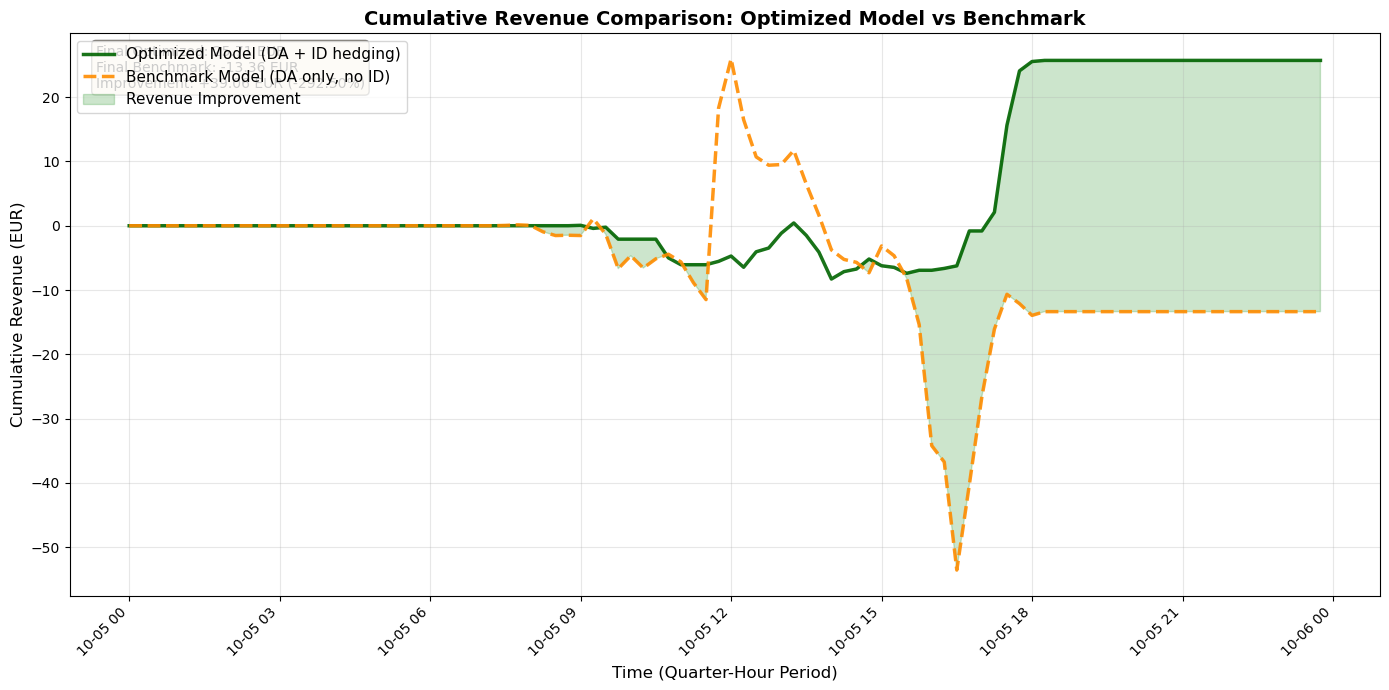

CUMULATIVE REVENUE VISUALIZATION: OPTIMIZED vs BENCHMARK saved.

CUMULATIVE REVENUE ANALYSIS

Final Cumulative Revenue (End of Day):
  Optimized Model:         25.71 EUR
  Benchmark Model:        -13.36 EUR
  ────────────────────────────────────
  Improvement:             39.06 EUR (+-292.50%)



In [205]:
# ===== CUMULATIVE REVENUE VISUALIZATION: OPTIMIZED vs BENCHMARK =====
import matplotlib.pyplot as plt
import numpy as np

# Calculate cumulative revenue for OPTIMIZED MODEL (from results_df)
optimized_cumulative_revenue = results_df['Total_Revenue_EUR'].cumsum()

# Calculate cumulative revenue for BENCHMARK MODEL (period by period)
# Need to create period-by-period revenue for benchmark
benchmark_DA_revenue_per_period = benchmark_DA * DA_p_actual / 4
benchmark_EEG_premium_per_period = EEG_p_actual * (benchmark_DA - benchmark_imb_neg + benchmark_imb_pos) / 4
benchmark_imb_settlement_per_period = benchmark_imb_pos * Imb_p_actual / 4 - benchmark_imb_neg * Imb_p_actual / 4
benchmark_total_revenue_per_period = benchmark_DA_revenue_per_period + benchmark_EEG_premium_per_period + benchmark_imb_settlement_per_period

# Calculate cumulative sum for benchmark
benchmark_cumulative_revenue = pd.Series(benchmark_total_revenue_per_period).cumsum()

# Create the plot
fig, ax = plt.subplots(figsize=(14, 7))

# Plot both cumulative revenue curves
ax.plot(results_df['PeriodStartLocal'], optimized_cumulative_revenue, 
        label='Optimized Model (DA + ID hedging)', color='darkgreen', linewidth=2.5, alpha=0.9)
ax.plot(results_df['PeriodStartLocal'], benchmark_cumulative_revenue, 
        label='Benchmark Model (DA only, no ID)', color='darkorange', linewidth=2.5, alpha=0.9, linestyle='--')

# Add shaded area showing the improvement
ax.fill_between(results_df['PeriodStartLocal'], 
                benchmark_cumulative_revenue, 
                optimized_cumulative_revenue,
                where=(optimized_cumulative_revenue >= benchmark_cumulative_revenue),
                interpolate=True,
                alpha=0.2, color='green', label='Revenue Improvement')

# Formatting
ax.set_xlabel('Time (Quarter-Hour Period)', fontsize=12)
ax.set_ylabel('Cumulative Revenue (EUR)', fontsize=12)
ax.set_title('Cumulative Revenue Comparison: Optimized Model vs Benchmark', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Add final revenue values as text annotations
final_optimized = optimized_cumulative_revenue.iloc[-1]
final_benchmark = benchmark_cumulative_revenue.iloc[-1]
improvement = final_optimized - final_benchmark

ax.text(0.02, 0.98, 
        f'Final Optimized: {final_optimized:.2f} EUR\n'
        f'Final Benchmark: {final_benchmark:.2f} EUR\n'
        f'Improvement: +{improvement:.2f} EUR ({improvement_percentage:.2f}%)',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('Cumulative revenue optimized vs benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print('CUMULATIVE REVENUE VISUALIZATION: OPTIMIZED vs BENCHMARK saved.')



print(f"\n{'='*70}")
print("CUMULATIVE REVENUE ANALYSIS")
print(f"{'='*70}")
print(f"\nFinal Cumulative Revenue (End of Day):")
print(f"  Optimized Model:  {final_optimized:>12.2f} EUR")
print(f"  Benchmark Model:  {final_benchmark:>12.2f} EUR")
print(f"  ────────────────────────────────────")
print(f"  Improvement:      {improvement:>12.2f} EUR (+{improvement_percentage:.2f}%)")
print(f"{'='*70}\n")

#### 6.0.1 Cumulative Revenue Comparison: Optimized vs Benchmark

### 6.1 Visualization: Generation and Market Allocations Across Stages

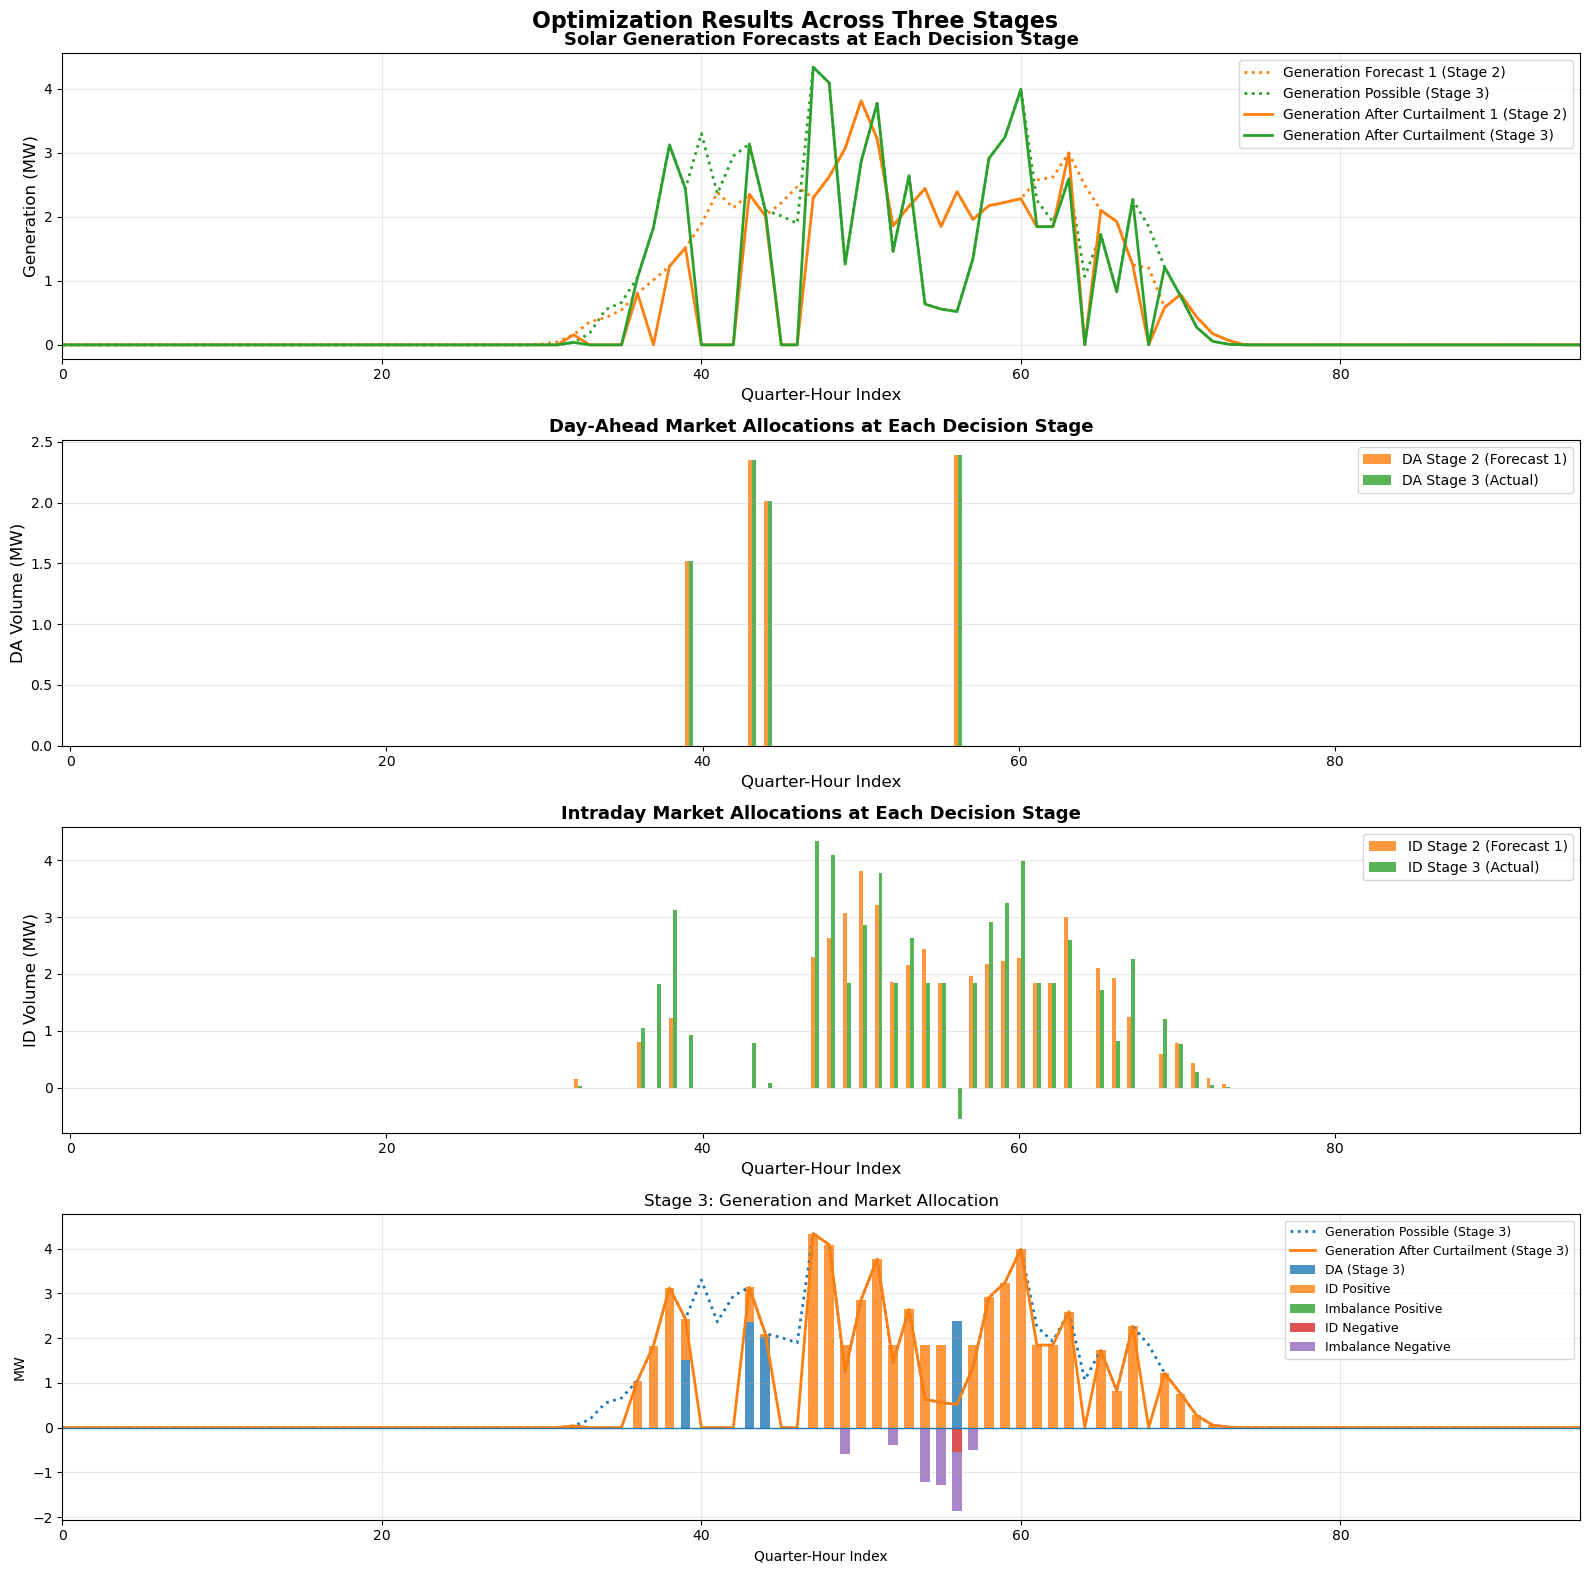

Optimization Results Across Three Stages saved.

=== Summary Statistics Across Stages ===

Generation (MW):
  Stage 2 (Forecast 1):  Min=0.00, Max=3.81, Mean=0.78
  Stage 3 (Actual):     Min=0.00, Max=4.33, Mean=0.81

DA Allocations (MW):
  Stage 2 Total: 8.28 MW (2.07 MWh)
  Stage 3 Total: 8.28 MW (2.07 MWh)

ID Allocations (MW):
  Stage 2 Total: 48.17 MW (12.04 MWh)
  Stage 3 Total: 57.77 MW (14.44 MWh)


In [209]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 3 subplots
fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Optimization Results Across Three Stages', fontsize=16, fontweight='bold')

# X-axis: quarter-hour indices (0-95)
quarter_hours = np.arange(len(DA_stage2_results))

# Plot 1: Generation at each stage (lines)
ax1 = axes[0]
ax1.plot(quarter_hours, Generation_f1, label='Generation Forecast 1 (Stage 2)', linewidth=2, color='#ff7f0e', linestyle=':')
ax1.plot(quarter_hours, Generation_actual, label='Generation Possible (Stage 3)', linewidth=2, color='#2ca02c', linestyle=':')
ax1.plot(quarter_hours, Generation_real_f1, label='Generation After Curtailment 1 (Stage 2)', linewidth=2, color='#ff7f0e', linestyle='-')
ax1.plot(quarter_hours, Generation_real, label='Generation After Curtailment (Stage 3)', linewidth=2, color='#2ca02c', linestyle='-')
ax1.set_xlabel('Quarter-Hour Index', fontsize=12)
ax1.set_ylabel('Generation (MW)', fontsize=12)
ax1.set_title('Solar Generation Forecasts at Each Decision Stage', fontsize=13, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 95)

# Plot 2: DA volumes at each stage (bars)
ax2 = axes[1]
x = np.arange(len(DA_stage2_results))
width = 0.25  # Width of bars
ax2.bar(x, DA_stage2_results, width, label='DA Stage 2 (Forecast 1)', alpha=0.8, color='#ff7f0e')
ax2.bar(x + width, DA_stage3_results, width, label='DA Stage 3 (Actual)', alpha=0.8, color='#2ca02c')
ax2.set_xlabel('Quarter-Hour Index', fontsize=12)
ax2.set_ylabel('DA Volume (MW)', fontsize=12)
ax2.set_title('Day-Ahead Market Allocations at Each Decision Stage', fontsize=13, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlim(-0.5, 95.5)

# Plot 3: ID volumes at each stage (bars)
ax3 = axes[2]
ax3.bar(x, ID_stage2_results, width, label='ID Stage 2 (Forecast 1)', alpha=0.8, color='#ff7f0e')
ax3.bar(x + width, ID_stage3_results, width, label='ID Stage 3 (Actual)', alpha=0.8, color='#2ca02c')
ax3.set_xlabel('Quarter-Hour Index', fontsize=12)
ax3.set_ylabel('ID Volume (MW)', fontsize=12)
ax3.set_title('Intraday Market Allocations at Each Decision Stage', fontsize=13, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_xlim(-0.5, 95.5)

# Plot 4: Stage 3 – Generation + Market Stack (Single Axis)
ax4 = axes[3]
x = np.arange(len(DA_stage3_results))
width = 0.6

# Convert arrays
DA = np.array(DA_stage3_results)
ID = np.array(ID_stage3_results)
IMB_POS = np.array(Imb_pos_results)
IMB_NEG = np.array(Imb_neg_results)

# Split ID into positive and negative
ID_pos = np.where(ID > 0, ID, 0)
ID_neg = np.where(ID < 0, ID, 0)

# ----- Positive stack -----
market_positive = {
    "DA (Stage 3)": DA,
    "ID Positive": ID_pos,
    "Imbalance Positive": IMB_POS,
}

bottom_pos = np.zeros(len(x))
for label, values in market_positive.items():
    ax4.bar(x, values, width, bottom=bottom_pos, label=label, alpha=0.8)
    bottom_pos += values

# ----- Negative stack -----
market_negative = {
    "ID Negative": ID_neg,
    "Imbalance Negative": -IMB_NEG,  # plot downward
}

bottom_neg = np.zeros(len(x))
for label, values in market_negative.items():
    ax4.bar(x, values, width, bottom=bottom_neg, label=label, alpha=0.8)
    bottom_neg += values

# ----- Generation lines -----
ax4.plot(quarter_hours, Generation_actual, lw=2, ls=':', label='Generation Possible (Stage 3)')
ax4.plot(quarter_hours, Generation_real, lw=2, ls='-', label='Generation After Curtailment (Stage 3)')

# ----- Axis formatting -----
ax4.set(xlabel='Quarter-Hour Index', ylabel='MW', xlim=(0,95),
        title='Stage 3: Generation and Market Allocation')
ax4.axhline(0, linewidth=1)
ax4.grid(True, alpha=0.3)

# Set y-limits to include negative bars
all_values = np.concatenate([bottom_pos, bottom_neg, Generation_actual, Generation_real])
ax4.set_ylim(all_values.min()*1.1, all_values.max()*1.1)

# ----- Legend -----
h1, l1 = ax4.get_legend_handles_labels()
ax4.legend(h1, l1, loc='best', fontsize=9)




plt.tight_layout()
plt.savefig('Optimization Results Across Three Stages.png', dpi=150, bbox_inches='tight')
plt.show()
print('Optimization Results Across Three Stages saved.')


# Print summary statistics
print("\n=== Summary Statistics Across Stages ===")
print(f"\nGeneration (MW):")
print(f"  Stage 2 (Forecast 1):  Min={Generation_f1.min():.2f}, Max={Generation_f1.max():.2f}, Mean={Generation_f1.mean():.2f}")
print(f"  Stage 3 (Actual):     Min={Generation_actual.min():.2f}, Max={Generation_actual.max():.2f}, Mean={Generation_actual.mean():.2f}")

print(f"\nDA Allocations (MW):")
#print(f"  Stage 1 Total: {sum(DA_stage1_results):.2f} MW ({sum(DA_stage1_results)/4:.2f} MWh)")
print(f"  Stage 2 Total: {sum(DA_stage2_results):.2f} MW ({sum(DA_stage2_results)/4:.2f} MWh)")
print(f"  Stage 3 Total: {sum(DA_stage3_results):.2f} MW ({sum(DA_stage3_results)/4:.2f} MWh)")

print(f"\nID Allocations (MW):")
#print(f"  Stage 1 Total: {sum(ID_stage1_results):.2f} MW ({sum(ID_stage1_results)/4:.2f} MWh)")
print(f"  Stage 2 Total: {sum(ID_stage2_results):.2f} MW ({sum(ID_stage2_results)/4:.2f} MWh)")
print(f"  Stage 3 Total: {sum(ID_stage3_results):.2f} MW ({sum(ID_stage3_results)/4:.2f} MWh)")


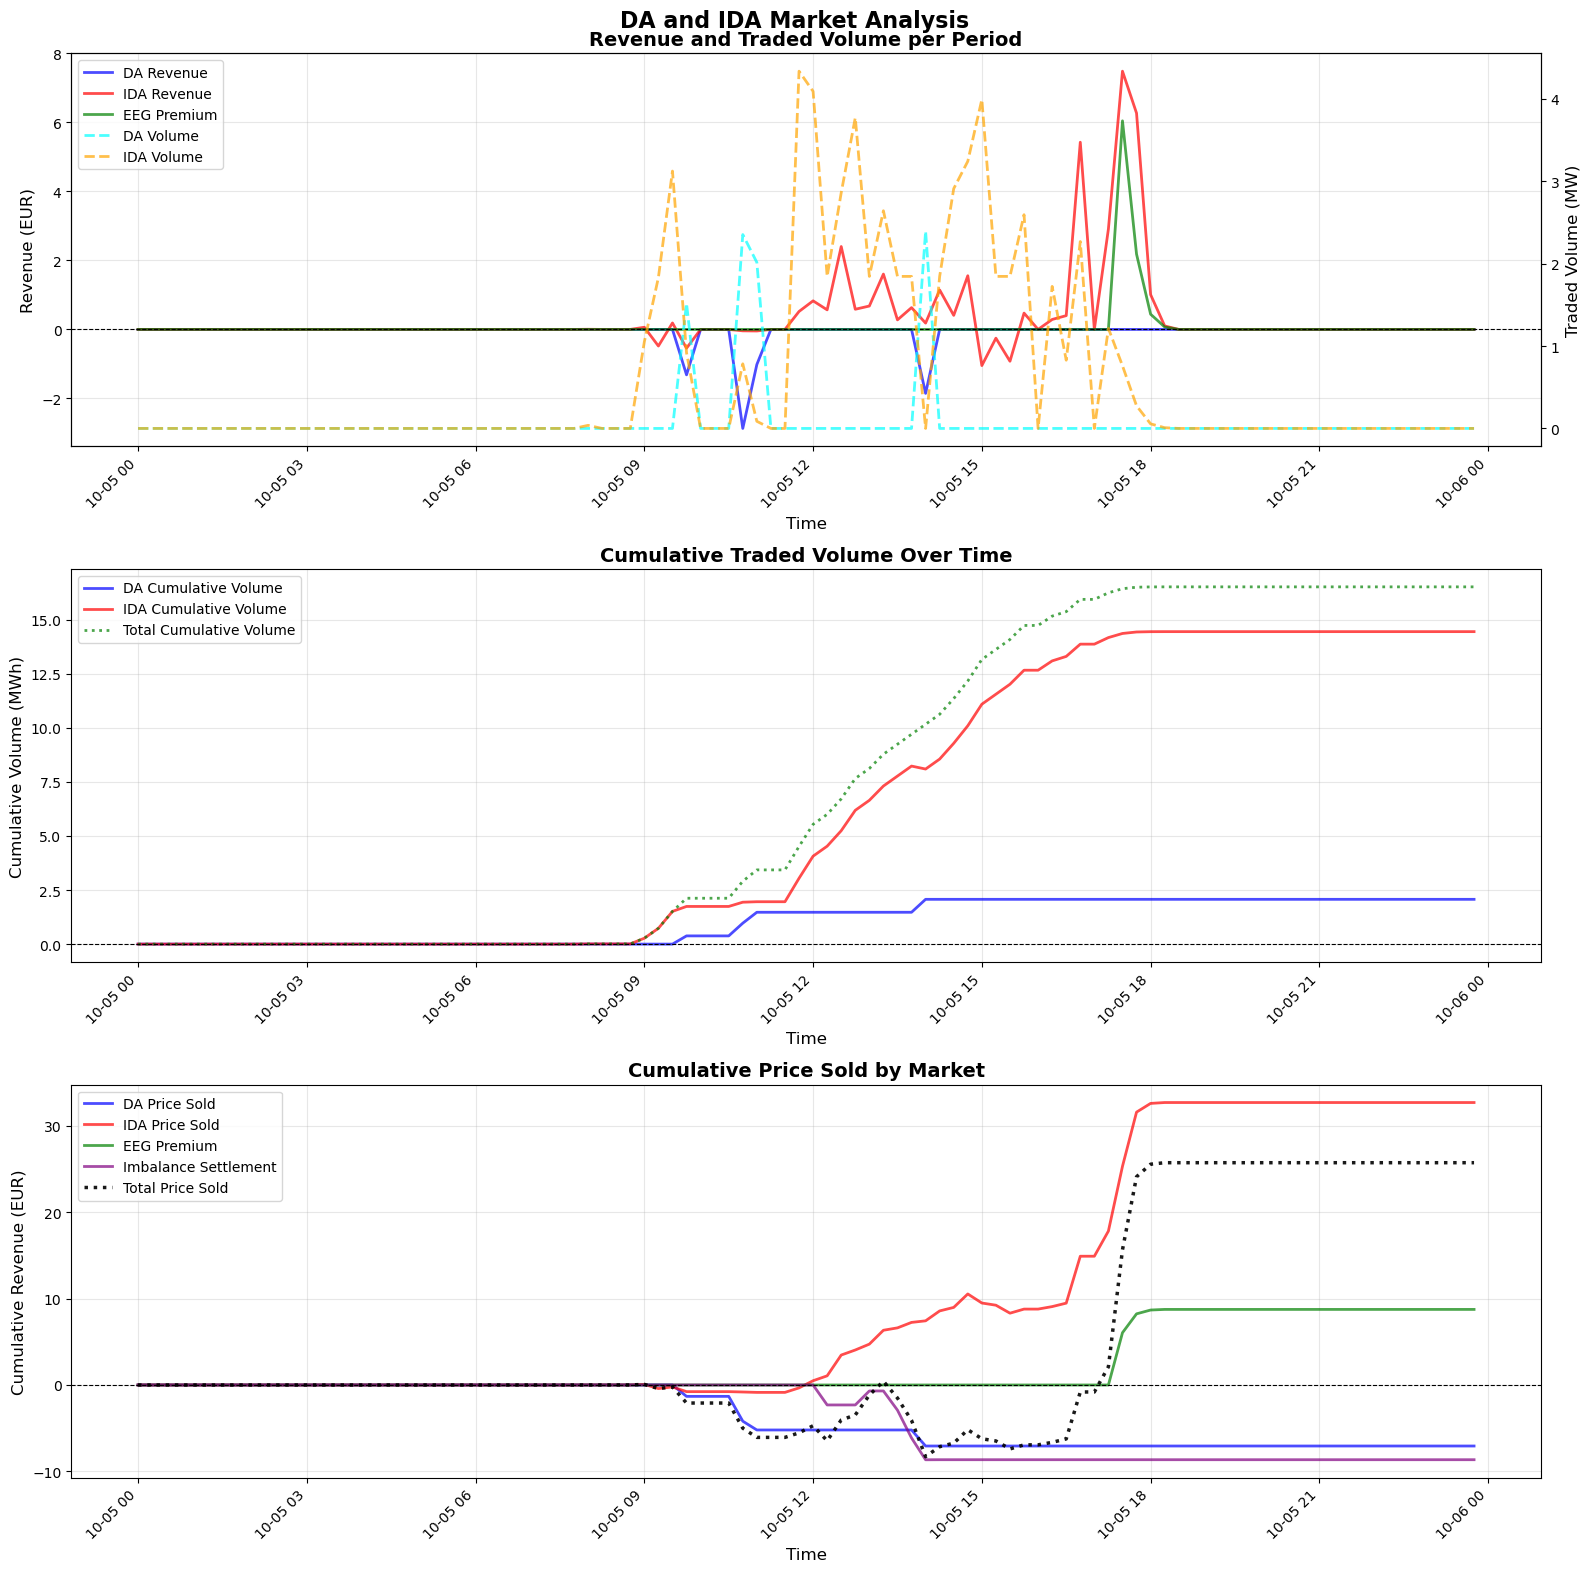

DA and Intraday market analysis saved.

=== Revenue and Volume Statistics ===

Day-Ahead Market:
  Total Revenue:        -7.06 EUR
  Total Volume:         2.07 MWh

Intraday Market:
  Total Revenue:        32.67 EUR
  Total Volume:         14.44 MWh
  Avg Price Sold:       2.26 EUR/MWh

EEG Market Premium:
  Total Premium:        8.74 EUR
  Avg Premium/Period:   0.09 EUR

Imbalance Settlement:
  Total Settlement:     -8.64 EUR
  Avg Settlement/Period: -0.09 EUR

Overall Total Revenue: 25.71 EUR


In [210]:
 # Create figure with 3 subplots
fig, axes = plt.subplots(3, 1, figsize=(16, 16))
fig.suptitle('DA and IDA Market Analysis', fontsize=16, fontweight='bold')

# ── Subplot 1: Revenue and Traded Volume per Timestamp ───────────────
ax1 = axes[0]
ax2 = ax1.twinx()

line1 = ax1.plot(results_df['PeriodStartLocal'], results_df['DA_Revenue_EUR'],
                 label='DA Revenue', color='blue', linewidth=2, alpha=0.7)
line2 = ax1.plot(results_df['PeriodStartLocal'], results_df['ID_Revenue_EUR'],
                 label='IDA Revenue', color='red', linewidth=2, alpha=0.7)
line5 = ax1.plot(results_df['PeriodStartLocal'], results_df['Market premium_EUR'],
                 label='EEG Premium', color='green', linewidth=2, alpha=0.7)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')

line3 = ax2.plot(results_df['PeriodStartLocal'], results_df['DA_MW'].clip(lower=0),
                 label='DA Volume', color='cyan', linewidth=2, linestyle='--', alpha=0.7)
line4 = ax2.plot(results_df['PeriodStartLocal'], results_df['ID_MW'].clip(lower=0),
                 label='IDA Volume', color='orange', linewidth=2, linestyle='--', alpha=0.7)

ax1.set_xlabel('Time', fontsize=12)
ax1.set_ylabel('Revenue (EUR)', fontsize=12)
ax2.set_ylabel('Traded Volume (MW)', fontsize=12)
ax1.set_title('Revenue and Traded Volume per Period', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines = line1 + line2 + line5 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

# ── Subplot 2: Cumulative Traded Volume ──────────────────────────────
ax3 = axes[1]

cumulative_da_volume  = (results_df['DA_MW'] / 4).cumsum()
cumulative_ida_volume = (results_df['ID_MW'] / 4).cumsum()
cumulative_tot_volume = cumulative_da_volume + cumulative_ida_volume

ax3.plot(results_df['PeriodStartLocal'], cumulative_da_volume,
         label='DA Cumulative Volume', color='blue', linewidth=2, alpha=0.7)
ax3.plot(results_df['PeriodStartLocal'], cumulative_ida_volume,
         label='IDA Cumulative Volume', color='red', linewidth=2, alpha=0.7)
ax3.plot(results_df['PeriodStartLocal'], cumulative_tot_volume,
         label='Total Cumulative Volume', color='green', linewidth=2,
         linestyle=':', alpha=0.7)
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax3.set_xlabel('Time', fontsize=12)
ax3.set_ylabel('Cumulative Volume (MWh)', fontsize=12)
ax3.set_title('Cumulative Traded Volume Over Time', fontsize=14, fontweight='bold')
ax3.legend(loc='upper left', fontsize=10)
ax3.grid(True, alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')

# ── Subplot 3: Cumulative Revenue by Market Stream ───────────────────
ax4 = axes[2]

cumulative_da_revenue  = results_df['DA_Revenue_EUR'].cumsum()
cumulative_ida_revenue = results_df['ID_Revenue_EUR'].cumsum()
cumulative_eeg         = results_df['Market premium_EUR'].cumsum()
cumulative_imb         = results_df['Imb_Settlement_EUR'].cumsum()
cumulative_total       = (cumulative_da_revenue + cumulative_ida_revenue +
                          cumulative_eeg + cumulative_imb)

ax4.plot(results_df['PeriodStartLocal'], cumulative_da_revenue,
         label='DA Price Sold', color='blue', linewidth=2, alpha=0.7)
ax4.plot(results_df['PeriodStartLocal'], cumulative_ida_revenue,
         label='IDA Price Sold', color='red', linewidth=2, alpha=0.7)
ax4.plot(results_df['PeriodStartLocal'], cumulative_eeg,
         label='EEG Premium', color='green', linewidth=2, alpha=0.7)
ax4.plot(results_df['PeriodStartLocal'], cumulative_imb,
         label='Imbalance Settlement', color='purple', linewidth=2, alpha=0.7)
ax4.plot(results_df['PeriodStartLocal'], cumulative_total,
         label='Total Price Sold', color='black', linewidth=2.5,
         linestyle=':', alpha=0.9)
ax4.axhline(0, color='black', linewidth=0.8, linestyle='--')

ax4.set_xlabel('Time', fontsize=12)
ax4.set_ylabel('Cumulative Revenue (EUR)', fontsize=12)
ax4.set_title('Cumulative Price Sold by Market', fontsize=14, fontweight='bold')
ax4.legend(loc='upper left', fontsize=10)
ax4.grid(True, alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('DA_and_Intraday_market_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('DA and Intraday market analysis saved.')

# ── Print summary statistics ─────────────────────────────────────────
print("\n=== Revenue and Volume Statistics ===")
print(f"\nDay-Ahead Market:")
print(f"  Total Revenue:        {results_df['DA_Revenue_EUR'].sum():.2f} EUR")
print(f"  Total Volume:         {(results_df['DA_MW']/4).sum():.2f} MWh")

print(f"\nIntraday Market:")
print(f"  Total Revenue:        {results_df['ID_Revenue_EUR'].sum():.2f} EUR")
print(f"  Total Volume:         {(results_df['ID_MW']/4).sum():.2f} MWh")
if (results_df['ID_MW']/4).sum() != 0:
    print(f"  Avg Price Sold:       {(results_df['ID_Revenue_EUR'].sum() / (results_df['ID_MW']/4).sum()):.2f} EUR/MWh")

print(f"\nEEG Market Premium:")
print(f"  Total Premium:        {results_df['Market premium_EUR'].sum():.2f} EUR")
print(f"  Avg Premium/Period:   {results_df['Market premium_EUR'].mean():.2f} EUR")

print(f"\nImbalance Settlement:")
print(f"  Total Settlement:     {results_df['Imb_Settlement_EUR'].sum():.2f} EUR")
print(f"  Avg Settlement/Period: {results_df['Imb_Settlement_EUR'].mean():.2f} EUR")

print(f"\nOverall Total Revenue: {results_df['Total_Revenue_EUR'].sum():.2f} EUR")

In [211]:
# Create a dataframe with revenue from IDA and DA per timestamp
revenue_per_timestep = pd.DataFrame({
    'Timestamp': results_df['PeriodStartLocal'],
    'DA_Revenue_EUR': results_df['DA_Revenue_EUR'],
    'DA_Volume_MW': results_df['DA_MW'],
    'IDA_Revenue_EUR': results_df['ID_Revenue_EUR'],
    'IDA_Volume_MW': results_df['ID_MW'],
    'Total_Revenue_EUR': results_df['DA_Revenue_EUR'] + results_df['ID_Revenue_EUR']
})

print("=== Revenue per Timestamp DataFrame ===")
print(f"\nDataFrame shape: {revenue_per_timestep.shape}")
print(f"\nFirst 10 rows:")
print(revenue_per_timestep.head(10))

# Show the 5 most profitable hours for DA
print("\n=== 5 Most Profitable Hours for Day-Ahead Market ===")
top_da = revenue_per_timestep.nlargest(5, 'DA_Revenue_EUR')[['Timestamp', 'DA_Revenue_EUR', 'DA_Volume_MW']]
print(top_da.to_string(index=False))

# Show the 5 most profitable hours for IDA
print("\n=== 5 Most Profitable Hours for Intraday Market ===")
top_ida = revenue_per_timestep.nlargest(5, 'IDA_Revenue_EUR')[['Timestamp', 'IDA_Revenue_EUR', 'IDA_Volume_MW']]
print(top_ida.to_string(index=False))

=== Revenue per Timestamp DataFrame ===

DataFrame shape: (96, 6)

First 10 rows:
                  Timestamp  DA_Revenue_EUR  DA_Volume_MW  IDA_Revenue_EUR  \
0 2025-10-05 00:00:00+02:00            -0.0           0.0              0.0   
1 2025-10-05 00:15:00+02:00            -0.0           0.0             -0.0   
2 2025-10-05 00:30:00+02:00            -0.0           0.0             -0.0   
3 2025-10-05 00:45:00+02:00            -0.0           0.0             -0.0   
4 2025-10-05 01:00:00+02:00            -0.0           0.0              0.0   
5 2025-10-05 01:15:00+02:00            -0.0           0.0             -0.0   
6 2025-10-05 01:30:00+02:00            -0.0           0.0             -0.0   
7 2025-10-05 01:45:00+02:00            -0.0           0.0             -0.0   
8 2025-10-05 02:00:00+02:00            -0.0           0.0              0.0   
9 2025-10-05 02:15:00+02:00            -0.0           0.0              0.0   

   IDA_Volume_MW  Total_Revenue_EUR  
0            0.0     

### 6.2 Imbalance Analysis and Cost

In [214]:
# ===== IMBALANCE ANALYSIS =====
print("="*60)
print("           IMBALANCE ANALYSIS - STAGE 3 RESULTS")
print("="*60)

# Imbalance data from results_df
imbalance_data = results_df[['PeriodStartLocal', 'Imb_pos_MW', 'Imb_neg_MW', 'Imb_price', 'Imb_Settlement_EUR']].copy()

# Calculate total imbalances
total_imb_pos_MW = results_df['Imb_pos_MW'].sum()
total_imb_neg_MW = results_df['Imb_neg_MW'].sum()

# Calculate total imbalance in MWh (dividing by 4 for 15-min periods)
total_imb_pos_MWh = total_imb_pos_MW / 4
total_imb_neg_MWh = total_imb_neg_MW / 4

# Calculate total imbalance settlement (cost/revenue)
# Positive imbalance = surplus (received money)
# Negative imbalance = shortage (paid money)
total_imb_settlement = results_df['Imb_Settlement_EUR'].sum()

# Count periods with imbalances
periods_with_pos_imb = (results_df['Imb_pos_MW'] > 0.001).sum()
periods_with_neg_imb = (results_df['Imb_neg_MW'] > 0.001).sum()
periods_with_any_imb = periods_with_pos_imb + periods_with_neg_imb

print(f"\n{'─'*60}")
print(f"SUMMARY STATISTICS")
print(f"{'─'*60}")
print(f"\nTotal Periods Analyzed:           {len(results_df)}")
print(f"Periods with Positive Imbalance:  {periods_with_pos_imb} ({periods_with_pos_imb/len(results_df)*100:.1f}%)")
print(f"Periods with Negative Imbalance:  {periods_with_neg_imb} ({periods_with_neg_imb/len(results_df)*100:.1f}%)")
print(f"Periods with No Imbalance:        {len(results_df) - periods_with_any_imb} ({(len(results_df) - periods_with_any_imb)/len(results_df)*100:.1f}%)")

print(f"\n{'─'*60}")
print(f"IMBALANCE VOLUMES")
print(f"{'─'*60}")
print(f"\nPositive Imbalance (Surplus):")
print(f"  Total:  {total_imb_pos_MW:.2f} MW  ({total_imb_pos_MWh:.2f} MWh)")
print(f"  Max:    {results_df['Imb_pos_MW'].max():.2f} MW")
print(f"  Avg:    {results_df['Imb_pos_MW'].mean():.2f} MW")

print(f"\nNegative Imbalance (Shortage):")
print(f"  Total:  {total_imb_neg_MW:.2f} MW  ({total_imb_neg_MWh:.2f} MWh)")
print(f"  Max:    {results_df['Imb_neg_MW'].max():.2f} MW")
print(f"  Avg:    {results_df['Imb_neg_MW'].mean():.2f} MW")

print(f"\n{'─'*60}")
print(f"IMBALANCE SETTLEMENT (FINANCIAL IMPACT)")
print(f"{'─'*60}")
print(f"\nTotal Imbalance Settlement:       {total_imb_settlement:.2f} EUR")
print(f"  (Positive = Revenue, Negative = Cost)")

if total_imb_settlement >= 0:
    print(f"\n✓ Net Revenue from Imbalance: {total_imb_settlement:.2f} EUR")
else:
    print(f"\n✗ Net Cost from Imbalance: {abs(total_imb_settlement):.2f} EUR")

print(f"\nAverage Settlement per Period:    {results_df['Imb_Settlement_EUR'].mean():.2f} EUR")
print(f"Average Imbalance Price:          {results_df['Imb_price'].mean():.2f} EUR/MWh")

print(f"\n{'─'*60}")
print(f"PERIODS WITH HIGHEST IMBALANCES")
print(f"{'─'*60}")

# Show top 5 periods with highest positive imbalance
print("\nTop 5 Positive Imbalances (Surplus):")
top_pos_imb = imbalance_data.nlargest(5, 'Imb_pos_MW')[['PeriodStartLocal', 'Imb_pos_MW', 'Imb_price', 'Imb_Settlement_EUR']]
for idx, row in top_pos_imb.iterrows():
    if row['Imb_pos_MW'] > 0.001:
        print(f"  {row['PeriodStartLocal']}: {row['Imb_pos_MW']:6.2f} MW at {row['Imb_price']:7.2f} EUR/MWh = {row['Imb_Settlement_EUR']:8.2f} EUR")

# Show top 5 periods with highest negative imbalance
print("\nTop 5 Negative Imbalances (Shortage):")
top_neg_imb = imbalance_data.nlargest(5, 'Imb_neg_MW')[['PeriodStartLocal', 'Imb_neg_MW', 'Imb_price', 'Imb_Settlement_EUR']]
for idx, row in top_neg_imb.iterrows():
    if row['Imb_neg_MW'] > 0.001:
        print(f"  {row['PeriodStartLocal']}: {row['Imb_neg_MW']:6.2f} MW at {row['Imb_price']:7.2f} EUR/MWh = {row['Imb_Settlement_EUR']:8.2f} EUR")

print(f"\n{'='*60}")

           IMBALANCE ANALYSIS - STAGE 3 RESULTS

────────────────────────────────────────────────────────────
SUMMARY STATISTICS
────────────────────────────────────────────────────────────

Total Periods Analyzed:           96
Periods with Positive Imbalance:  0 (0.0%)
Periods with Negative Imbalance:  6 (6.2%)
Periods with No Imbalance:        90 (93.8%)

────────────────────────────────────────────────────────────
IMBALANCE VOLUMES
────────────────────────────────────────────────────────────

Positive Imbalance (Surplus):
  Total:  0.00 MW  (0.00 MWh)
  Max:    0.00 MW
  Avg:    0.00 MW

Negative Imbalance (Shortage):
  Total:  5.29 MW  (1.32 MWh)
  Max:    1.33 MW
  Avg:    0.06 MW

────────────────────────────────────────────────────────────
IMBALANCE SETTLEMENT (FINANCIAL IMPACT)
────────────────────────────────────────────────────────────

Total Imbalance Settlement:       -8.64 EUR
  (Positive = Revenue, Negative = Cost)

✗ Net Cost from Imbalance: 8.64 EUR

Average Settlement 

In [217]:
# Demonstrate the imbalance avoidance mechanism
print("="*70)
print("         IMBALANCE AVOIDANCE MECHANISM ANALYSIS")
print("="*70)

# Calculate the mismatch that ID market is hedging
results_df['DA_Generation_Mismatch'] = results_df['DA_MW'] - results_df['Generation_Delivered_MW']

# Show statistics
print("\n" + "─"*70)
print("MISMATCH BETWEEN DA COMMITMENTS AND ACTUAL GENERATION")
print("─"*70)
print(f"\nWithout ID market, there would be mismatches!")
print(f"Average DA vs Actual mismatch: {results_df['DA_Generation_Mismatch'].mean():.2f} MW")
print(f"Max positive mismatch: {results_df['DA_Generation_Mismatch'].max():.2f} MW (over-commitment)")
print(f"Max negative mismatch: {results_df['DA_Generation_Mismatch'].min():.2f} MW (under-commitment)")

print("\n" + "─"*70)
print("ID MARKET IS USED TO HEDGE THESE MISMATCHES")
print("─"*70)

# Calculate ID market hedging
id_buys = results_df[results_df['ID_MW'] < -0.001].copy()
id_sells = results_df[results_df['ID_MW'] > 0.001].copy()

print(f"\nPeriods where ID market BUYS power: {len(id_buys)}")
if len(id_buys) > 0:
    print(f"  Total bought: {(-id_buys['ID_MW'].sum()/4):.2f} MWh")
    print(f"  Cost: {id_buys['ID_Revenue_EUR'].sum():.2f} EUR")
    print(f"  Avg price paid: {(id_buys['ID_Revenue_EUR'].sum() / (-id_buys['ID_MW'].sum()/4)):.2f} EUR/MWh")

print(f"\nPeriods where ID market SELLS power: {len(id_sells)}")
if len(id_sells) > 0:
    print(f"  Total sold: {(id_sells['ID_MW'].sum()/4):.2f} MWh")
    print(f"  Revenue: {id_sells['ID_Revenue_EUR'].sum():.2f} EUR")
    print(f"  Avg price received: {(id_sells['ID_Revenue_EUR'].sum() / (id_sells['ID_MW'].sum()/4)):.2f} EUR/MWh")

print("\n" + "─"*70)
print("COST COMPARISON: ID HEDGING vs IMBALANCE PENALTIES")
print("─"*70)

# What would the cost be if we had imbalances instead of hedging?
theoretical_imbalance_volume = abs(results_df['DA_Generation_Mismatch']).sum() / 4  # MWh
actual_id_cost = results_df['ID_Revenue_EUR'].sum()  # Negative = cost, positive = revenue

# Calculate what it would cost with imbalance penalties
imbalance_penalty = 100000.0  # EUR/MWh
theoretical_imbalance_cost = theoretical_imbalance_volume * imbalance_penalty

print(f"\nActual ID market net revenue: {actual_id_cost:.2f} EUR")
print(f"\nIf these were imbalances instead:")
print(f"  Volume to balance: {theoretical_imbalance_volume:.2f} MWh")
print(f"  Cost at 100,000 EUR/MWh: {theoretical_imbalance_cost:.2f} EUR")
print(f"\n💡 Savings by using ID market: {theoretical_imbalance_cost + actual_id_cost:.2f} EUR")
print(f"   (This is why the optimizer chooses ID market over imbalances!)")

print("\n" + "─"*70)
print("BALANCE VERIFICATION")
print("─"*70)

# Verify the balance equation for a few sample periods
print("\nBalance equation: DA + ID + (Imb_pos - Imb_neg) = Generation_Delivered")
print("\nSample periods:")
for i in [0, 20, 40, 60, 80]:
    row = results_df.iloc[i]
    lhs = row['DA_MW'] + row['ID_MW'] + (row['Imb_pos_MW'] - row['Imb_neg_MW'])
    rhs = row['Generation_Delivered_MW']
    match = "✓" if abs(lhs - rhs) < 0.01 else "✗"
    print(f"  Period {i}: {row['DA_MW']:.2f} + {row['ID_MW']:.2f} + 0.00 = {row['Generation_Delivered_MW']:.2f} {match}")

print("\n" + "="*70)

         IMBALANCE AVOIDANCE MECHANISM ANALYSIS

──────────────────────────────────────────────────────────────────────
MISMATCH BETWEEN DA COMMITMENTS AND ACTUAL GENERATION
──────────────────────────────────────────────────────────────────────

Without ID market, there would be mismatches!
Average DA vs Actual mismatch: -0.55 MW
Max positive mismatch: 1.87 MW (over-commitment)
Max negative mismatch: -4.33 MW (under-commitment)

──────────────────────────────────────────────────────────────────────
ID MARKET IS USED TO HEDGE THESE MISMATCHES
──────────────────────────────────────────────────────────────────────

Periods where ID market BUYS power: 1
  Total bought: 0.14 MWh
  Cost: 0.18 EUR
  Avg price paid: 1.34 EUR/MWh

Periods where ID market SELLS power: 31
  Total sold: 14.58 MWh
  Revenue: 32.49 EUR
  Avg price received: 2.23 EUR/MWh

──────────────────────────────────────────────────────────────────────
COST COMPARISON: ID HEDGING vs IMBALANCE PENALTIES
─────────────────────────

In [220]:
# ===== GENERATION FORECAST ERROR ANALYSIS =====
print("="*75)
print("        GENERATION FORECAST vs ACTUAL - ERROR ANALYSIS")
print("="*75)

# Calculate forecast errors
forecast_error_MW = Generation_f1 - Generation_actual
forecast_error_pct = ((Generation_f1 - Generation_actual) / (Generation_f1 + 0.001)) * 100

print("\n" + "─"*75)
print("SUMMARY STATISTICS")
print("─"*75)

print(f"\nGeneration Forecast 1 (Stage 2):")
print(f"  Minimum:  {Generation_f1.min():.2f} MW")
print(f"  Maximum:  {Generation_f1.max():.2f} MW")
print(f"  Average:  {Generation_f1.mean():.2f} MW")
print(f"  Total:    {(Generation_f1.sum()/4):.2f} MWh")

print(f"\nGeneration Actual (Stage 3):")
print(f"  Minimum:  {Generation_actual.min():.2f} MW")
print(f"  Maximum:  {Generation_actual.max():.2f} MW")
print(f"  Average:  {Generation_actual.mean():.2f} MW")
print(f"  Total:    {(Generation_actual.sum()/4):.2f} MWh")

print(f"\nForecast Error (Forecast - Actual):")
print(f"  Average:        {forecast_error_MW.mean():.2f} MW")
print(f"  Std Deviation:  {forecast_error_MW.std():.2f} MW")
print(f"  Max Over-forecast:  {forecast_error_MW.max():.2f} MW")
print(f"  Max Under-forecast: {forecast_error_MW.min():.2f} MW")

# Calculate metrics
mae = np.abs(forecast_error_MW).mean()
mape = np.abs(forecast_error_pct).mean()
rmse = np.sqrt(np.mean(forecast_error_MW**2))

print(f"\n" + "─"*75)
print("FORECAST ERROR METRICS")
print("─"*75)
print(f"\nMean Absolute Error (MAE):       {mae:.2f} MW")
print(f"Root Mean Square Error (RMSE):   {rmse:.2f} MW")
print(f"Mean Absolute Percentage Error:  {mape:.1f}%")

# Over-forecasting analysis
over_forecast = forecast_error_MW > 0.1
under_forecast = forecast_error_MW < -0.1
accurate = (forecast_error_MW >= -0.1) & (forecast_error_MW <= 0.1)

print(f"\n" + "─"*75)
print("FORECAST BIAS ANALYSIS")
print("─"*75)
print(f"\nPeriods with OVER-forecast:   {over_forecast.sum()} ({over_forecast.sum()/len(forecast_error_MW)*100:.1f}%)")
print(f"  Total excess predicted:     {forecast_error_MW[over_forecast].sum():.2f} MW")
print(f"Periods with UNDER-forecast:  {under_forecast.sum()} ({under_forecast.sum()/len(forecast_error_MW)*100:.1f}%)")
print(f"  Total deficit predicted:    {abs(forecast_error_MW[under_forecast].sum()):.2f} MW")
print(f"Periods with accurate forecast: {accurate.sum()} ({accurate.sum()/len(forecast_error_MW)*100:.1f}%)")

print(f"\n💡 Forecast BIAS: {forecast_error_MW.mean():.2f} MW")
if forecast_error_MW.mean() > 1:
    print("   → Strong POSITIVE BIAS: Forecast consistently OVER-estimates actual generation")
elif forecast_error_MW.mean() < -1:
    print("   → Strong NEGATIVE BIAS: Forecast consistently UNDER-estimates actual generation")
else:
    print("   → Relatively unbiased forecast")



# Calculate financial impact of forecast error
revenue_if_forecast_correct = (Generation_f1.sum()/4) * DA_p_actual.mean()
actual_revenue = (Generation_actual.sum()/4) * DA_p_actual.mean()
lost_opportunity = revenue_if_forecast_correct - actual_revenue

print(f"\nIf forecast was accurate:")
print(f"  Could generate: {Generation_f1.sum()/4:.2f} MWh")
print(f"  Estimated revenue: {revenue_if_forecast_correct:.2f} EUR")
print(f"\nActual generation:")
print(f"  Generated: {Generation_actual.sum()/4:.2f} MWh")
print(f"  Estimated revenue: {actual_revenue:.2f} EUR")
print(f"\nLost opportunity due to lower-than-forecast generation:")
print(f"  {(Generation_f1.sum() - Generation_actual.sum())/4:.2f} MWh")
print(f"  ~{lost_opportunity:.2f} EUR (at avg DA price)")

print("\n" + "="*75)

        GENERATION FORECAST vs ACTUAL - ERROR ANALYSIS

───────────────────────────────────────────────────────────────────────────
SUMMARY STATISTICS
───────────────────────────────────────────────────────────────────────────

Generation Forecast 1 (Stage 2):
  Minimum:  0.00 MW
  Maximum:  3.81 MW
  Average:  0.78 MW
  Total:    18.78 MWh

Generation Actual (Stage 3):
  Minimum:  0.00 MW
  Maximum:  4.33 MW
  Average:  0.81 MW
  Total:    19.52 MWh

Forecast Error (Forecast - Actual):
  Average:        -0.03 MW
  Std Deviation:  0.64 MW
  Max Over-forecast:  1.87 MW
  Max Under-forecast: -2.04 MW

───────────────────────────────────────────────────────────────────────────
FORECAST ERROR METRICS
───────────────────────────────────────────────────────────────────────────

Mean Absolute Error (MAE):       0.33 MW
Root Mean Square Error (RMSE):   0.64 MW
Mean Absolute Percentage Error:  22.9%

───────────────────────────────────────────────────────────────────────────
FORECAST BIAS ANALY

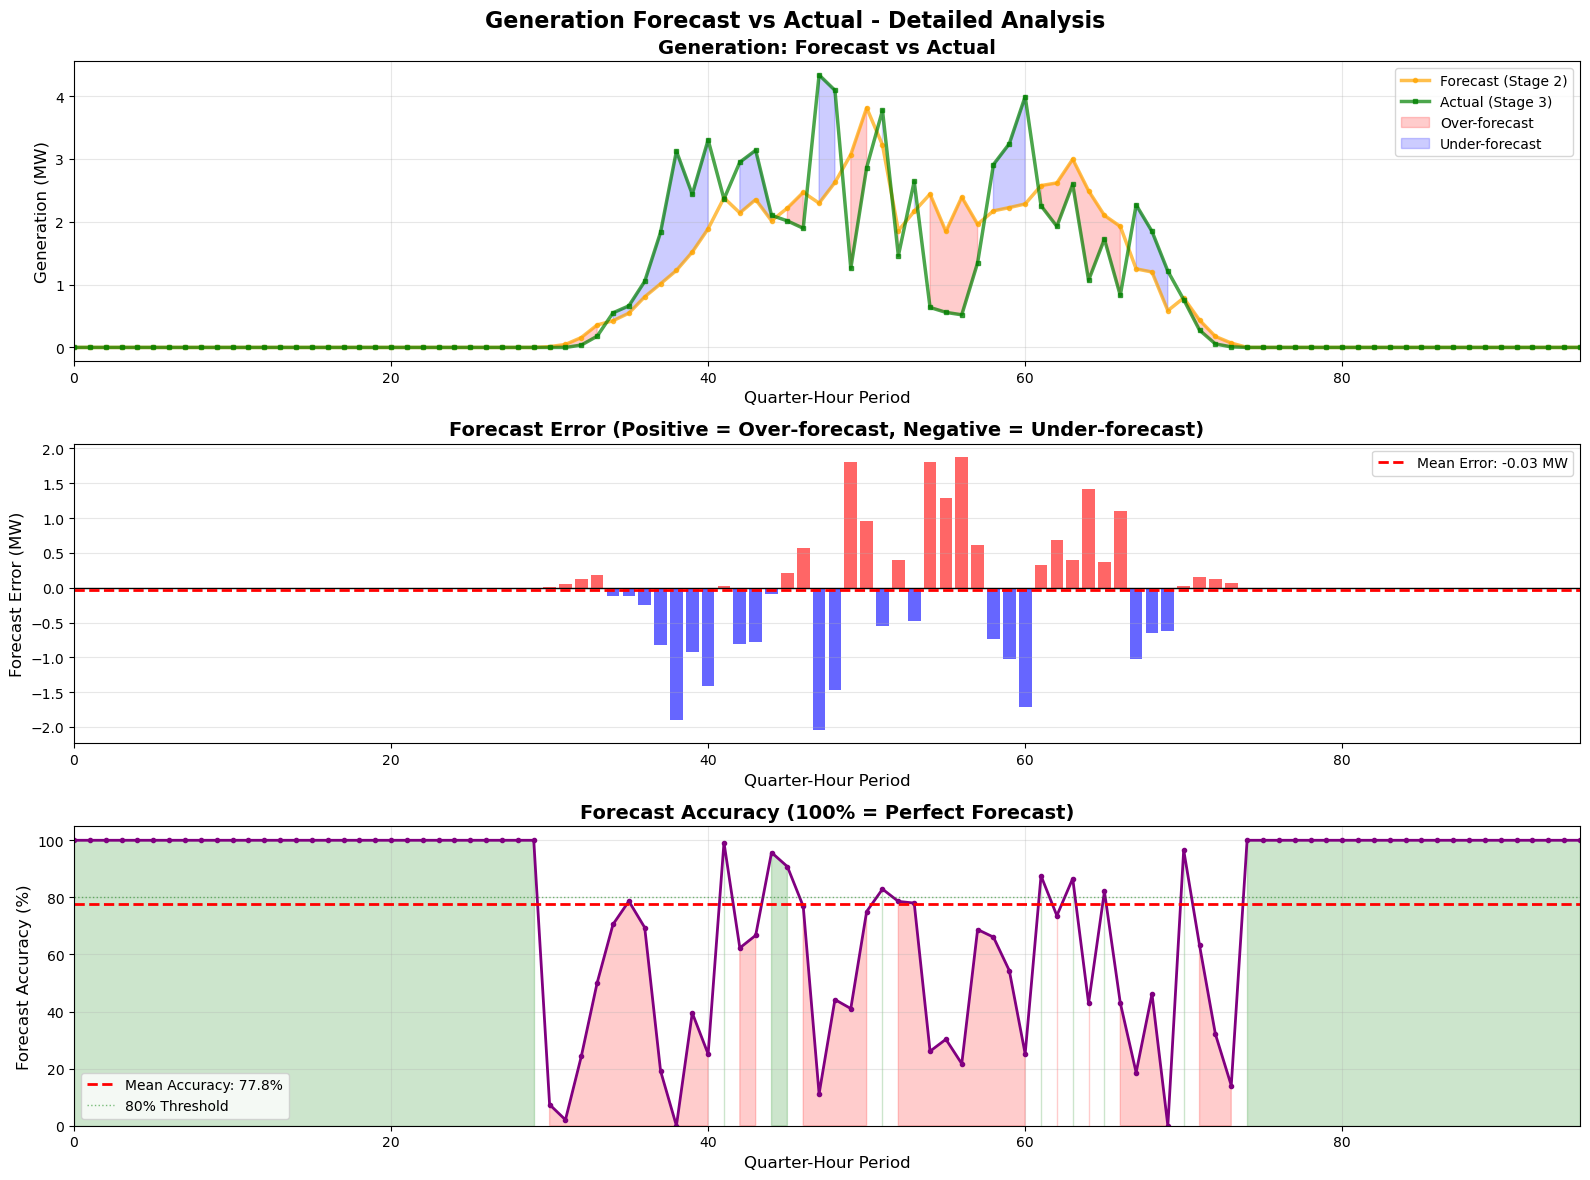

Generation forecast vs actual detailed analysis saved.


In [222]:
# ===== VISUALIZATION: FORECAST vs ACTUAL =====
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(16, 12))
fig.suptitle('Generation Forecast vs Actual - Detailed Analysis', fontsize=16, fontweight='bold')

# Create time axis
time_periods = np.arange(96)
time_labels = [f"{i//4:02d}:{(i%4)*15:02d}" for i in range(96)]

# Plot 1: Forecast vs Actual Generation
ax1 = axes[0]
ax1.plot(time_periods, Generation_f1, label='Forecast (Stage 2)', 
         color='orange', linewidth=2.5, marker='o', markersize=3, alpha=0.7)
ax1.plot(time_periods, Generation_actual, label='Actual (Stage 3)', 
         color='green', linewidth=2.5, marker='s', markersize=3, alpha=0.7)
ax1.fill_between(time_periods, Generation_f1, Generation_actual, 
                  where=(Generation_f1 >= Generation_actual), 
                  color='red', alpha=0.2, label='Over-forecast')
ax1.fill_between(time_periods, Generation_f1, Generation_actual, 
                  where=(Generation_f1 < Generation_actual), 
                  color='blue', alpha=0.2, label='Under-forecast')
ax1.set_xlabel('Quarter-Hour Period', fontsize=12)
ax1.set_ylabel('Generation (MW)', fontsize=12)
ax1.set_title('Generation: Forecast vs Actual', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 95)

# Plot 2: Forecast Error (MW)
ax2 = axes[1]
forecast_error_MW = Generation_f1 - Generation_actual
colors = ['red' if e > 0 else 'blue' for e in forecast_error_MW]
ax2.bar(time_periods, forecast_error_MW, color=colors, alpha=0.6, width=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.axhline(y=forecast_error_MW.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean Error: {forecast_error_MW.mean():.2f} MW')
ax2.set_xlabel('Quarter-Hour Period', fontsize=12)
ax2.set_ylabel('Forecast Error (MW)', fontsize=12)
ax2.set_title('Forecast Error (Positive = Over-forecast, Negative = Under-forecast)', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xlim(0, 95)

# Plot 3: Forecast Accuracy (%)
ax3 = axes[2]
forecast_accuracy = (1 - np.abs(forecast_error_MW) / (Generation_f1 + 0.001)) * 100
forecast_accuracy = np.clip(forecast_accuracy, 0, 100)  # Clip to 0-100%
ax3.plot(time_periods, forecast_accuracy, color='purple', linewidth=2, marker='o', markersize=3)
ax3.axhline(y=forecast_accuracy.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean Accuracy: {forecast_accuracy.mean():.1f}%')
ax3.axhline(y=80, color='green', linestyle=':', linewidth=1, alpha=0.5, label='80% Threshold')
ax3.fill_between(time_periods, 0, forecast_accuracy, 
                  where=(forecast_accuracy >= 80), color='green', alpha=0.2)
ax3.fill_between(time_periods, 0, forecast_accuracy, 
                  where=(forecast_accuracy < 80), color='red', alpha=0.2)
ax3.set_xlabel('Quarter-Hour Period', fontsize=12)
ax3.set_ylabel('Forecast Accuracy (%)', fontsize=12)
ax3.set_title('Forecast Accuracy (100% = Perfect Forecast)', fontsize=14, fontweight='bold')
ax3.legend(loc='best', fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 95)
ax3.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('Generation forecast vs actual detailed analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Generation forecast vs actual detailed analysis saved.')




## 6.5 DA and ID Market Prices

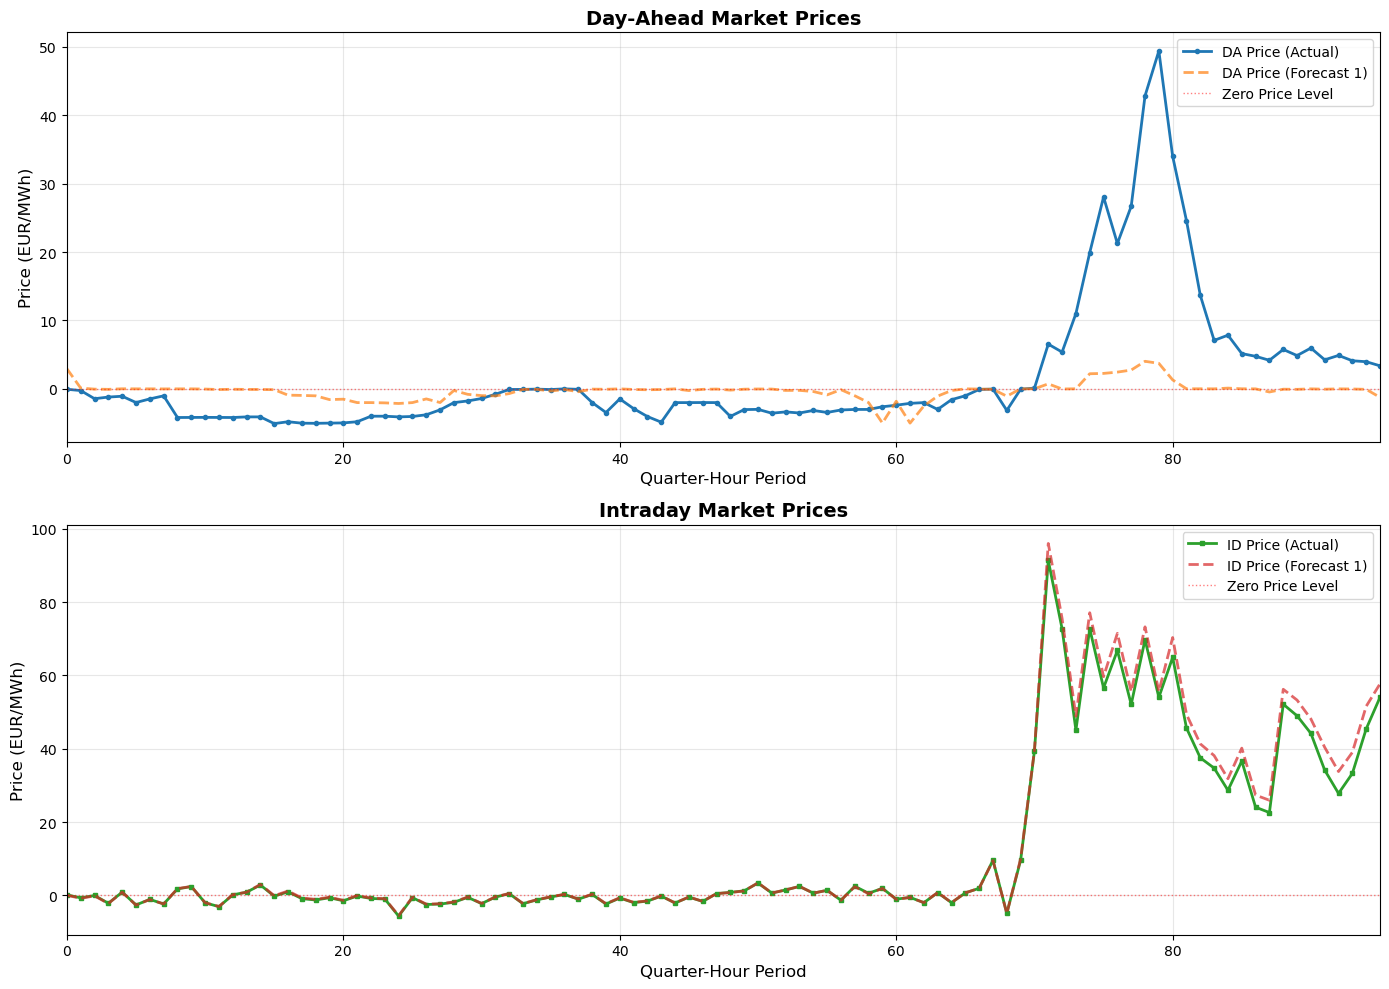

DA and ID market prices saved.

MARKET PRICE STATISTICS

📊 DAY-AHEAD MARKET PRICES
  Actual:    Min=-5.09, Max=49.41, Mean=1.73 EUR/MWh
  Forecast:  Min=-5.02, Max=4.02, Mean=-0.29 EUR/MWh
  Forecast Error (Mean): -2.02 EUR/MWh

📊 INTRADAY MARKET PRICES
  Actual:    Min=-5.66, Max=91.36, Mean=12.93 EUR/MWh
  Forecast:  Min=-5.51, Max=95.99, Mean=14.02 EUR/MWh
  Forecast Error (Mean): 1.09 EUR/MWh

📊 PRICE SPREAD (DA vs ID)
  Actual Spread:    Mean=-11.20 EUR/MWh
  Forecast Spread:  Mean=-14.31 EUR/MWh

📊 NEGATIVE PRICE PERIODS
  DA Actual:    70 periods (72.9%)
  DA Forecast:  79 periods (82.3%)
  ID Actual:    42 periods (43.8%)
  ID Forecast:  42 periods (43.8%)


In [224]:
# Plot DA and ID market prices (actual and forecast)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
time_periods = np.arange(96)

# Subplot 1: Day-Ahead Market Prices
ax1 = axes[0]
ax1.plot(time_periods, DA_p_actual, label='DA Price (Actual)', linewidth=2, color='#1f77b4', marker='o', markersize=3)
ax1.plot(time_periods, DA_p_f1, label='DA Price (Forecast 1)', linewidth=2, color='#ff7f0e', linestyle='--', alpha=0.7)
ax1.axhline(y=0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Zero Price Level')
ax1.set_xlabel('Quarter-Hour Period', fontsize=12)
ax1.set_ylabel('Price (EUR/MWh)', fontsize=12)
ax1.set_title('Day-Ahead Market Prices', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 95)

# Subplot 2: Intraday Market Prices
ax2 = axes[1]
ax2.plot(time_periods, ID_p_actual, label='ID Price (Actual)', linewidth=2, color='#2ca02c', marker='s', markersize=3)
ax2.plot(time_periods, ID_p_f1, label='ID Price (Forecast 1)', linewidth=2, color='#d62728', linestyle='--', alpha=0.7)
ax2.axhline(y=0, color='red', linestyle=':', linewidth=1, alpha=0.5, label='Zero Price Level')
ax2.set_xlabel('Quarter-Hour Period', fontsize=12)
ax2.set_ylabel('Price (EUR/MWh)', fontsize=12)
ax2.set_title('Intraday Market Prices', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 95)

plt.tight_layout()
plt.savefig('DA and ID market prices.png', dpi=150, bbox_inches='tight')
plt.show()
print('DA and ID market prices saved.')


# Print price statistics
print("\n" + "="*70)
print("MARKET PRICE STATISTICS")
print("="*70)

print("\n📊 DAY-AHEAD MARKET PRICES")
print(f"  Actual:    Min={DA_p_actual.min():.2f}, Max={DA_p_actual.max():.2f}, Mean={DA_p_actual.mean():.2f} EUR/MWh")
print(f"  Forecast:  Min={DA_p_f1.min():.2f}, Max={DA_p_f1.max():.2f}, Mean={DA_p_f1.mean():.2f} EUR/MWh")
print(f"  Forecast Error (Mean): {(DA_p_f1.mean() - DA_p_actual.mean()):.2f} EUR/MWh")

print("\n📊 INTRADAY MARKET PRICES")
print(f"  Actual:    Min={ID_p_actual.min():.2f}, Max={ID_p_actual.max():.2f}, Mean={ID_p_actual.mean():.2f} EUR/MWh")
print(f"  Forecast:  Min={ID_p_f1.min():.2f}, Max={ID_p_f1.max():.2f}, Mean={ID_p_f1.mean():.2f} EUR/MWh")
print(f"  Forecast Error (Mean): {(ID_p_f1.mean() - ID_p_actual.mean()):.2f} EUR/MWh")

print("\n📊 PRICE SPREAD (DA vs ID)")
print(f"  Actual Spread:    Mean={((DA_p_actual - ID_p_actual).mean()):.2f} EUR/MWh")
print(f"  Forecast Spread:  Mean={((DA_p_f1 - ID_p_f1).mean()):.2f} EUR/MWh")

# Count negative price periods
neg_da_actual = np.sum(DA_p_actual < 0)
neg_da_forecast = np.sum(DA_p_f1 < 0)
neg_id_actual = np.sum(ID_p_actual < 0)
neg_id_forecast = np.sum(ID_p_f1 < 0)

print("\n📊 NEGATIVE PRICE PERIODS")
print(f"  DA Actual:    {neg_da_actual} periods ({neg_da_actual/96*100:.1f}%)")
print(f"  DA Forecast:  {neg_da_forecast} periods ({neg_da_forecast/96*100:.1f}%)")
print(f"  ID Actual:    {neg_id_actual} periods ({neg_id_actual/96*100:.1f}%)")
print(f"  ID Forecast:  {neg_id_forecast} periods ({neg_id_forecast/96*100:.1f}%)")
print("="*70)

## 6.6 Market Prices vs Trading Volumes

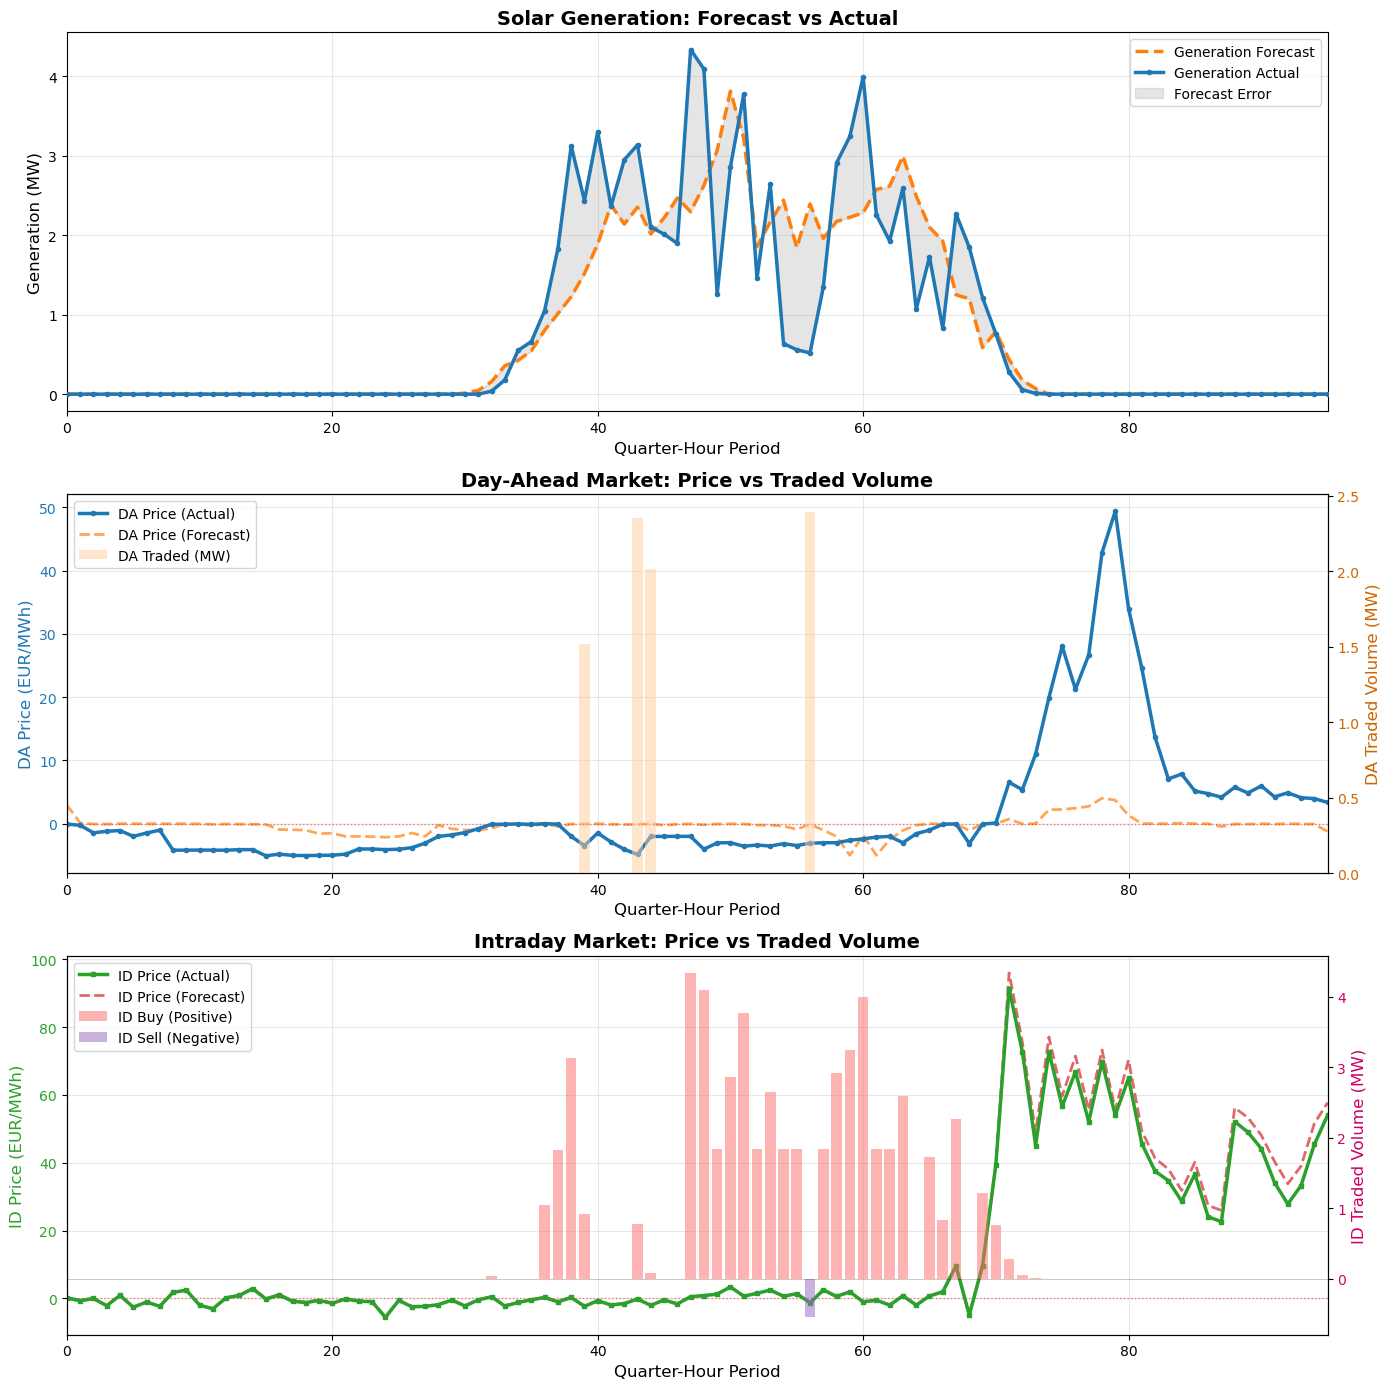


PRICE vs VOLUME ANALYSIS

📊 GENERATION FORECAST vs ACTUAL
  Forecast Total:   18.78 MWh
  Actual Total:     19.52 MWh
  Forecast Error:   -0.73 MWh (-3.9%)
  Forecast Avg:     0.78 MW
  Actual Avg:       0.81 MW

📊 DAY-AHEAD MARKET
  Total DA Volume:  8.28 MW (cumulative)
  Avg DA Volume:    0.09 MW per period
  Avg DA Price:     1.73 EUR/MWh
  Total DA Revenue: -7.06 EUR

📊 INTRADAY MARKET
  Buy Periods:      31 periods, 58.32 MW total
  Sell Periods:     1 periods, 0.55 MW total
  Net ID Position:  57.77 MW
  Avg ID Price:     12.93 EUR/MWh
  Total ID Revenue: 32.67 EUR


In [226]:
# Create triple-axis plots showing production forecast, DA and ID markets
fig, (ax0, ax1, ax2) = plt.subplots(3, 1, figsize=(14, 14))
time_periods = np.arange(96)

# ===== SUBPLOT 0: Production Forecast vs Actual =====
ax0.plot(time_periods, Generation_f1, color='#ff7f0e', linewidth=2.5, linestyle='--', label='Generation Forecast', zorder=2)
ax0.plot(time_periods, Generation_actual, color='#1f77b4', linewidth=2.5, marker='o', markersize=3, label='Generation Actual', zorder=3)
ax0.fill_between(time_periods, Generation_f1, Generation_actual, alpha=0.2, color='gray', label='Forecast Error')
ax0.set_xlabel('Quarter-Hour Period', fontsize=12)
ax0.set_ylabel('Generation (MW)', fontsize=12)
ax0.set_title('Solar Generation: Forecast vs Actual', fontsize=14, fontweight='bold')
ax0.legend(loc='upper right', fontsize=10)
ax0.grid(True, alpha=0.3)
ax0.set_xlim(0, 95)

# ===== SUBPLOT 1: DA Market - Price and Volume =====
color_price = '#1f77b4'
color_price_forecast = '#ff7f0e'
color_volume = '#ffcc99'

# Plot DA price on left y-axis
ax1_left = ax1
ax1_left.plot(time_periods, DA_p_actual, color=color_price, linewidth=2.5, marker='o', markersize=3, label='DA Price (Actual)', zorder=3)
ax1_left.plot(time_periods, DA_p_f1, color=color_price_forecast, linewidth=2, linestyle='--', alpha=0.7, label='DA Price (Forecast)', zorder=2)
ax1_left.axhline(y=0, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax1_left.set_xlabel('Quarter-Hour Period', fontsize=12)
ax1_left.set_ylabel('DA Price (EUR/MWh)', fontsize=12, color=color_price)
ax1_left.tick_params(axis='y', labelcolor=color_price)
ax1_left.set_title('Day-Ahead Market: Price vs Traded Volume', fontsize=14, fontweight='bold')
ax1_left.grid(True, alpha=0.3)
ax1_left.set_xlim(0, 95)

# Plot DA volume on right y-axis
ax1_right = ax1_left.twinx()
ax1_right.bar(time_periods, DA_stage2_results, color=color_volume, alpha=0.5, width=0.8, label='DA Traded (MW)', zorder=1)
ax1_right.set_ylabel('DA Traded Volume (MW)', fontsize=12, color='#cc6600')
ax1_right.tick_params(axis='y', labelcolor='#cc6600')

# Combine legends
lines1, labels1 = ax1_left.get_legend_handles_labels()
lines2, labels2 = ax1_right.get_legend_handles_labels()
ax1_left.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# ===== SUBPLOT 2: ID Market - Price and Volume =====
color_price_id = '#2ca02c'
color_price_id_forecast = '#d62728'
color_volume_id = '#ffb3ba'

# Plot ID price on left y-axis
ax2_left = ax2
ax2_left.plot(time_periods, ID_p_actual, color=color_price_id, linewidth=2.5, marker='s', markersize=3, label='ID Price (Actual)', zorder=3)
ax2_left.plot(time_periods, ID_p_f1, color=color_price_id_forecast, linewidth=2, linestyle='--', alpha=0.7, label='ID Price (Forecast)', zorder=2)
ax2_left.axhline(y=0, color='red', linestyle=':', linewidth=1, alpha=0.5)
ax2_left.set_xlabel('Quarter-Hour Period', fontsize=12)
ax2_left.set_ylabel('ID Price (EUR/MWh)', fontsize=12, color=color_price_id)
ax2_left.tick_params(axis='y', labelcolor=color_price_id)
ax2_left.set_title('Intraday Market: Price vs Traded Volume', fontsize=14, fontweight='bold')
ax2_left.grid(True, alpha=0.3)
ax2_left.set_xlim(0, 95)

# Plot ID volume on right y-axis (showing net position from Stage 3)
ax2_right = ax2_left.twinx()
ID_net = np.array(ID_stage3_results)
# Color bars based on buy (positive) or sell (negative)
colors_id = ['#ff6b6b' if x > 0 else '#9467bd' for x in ID_net]
ax2_right.bar(time_periods, ID_net, color=colors_id, alpha=0.5, width=0.8, label='ID Traded (MW)', zorder=1)
ax2_right.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.3)
ax2_right.set_ylabel('ID Traded Volume (MW)', fontsize=12, color='#cc0066')
ax2_right.tick_params(axis='y', labelcolor='#cc0066')

# Combine legends with color explanation
from matplotlib.patches import Patch
lines1, labels1 = ax2_left.get_legend_handles_labels()
legend_elements = lines1 + [
    Patch(facecolor='#ff6b6b', alpha=0.5, label='ID Buy (Positive)'),
    Patch(facecolor='#9467bd', alpha=0.5, label='ID Sell (Negative)')
]
ax2_left.legend(handles=legend_elements, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("PRICE vs VOLUME ANALYSIS")
print("="*70)

print("\n📊 GENERATION FORECAST vs ACTUAL")
print(f"  Forecast Total:   {Generation_f1.sum()/4:.2f} MWh")
print(f"  Actual Total:     {Generation_actual.sum()/4:.2f} MWh")
print(f"  Forecast Error:   {(Generation_f1.sum() - Generation_actual.sum())/4:.2f} MWh ({((Generation_f1.sum() - Generation_actual.sum())/Generation_f1.sum())*100:.1f}%)")
print(f"  Forecast Avg:     {Generation_f1.mean():.2f} MW")
print(f"  Actual Avg:       {Generation_actual.mean():.2f} MW")

print("\n📊 DAY-AHEAD MARKET")
print(f"  Total DA Volume:  {sum(DA_stage2_results):.2f} MW (cumulative)")
print(f"  Avg DA Volume:    {np.mean(DA_stage2_results):.2f} MW per period")
print(f"  Avg DA Price:     {DA_p_actual.mean():.2f} EUR/MWh")
print(f"  Total DA Revenue: {sum([DA_stage2_results[t] * DA_p_actual[t]/4 for t in range(96)]):.2f} EUR")

print("\n📊 INTRADAY MARKET")
id_buys_count = sum(1 for x in ID_net if x > 0)
id_sells_count = sum(1 for x in ID_net if x < 0)
id_buy_volume = sum(x for x in ID_net if x > 0)
id_sell_volume = sum(abs(x) for x in ID_net if x < 0)

print(f"  Buy Periods:      {id_buys_count} periods, {id_buy_volume:.2f} MW total")
print(f"  Sell Periods:     {id_sells_count} periods, {id_sell_volume:.2f} MW total")
print(f"  Net ID Position:  {sum(ID_net):.2f} MW")
print(f"  Avg ID Price:     {ID_p_actual.mean():.2f} EUR/MWh")

# Calculate ID market cost/revenue
id_revenue = sum([ID_stage3_results[t] * ID_p_actual[t]/4 for t in range(96)])
print(f"  Total ID Revenue: {id_revenue:.2f} EUR")
print("="*70)

## Day-Ahead Price Comparison Visualization

=== ACTUAL DA Prices for October 4-5, 2025 ===
Oct 4: Forecast Source Day | Oct 5: Analysis Day
Using ACTUAL DA prices from DA_p_full (already processed and sorted)



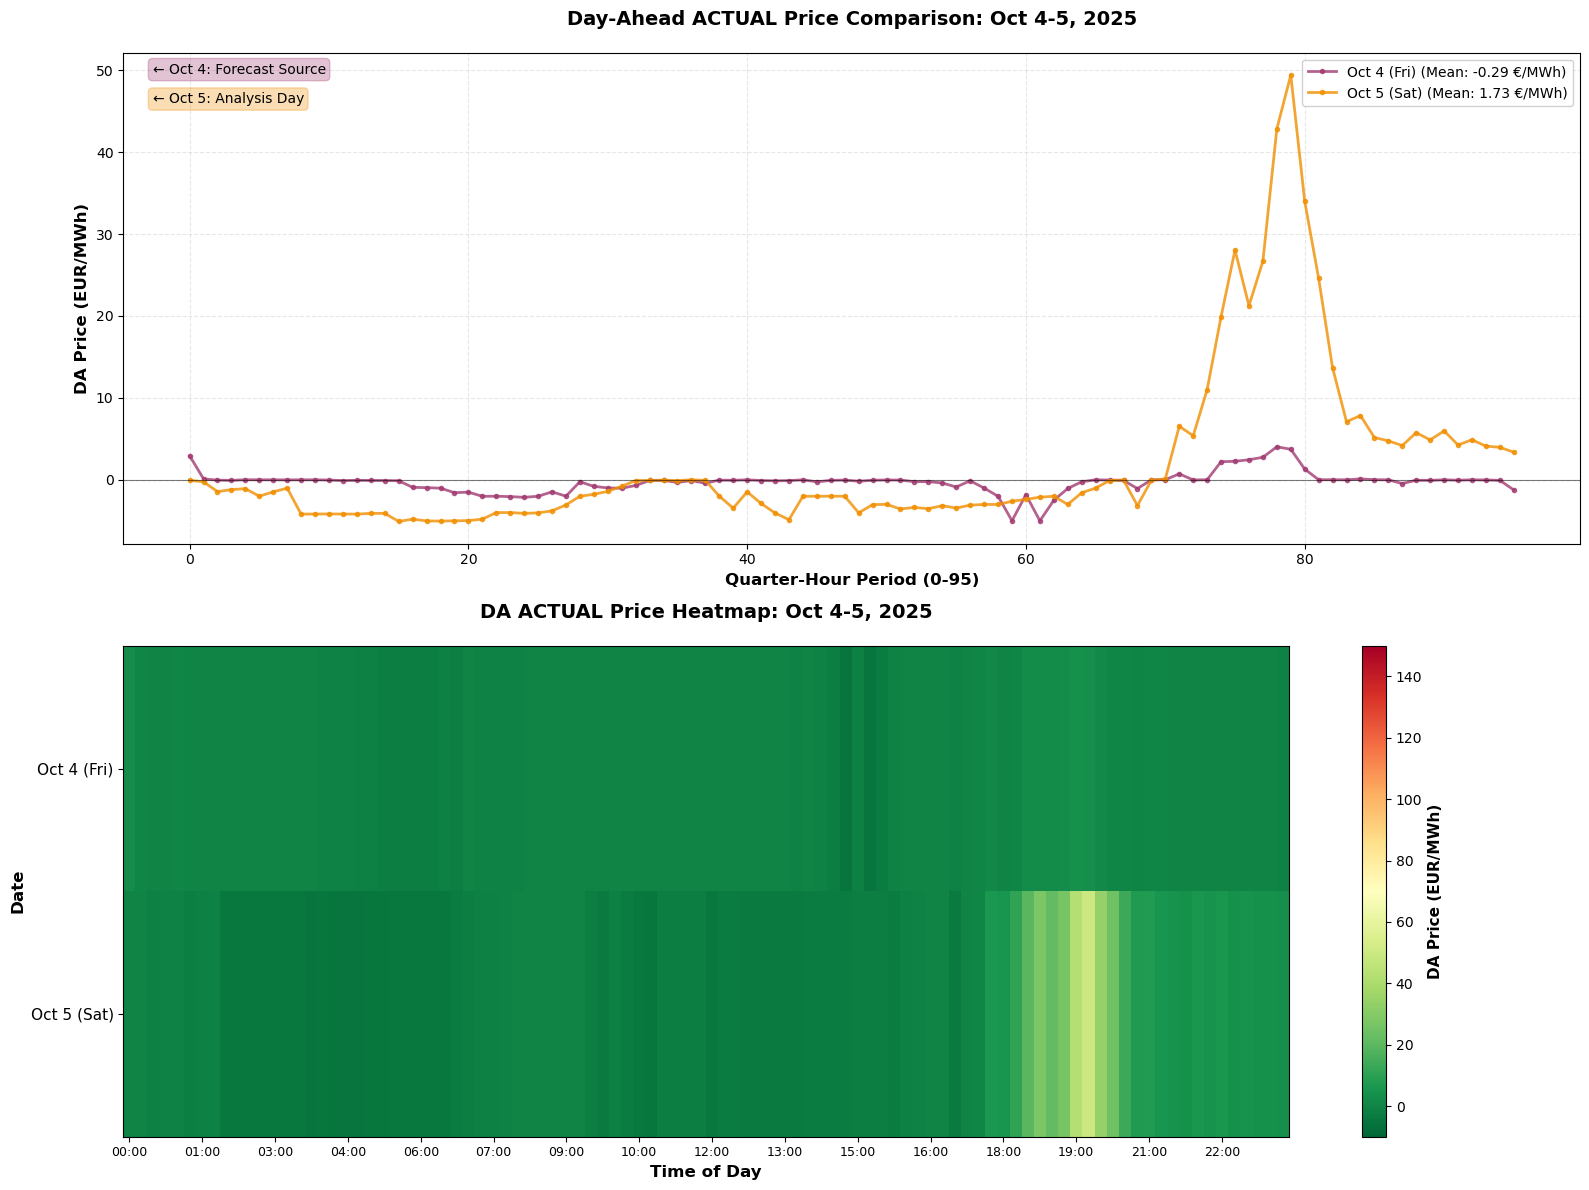


=== Summary Statistics by Day (ACTUAL DA Prices) ===

Oct 4 (Fri):
  Mean:      -0.29 EUR/MWh
  Median:    -0.08 EUR/MWh
  Min:       -5.02 EUR/MWh
  Max:        4.02 EUR/MWh
  Std:        1.32 EUR/MWh
  Negative price periods: 79/96

Oct 5 (Sat):
  Mean:       1.73 EUR/MWh
  Median:    -1.90 EUR/MWh
  Min:       -5.09 EUR/MWh
  Max:       49.41 EUR/MWh
  Std:        9.99 EUR/MWh
  Negative price periods: 70/96



In [229]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Extract DA prices for October 4 and 5 only
print("=== ACTUAL DA Prices for October 4-5, 2025 ===")
print("Oct 4: Forecast Source Day | Oct 5: Analysis Day")
print("Using ACTUAL DA prices from DA_p_full (already processed and sorted)\n")

# Use the already-processed DA_p_full which contains actual DA prices
# (This was created earlier in Section 4 with proper sorting and processing)

# Filter for October 4-5 actual dates
oct_4_start = pd.Timestamp("2025-10-04 00:00:00").tz_localize("Europe/Berlin")
oct_5_end = pd.Timestamp("2025-10-05 23:45:00").tz_localize("Europe/Berlin")

# Get data for Oct 4-5 actual dates
oct_3_6_data = DA_p_full[
    (DA_p_full['PeriodStartLocal'] >= oct_4_start) & (DA_p_full['PeriodStartLocal'] <= oct_5_end)
].copy()

# Add date column for grouping
oct_3_6_data['Date'] = oct_3_6_data['PeriodStartLocal'].dt.date
oct_3_6_data['Time'] = oct_3_6_data['PeriodStartLocal'].dt.time

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

# Plot 1: Line chart showing Oct 4 and Oct 5
colors_days = ['#A23B72', '#F18F01']  # Purple for Oct 4, Yellow for Oct 5
day_names = ['Oct 4 (Fri)', 'Oct 5 (Sat)']
unique_dates = sorted(oct_3_6_data['Date'].unique())

for idx, date in enumerate(unique_dates):
    day_data = oct_3_6_data[oct_3_6_data['Date'] == date].copy()
    day_data['Period'] = range(len(day_data))
    
    ax1.plot(day_data['Period'], day_data['DA_price'], 
             color=colors_days[idx], linewidth=2, marker='o', markersize=3,
             label=f'{day_names[idx]} (Mean: {day_data["DA_price"].mean():.2f} €/MWh)', 
             alpha=0.8)

ax1.set_xlabel('Quarter-Hour Period (0-95)', fontsize=12, fontweight='bold')
ax1.set_ylabel('DA Price (EUR/MWh)', fontsize=12, fontweight='bold')
ax1.set_title('Day-Ahead ACTUAL Price Comparison: Oct 4-5, 2025', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='best', fontsize=10, framealpha=0.9)
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)

# Highlight key days
ax1.text(0.02, 0.98, '← Oct 4: Forecast Source', transform=ax1.transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', 
         facecolor='#A23B72', alpha=0.3, edgecolor='#A23B72'))
ax1.text(0.02, 0.92, '← Oct 5: Analysis Day', transform=ax1.transAxes,
         fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', 
         facecolor='#F18F01', alpha=0.3, edgecolor='#F18F01'))

# Plot 2: Heatmap-style view
heatmap_data = oct_3_6_data.pivot_table(
    index='Time', 
    columns='Date', 
    values='DA_price'
)

im = ax2.imshow(heatmap_data.T.values, aspect='auto', cmap='RdYlGn_r', 
                interpolation='nearest', vmin=-10, vmax=150)

ax2.set_yticks(range(len(unique_dates)))
ax2.set_yticklabels([day_names[i] for i in range(len(unique_dates))], fontsize=11)
ax2.set_xticks(range(0, 96, 6))
ax2.set_xticklabels([f'{i//4:02d}:00' for i in range(0, 96, 6)], fontsize=9)
ax2.set_xlabel('Time of Day', fontsize=12, fontweight='bold')
ax2.set_ylabel('Date', fontsize=12, fontweight='bold')
ax2.set_title('DA ACTUAL Price Heatmap: Oct 4-5, 2025', fontsize=14, fontweight='bold', pad=20)

# Add colorbar
cbar = plt.colorbar(im, ax=ax2)
cbar.set_label('DA Price (EUR/MWh)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== Summary Statistics by Day (ACTUAL DA Prices) ===\n")
for idx, date in enumerate(unique_dates):
    day_data = oct_3_6_data[oct_3_6_data['Date'] == date]
    print(f"{day_names[idx]}:")
    print(f"  Mean:   {day_data['DA_price'].mean():8.2f} EUR/MWh")
    print(f"  Median: {day_data['DA_price'].median():8.2f} EUR/MWh")
    print(f"  Min:    {day_data['DA_price'].min():8.2f} EUR/MWh")
    print(f"  Max:    {day_data['DA_price'].max():8.2f} EUR/MWh")
    print(f"  Std:    {day_data['DA_price'].std():8.2f} EUR/MWh")
    print(f"  Negative price periods: {(day_data['DA_price'] < 0).sum()}/96")
    print()

In [230]:
# Create detailed comparison table
print("\n=== Detailed DA Price Comparison Table ===")
print("(Showing key hours: midnight, 6am, noon, 6pm, midnight)\n")

# Select key time periods
key_hours = [0, 24, 48, 72, 95]  # Midnight, 6am, noon, 6pm, last period

comparison_table = []
for period_idx in key_hours:
    row_data = {'Period': period_idx, 'Time': f"{(period_idx//4):02d}:{(period_idx%4)*15:02d}"}
    
    for idx, date in enumerate(unique_dates):
        day_data = oct_3_6_data[oct_3_6_data['Date'] == date].reset_index(drop=True)
        if period_idx < len(day_data):
            row_data[day_names[idx]] = f"{day_data.loc[period_idx, 'DA_price']:.2f}"
        else:
            row_data[day_names[idx]] = "N/A"
    
    comparison_table.append(row_data)

comparison_df = pd.DataFrame(comparison_table)
print(comparison_df.to_string(index=False))

# Create full detailed table (showing all 96 periods)
print("\n\n=== Full DA Price Table (All 96 Periods) ===")
print("Prices in EUR/MWh\n")

# Pivot the data to show all days side by side
full_table = oct_3_6_data.pivot_table(
    index=oct_3_6_data['PeriodStartLocal'].dt.time,
    columns='Date',
    values='DA_price',
    aggfunc='first'
)

# Rename columns to be more readable
full_table.columns = [day_names[i] for i in range(len(unique_dates))]
full_table.index.name = 'Time'

# Display first 20 and last 10 rows
print("First 20 periods (00:00 - 04:45):")
print(full_table.head(20).to_string())

print("\n... (periods 21-75 omitted for brevity) ...\n")

print("Last 20 periods (19:00 - 23:45):")
print(full_table.tail(20).to_string())

# Export full table
full_table_reset = full_table.reset_index()
print(f"\n\nFull table shape: {full_table_reset.shape}")
print(f"Total periods per day: {len(full_table_reset)}")

# Show the full table
full_table_reset


=== Detailed DA Price Comparison Table ===
(Showing key hours: midnight, 6am, noon, 6pm, midnight)

 Period  Time Oct 4 (Fri) Oct 5 (Sat)
      0 00:00        2.93       -0.07
     24 06:00       -2.15       -4.11
     48 12:00       -0.19       -4.04
     72 18:00       -0.03        5.37
     95 23:45       -1.25        3.36


=== Full DA Price Table (All 96 Periods) ===
Prices in EUR/MWh

First 20 periods (00:00 - 04:45):
          Oct 4 (Fri)  Oct 5 (Sat)
Time                              
00:00:00         2.93        -0.07
00:15:00         0.10        -0.26
00:30:00        -0.05        -1.45
00:45:00        -0.08        -1.21
01:00:00         0.00        -1.09
01:15:00        -0.01        -2.01
01:30:00        -0.01        -1.48
01:45:00        -0.02        -1.03
02:00:00        -0.01        -4.20
02:15:00        -0.01        -4.19
02:30:00        -0.04        -4.18
02:45:00        -0.11        -4.19
03:00:00        -0.07        -4.20
03:15:00        -0.09        -4.11
03:30:00   

,Time,Oct 4 (Fri),Oct 5 (Sat)
0,00:00:00,2.93,-0.07
1,00:15:00,0.10,-0.26
2,00:30:00,-0.05,-1.45
3,00:45:00,-0.08,-1.21
4,01:00:00,0.00,-1.09
...,...,...,...
91,22:45:00,-0.06,4.24
92,23:00:00,-0.01,4.88
93,23:15:00,-0.03,4.10
94,23:30:00,-0.08,3.96


## ADDITIONAL VISUALIZATION

### KPI SUMMARY CARD

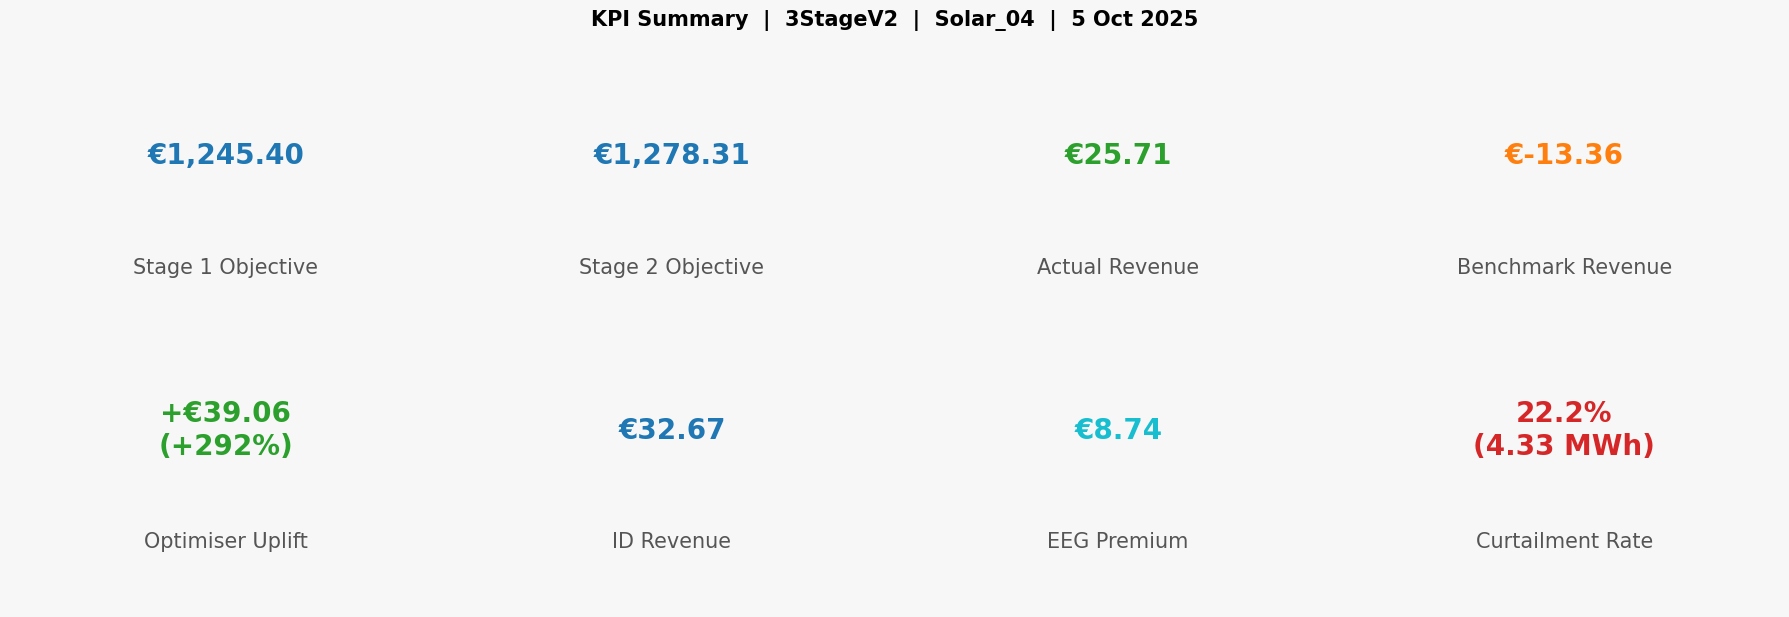

KPI summary saved.

Stage 1 Objective: €1,245.40
Stage 2 Objective: €1,278.31
Actual Revenue:    €25.71
Benchmark Revenue: €-13.36
Optimiser Uplift:  €39.06 (+292%)


In [239]:

import matplotlib.pyplot as plt
import numpy as np

total_rev        = results_df['Total_Revenue_EUR'].sum()
da_rev           = results_df['DA_Revenue_EUR'].sum()
id_rev           = results_df['ID_Revenue_EUR'].sum()
eeg_rev          = results_df['Market premium_EUR'].sum()
benchmark_rev    = benchmark_total_revenue_per_period.sum()
uplift_eur       = total_rev - benchmark_rev
uplift_pct       = (uplift_eur / abs(benchmark_rev)) * 100 if benchmark_rev != 0 else 0
possible_mwh     = (results_df['Generation_Possible_MW'] / 4).sum()
delivered_mwh    = (results_df['Generation_Delivered_MW'] / 4).sum()
curtailed_mwh    = possible_mwh - delivered_mwh
curtailment_rate = (curtailed_mwh / possible_mwh * 100) if possible_mwh > 0 else 0

# ── Read Stage objectives dynamically ────────────────────────────────
stage1_obj = model_stage1.objective.value()
stage2_obj = model_stage2.objective.value()

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
fig.suptitle('KPI Summary  |  3StageV2  |  Solar_04  |  5 Oct 2025',
             fontsize=15, fontweight='bold', y=1.02)
fig.patch.set_facecolor('#F7F7F7')

kpis = [
    ('Stage 1 Objective',    f'\u20ac{stage1_obj:,.2f}',              '#1F77B4'),
    ('Stage 2 Objective',    f'\u20ac{stage2_obj:,.2f}',              '#1F77B4'),
    ('Actual Revenue',       f'\u20ac{total_rev:.2f}',                '#2CA02C'),
    ('Benchmark Revenue',    f'\u20ac{benchmark_rev:.2f}',            '#FF7F0E'),
    ('Optimiser Uplift',     f'+\u20ac{uplift_eur:.2f}\n(+{uplift_pct:.0f}%)', '#2CA02C'),
    ('ID Revenue',           f'\u20ac{id_rev:.2f}',                   '#1F77B4'),
    ('EEG Premium',          f'\u20ac{eeg_rev:.2f}',                  '#17BECF'),
    ('Curtailment Rate',     f'{curtailment_rate:.1f}%\n({curtailed_mwh:.2f} MWh)', '#D62728'),
]

for ax, (label, value, color) in zip(axes.flat, kpis):
    ax.set_facecolor('white')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')
    ax.text(0.5, 0.68, value, ha='center', va='center', fontsize=20,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=15,
            color='#555555', transform=ax.transAxes)
    for spine in ax.spines.values():
        spine.set_edgecolor('#DDDDDD')
        spine.set_linewidth(1.5)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('kpi_summary_3stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('KPI summary saved.')
print(f'\nStage 1 Objective: €{stage1_obj:,.2f}')
print(f'Stage 2 Objective: €{stage2_obj:,.2f}')
print(f'Actual Revenue:    €{total_rev:.2f}')
print(f'Benchmark Revenue: €{benchmark_rev:.2f}')
print(f'Optimiser Uplift:  €{uplift_eur:.2f} (+{uplift_pct:.0f}%)')

### REVENUE BREAKDOWN

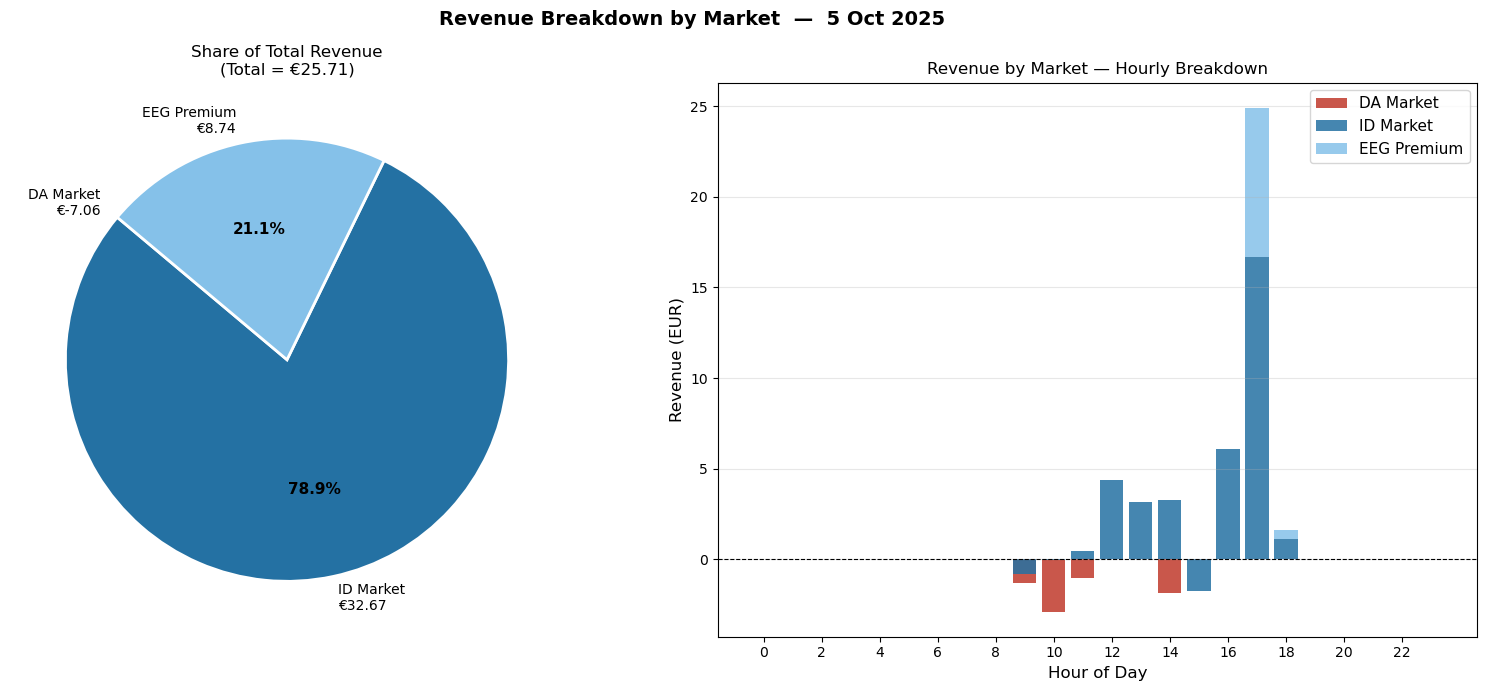

Revenue breakdown saved.


In [242]:

import matplotlib.pyplot as plt
import numpy as np

da_rev  = results_df['DA_Revenue_EUR'].sum()
id_rev  = results_df['ID_Revenue_EUR'].sum()
eeg_rev = results_df['Market premium_EUR'].sum()
total   = results_df['Total_Revenue_EUR'].sum()

labels = ['DA Market', 'ID Market', 'EEG Premium']
values = [da_rev, id_rev, eeg_rev]
colors = ['#C0392B', '#2471A3', '#85C1E9']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Revenue Breakdown by Market  —  5 Oct 2025', fontsize=14, fontweight='bold')

# PIE
pie_vals   = [max(v, 0) for v in values]
pie_labels = [f"{l}\n\u20ac{v:.2f}" for l, v in zip(labels, values)]
wedges, texts, autotexts = ax1.pie(
    pie_vals, labels=pie_labels, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold')
ax1.set_title(f'Share of Total Revenue\n(Total = \u20ac{total:.2f})', fontsize=12)

# STACKED BAR per hour
results_df['Hour'] = results_df['PeriodStartLocal'].dt.hour
hourly = results_df.groupby('Hour').agg(
    DA=('DA_Revenue_EUR', 'sum'),
    ID=('ID_Revenue_EUR', 'sum'),
    EEG=('Market premium_EUR', 'sum')
).reset_index()

hours   = hourly['Hour'].values
b1      = hourly['DA'].values
b2      = hourly['ID'].values
b3      = hourly['EEG'].values
bottom2 = np.where(b1 > 0, b1, 0)
bottom3 = bottom2 + np.where(b2 > 0, b2, 0)

ax2.bar(hours, b1, color='#C0392B', alpha=0.85, label='DA Market')
ax2.bar(hours, b2, color='#2471A3', alpha=0.85, label='ID Market',   bottom=bottom2)
ax2.bar(hours, b3, color='#85C1E9', alpha=0.85, label='EEG Premium', bottom=bottom3)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xlabel('Hour of Day', fontsize=12)
ax2.set_ylabel('Revenue (EUR)', fontsize=12)
ax2.set_title('Revenue by Market — Hourly Breakdown', fontsize=12)
ax2.set_xticks(range(0, 24, 2))
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('revenue_breakdown_3stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Revenue breakdown saved.')

### Stage 1 vs Stage 2 vs Stage 3 Decision Comparison

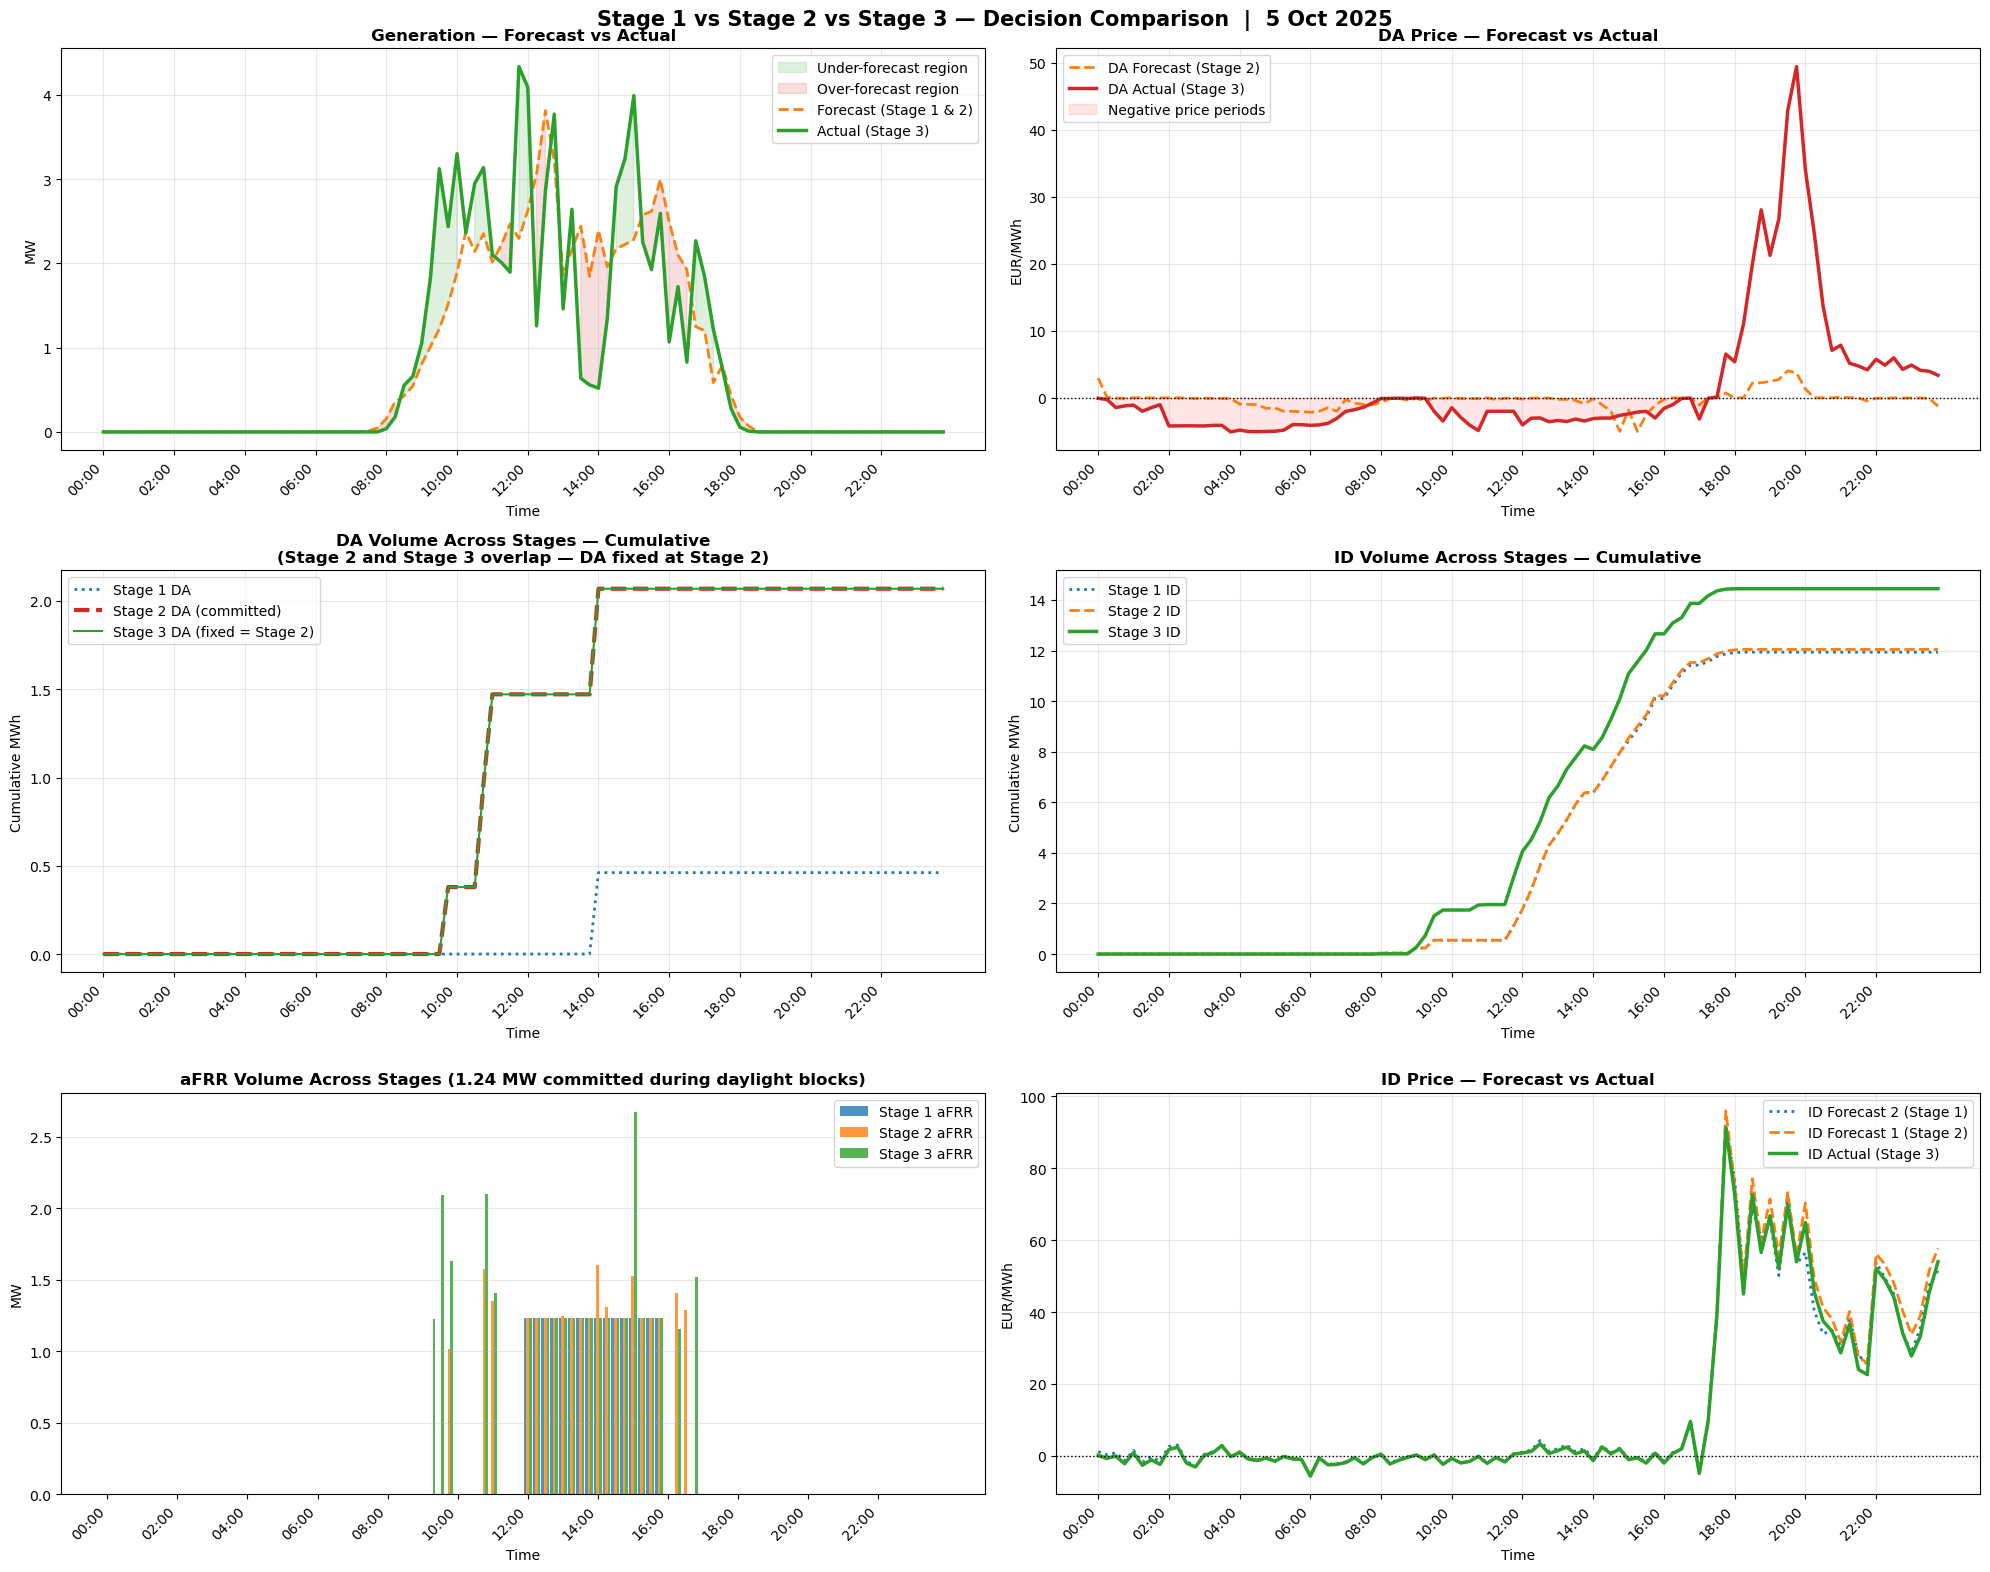

Stage comparison saved.


In [245]:
import matplotlib.pyplot as plt
import numpy as np

periods   = np.arange(96)
time_lbls = [f"{i//4:02d}:{(i%4)*15:02d}" for i in range(96)]
tick_idx  = list(range(0, 96, 8))
tick_lbls = [time_lbls[i] for i in tick_idx]

fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.suptitle('Stage 1 vs Stage 2 vs Stage 3 — Decision Comparison  |  5 Oct 2025',
             fontsize=15, fontweight='bold')

# ── 1a: Generation Forecast vs Actual ────────────────────────────────
ax = axes[0, 0]
ax.fill_between(periods, Generation_f1, Generation_actual,
                where=(np.array(Generation_actual) >= np.array(Generation_f1)),
                alpha=0.15, color='#2CA02C', label='Under-forecast region')
ax.fill_between(periods, Generation_f1, Generation_actual,
                where=(np.array(Generation_actual) < np.array(Generation_f1)),
                alpha=0.15, color='#D62728', label='Over-forecast region')
ax.plot(periods, Generation_f1,     color='#FF7F0E', linewidth=2,
        linestyle='--', label='Forecast (Stage 1 & 2)')
ax.plot(periods, Generation_actual, color='#2CA02C', linewidth=2.5,
        linestyle='-',  label='Actual (Stage 3)')
ax.set_title('Generation — Forecast vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('MW'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── 1b: DA Price Forecast vs Actual ──────────────────────────────────
ax = axes[0, 1]
ax.plot(periods, DA_p_f1,     color='#FF7F0E', linewidth=2,
        linestyle='--', label='DA Forecast (Stage 2)')
ax.plot(periods, DA_p_actual, color='#D62728', linewidth=2.5,
        linestyle='-',  label='DA Actual (Stage 3)')
ax.axhline(0, color='black', linewidth=1, linestyle=':')
ax.fill_between(periods, DA_p_actual, 0,
                where=(np.array(DA_p_actual) < 0),
                alpha=0.1, color='red', label='Negative price periods')
ax.set_title('DA Price — Forecast vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('EUR/MWh'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── 2a: DA Volume Across All Stages — Cumulative Line ────────────────
ax = axes[1, 0]
da_s1_cumsum = np.cumsum(DA_stage1_results) / 4
da_s2_cumsum = np.cumsum(DA_stage2_results) / 4
da_s3_cumsum = np.cumsum(DA_stage3_results) / 4
ax.plot(periods, da_s1_cumsum, color='#1F77B4', linewidth=2,
        linestyle=':', label='Stage 1 DA')
ax.plot(periods, da_s2_cumsum, color='#D62728', linewidth=3,
        linestyle='--', label='Stage 2 DA (committed)')
ax.plot(periods, da_s3_cumsum, color='#2CA02C', linewidth=1.5,
        linestyle='-', label='Stage 3 DA (fixed = Stage 2)')
ax.set_title('DA Volume Across Stages — Cumulative\n'
             '(Stage 2 and Stage 3 overlap — DA fixed at Stage 2)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative MWh'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── 2b: ID Volume Across All Stages — Cumulative Line ────────────────
ax = axes[1, 1]
id_s1_cumsum = np.cumsum(ID_stage1_results) / 4
id_s2_cumsum = np.cumsum(ID_stage2_results) / 4
id_s3_cumsum = np.cumsum(ID_stage3_results) / 4
ax.plot(periods, id_s1_cumsum, color='#1F77B4', linewidth=2,
        linestyle=':', label='Stage 1 ID')
ax.plot(periods, id_s2_cumsum, color='#FF7F0E', linewidth=2,
        linestyle='--', label='Stage 2 ID')
ax.plot(periods, id_s3_cumsum, color='#2CA02C', linewidth=2.5,
        linestyle='-', label='Stage 3 ID')
ax.set_title('ID Volume Across Stages — Cumulative',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative MWh'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# ── 3a: aFRR Volume Across All Stages ────────────────────────────────
ax = axes[2, 0]
width = 0.3
ax.bar(periods - width, aFRR_N_stage1_results, width,
       color='#1F77B4', alpha=0.8, label='Stage 1 aFRR')
ax.bar(periods,         aFRR_N_stage2_results, width,
       color='#FF7F0E', alpha=0.8, label='Stage 2 aFRR')
ax.bar(periods + width, aFRR_N_stage3_results, width,
       color='#2CA02C', alpha=0.8, label='Stage 3 aFRR')
ax.set_title('aFRR Volume Across Stages (1.24 MW committed during daylight blocks)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('MW'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# ── 3b: ID Price Forecast vs Actual ──────────────────────────────────
ax = axes[2, 1]
ax.plot(periods, ID_p_f2,     color='#1F77B4', linewidth=2,
        linestyle=':',  label='ID Forecast 2 (Stage 1)')
ax.plot(periods, ID_p_f1,     color='#FF7F0E', linewidth=2,
        linestyle='--', label='ID Forecast 1 (Stage 2)')
ax.plot(periods, ID_p_actual, color='#2CA02C', linewidth=2.5,
        linestyle='-',  label='ID Actual (Stage 3)')
ax.axhline(0, color='black', linewidth=1, linestyle=':')
ax.set_title('ID Price — Forecast vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('EUR/MWh'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('stage_comparison_3stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('Stage comparison saved.')

### Curtailment Analysis

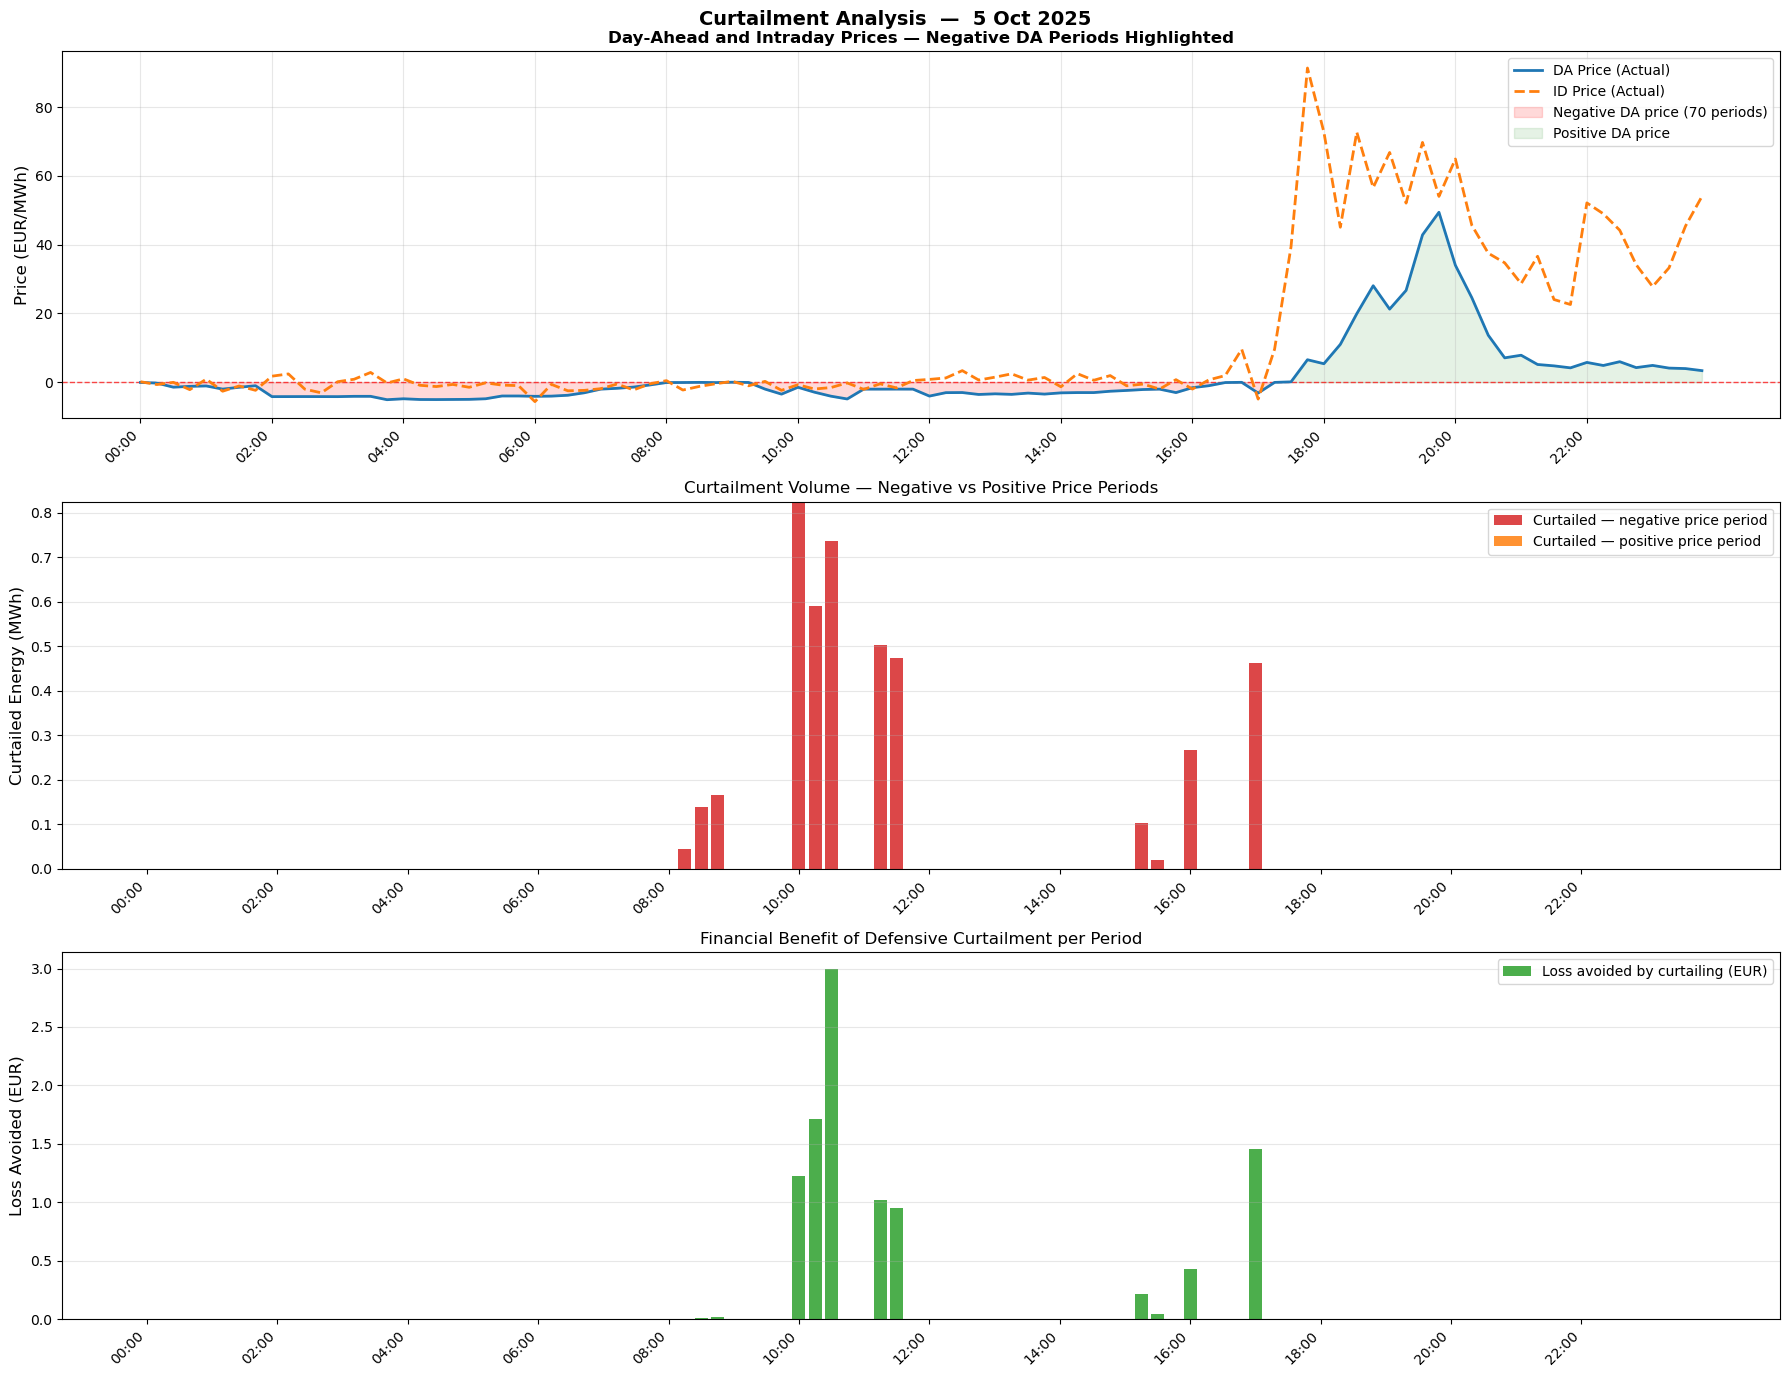

   CURTAILMENT SUMMARY
Negative DA price periods:          70 / 96
Periods curtailed (negative price): 12
Periods curtailed (positive price): 0
Total curtailed (negative price):   4.3286 MWh
Total curtailed (positive price):   0.0000 MWh
Total loss avoided:                 €10.0656


In [248]:
# ============================================================
# ADDITIONAL VISUALIZATION 4: CURTAILMENT ANALYSIS
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

df_curt = results_df.copy()
df_curt['curtailment_mwh'] = (
    (df_curt['Generation_Possible_MW'] - df_curt['Generation_Delivered_MW']) / 4
).clip(lower=0)
df_curt['negative_DA']       = df_curt['DA_Price_EUR_MWh'] < 0
df_curt['curtailed']         = df_curt['curtailment_mwh'] > 0.001
df_curt['neg_and_curtailed'] = df_curt['negative_DA'] & df_curt['curtailed']
df_curt['pos_and_curtailed'] = ~df_curt['negative_DA'] & df_curt['curtailed']
df_curt['loss_avoided_eur']  = np.where(
    df_curt['neg_and_curtailed'],
    df_curt['curtailment_mwh'] * df_curt['DA_Price_EUR_MWh'].abs(), 0
)

periods   = np.arange(len(df_curt))
time_lbls = [f"{i//4:02d}:{(i%4)*15:02d}" for i in range(96)]
tick_idx  = list(range(0, 96, 8))
tick_lbls = [time_lbls[i] for i in tick_idx]

fig, axes = plt.subplots(3, 1, figsize=(18, 14))
fig.suptitle('Curtailment Analysis  —  5 Oct 2025', fontsize=14, fontweight='bold')

# Plot 1: DA price and ID Price
ax1 = axes[0]
da_arr = np.array(df_curt['DA_Price_EUR_MWh'])

ax1.plot(periods, da_arr, color='#1F77B4', linewidth=2,
         label='DA Price (Actual)', zorder=3)
ax1.plot(periods, ID_p_actual, color='#FF7F0E', linewidth=2,
         linestyle='--', label='ID Price (Actual)', zorder=3)
ax1.axhline(0, color='red', linewidth=1, linestyle='--', alpha=0.7)
ax1.fill_between(periods, da_arr, 0,
                 where=(da_arr < 0), alpha=0.15, color='red',
                 label='Negative DA price (70 periods)')
ax1.fill_between(periods, da_arr, 0,
                 where=(da_arr >= 0), alpha=0.10, color='green',
                 label='Positive DA price')
ax1.set_ylabel('Price (EUR/MWh)', fontsize=12)
ax1.set_title('Day-Ahead and Intraday Prices — Negative DA Periods Highlighted',
              fontsize=12, fontweight='bold')
ax1.set_xticks(tick_idx)
ax1.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)

# Plot 2: Curtailment volume
ax2 = axes[1]
curt_neg = np.where(df_curt['neg_and_curtailed'], df_curt['curtailment_mwh'], 0)
curt_pos = np.where(df_curt['pos_and_curtailed'], df_curt['curtailment_mwh'], 0)
ax2.bar(periods, curt_neg, color='#D62728', alpha=0.85,
        label='Curtailed — negative price period')
ax2.bar(periods, curt_pos, color='#FF7F0E', alpha=0.85,
        label='Curtailed — positive price period', bottom=curt_neg)
ax2.set_ylabel('Curtailed Energy (MWh)', fontsize=12)
ax2.set_title('Curtailment Volume — Negative vs Positive Price Periods', fontsize=12)
ax2.set_xticks(tick_idx); ax2.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax2.legend(fontsize=10); ax2.grid(axis='y', alpha=0.3)

# Plot 3: Loss avoided
ax3 = axes[2]
ax3.bar(periods, df_curt['loss_avoided_eur'], color='#2CA02C', alpha=0.85,
        label='Loss avoided by curtailing (EUR)')
ax3.set_ylabel('Loss Avoided (EUR)', fontsize=12)
ax3.set_title('Financial Benefit of Defensive Curtailment per Period', fontsize=12)
ax3.set_xticks(tick_idx); ax3.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax3.legend(fontsize=10); ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('curtailment_3stage.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 60)
print('   CURTAILMENT SUMMARY')
print('=' * 60)
print(f"Negative DA price periods:          {df_curt['negative_DA'].sum()} / 96")
print(f"Periods curtailed (negative price): {df_curt['neg_and_curtailed'].sum()}")
print(f"Periods curtailed (positive price): {df_curt['pos_and_curtailed'].sum()}")
print(f"Total curtailed (negative price):   {curt_neg.sum():.4f} MWh")
print(f"Total curtailed (positive price):   {curt_pos.sum():.4f} MWh")
print(f"Total loss avoided:                 \u20ac{df_curt['loss_avoided_eur'].sum():.4f}")
print('=' * 60)

 ### aFRR Price Inputs

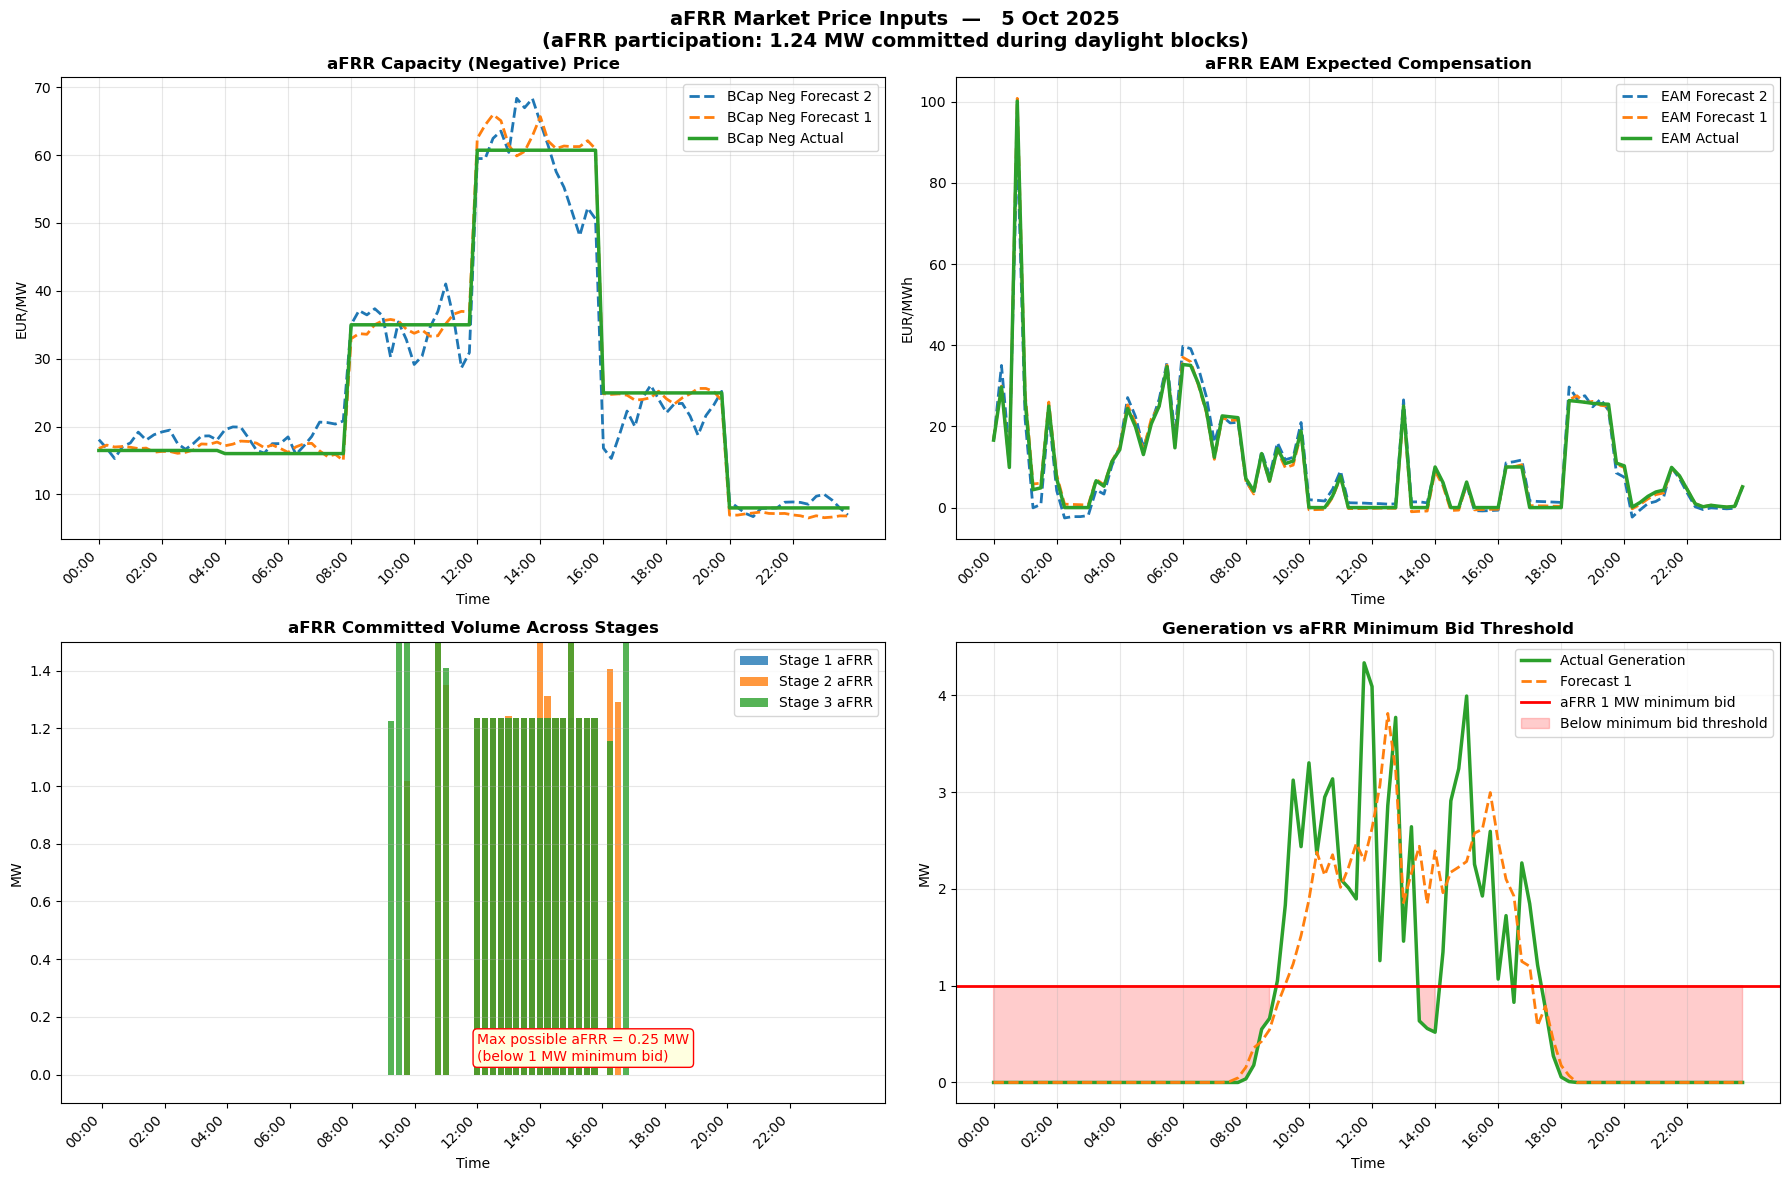

aFRR analysis saved.


In [250]:

import matplotlib.pyplot as plt
import numpy as np

periods   = np.arange(96)
time_lbls = [f"{i//4:02d}:{(i%4)*15:02d}" for i in range(96)]
tick_idx  = list(range(0, 96, 8))
tick_lbls = [time_lbls[i] for i in tick_idx]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('aFRR Market Price Inputs  —   5 Oct 2025\n(aFRR participation: 1.24 MW committed during daylight blocks)',
             fontsize=14, fontweight='bold')

# BCap Neg prices
ax = axes[0, 0]
ax.plot(periods, BCap_Neg_p_f2, color='#1F77B4', linewidth=2, linestyle='--', label='BCap Neg Forecast 2')
ax.plot(periods, BCap_Neg_p_f1, color='#FF7F0E', linewidth=2, linestyle='--', label='BCap Neg Forecast 1')
ax.plot(periods, BCap_Neg_p_actual, color='#2CA02C', linewidth=2.5, label='BCap Neg Actual')
ax.set_title('aFRR Capacity (Negative) Price', fontsize=12, fontweight='bold')
ax.set_ylabel('EUR/MW'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# EAM prices
ax = axes[0, 1]
ax.plot(periods, EAM_p_f2,     color='#1F77B4', linewidth=2, linestyle='--', label='EAM Forecast 2')
ax.plot(periods, EAM_p_f1,     color='#FF7F0E', linewidth=2, linestyle='--', label='EAM Forecast 1')
ax.plot(periods, EAM_p_actual, color='#2CA02C', linewidth=2.5, label='EAM Actual')
ax.set_title('aFRR EAM Expected Compensation', fontsize=12, fontweight='bold')
ax.set_ylabel('EUR/MWh'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

# aFRR results all stages
ax = axes[1, 0]
ax.bar(periods, aFRR_N_stage1_results, color='#1F77B4', alpha=0.8, label='Stage 1 aFRR')
ax.bar(periods, aFRR_N_stage2_results, color='#FF7F0E', alpha=0.8, label='Stage 2 aFRR')
ax.bar(periods, aFRR_N_stage3_results, color='#2CA02C', alpha=0.8, label='Stage 3 aFRR')
ax.set_title('aFRR Committed Volume Across Stages', fontsize=12, fontweight='bold')
ax.set_ylabel('MW'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.1, 1.5)
ax.annotate('Max possible aFRR = 0.25 MW\n(below 1 MW minimum bid)',
            xy=(48, 0.05), fontsize=10, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='red'))

# Generation vs capacity ceiling
ax = axes[1, 1]
capacity_line = [capacity * aFRR_reservation_margin] * 96
ax.plot(periods, Generation_actual, color='#2CA02C', linewidth=2.5, label='Actual Generation')
ax.plot(periods, Generation_f1, color='#FF7F0E', linewidth=2, linestyle='--', label='Forecast 1')
ax.axhline(y=1.0, color='red', linewidth=2, linestyle='-', label='aFRR 1 MW minimum bid')
ax.fill_between(periods, Generation_actual, 1.0,
                where=(np.array(Generation_actual) < 1.0),
                alpha=0.2, color='red', label='Below minimum bid threshold')
ax.set_title('Generation vs aFRR Minimum Bid Threshold', fontsize=12, fontweight='bold')
ax.set_ylabel('MW'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('afrr_analysis_3stage.png', dpi=150, bbox_inches='tight')
plt.show()
print('aFRR analysis saved.')

### Imbalance: Optimized vs Benchmark

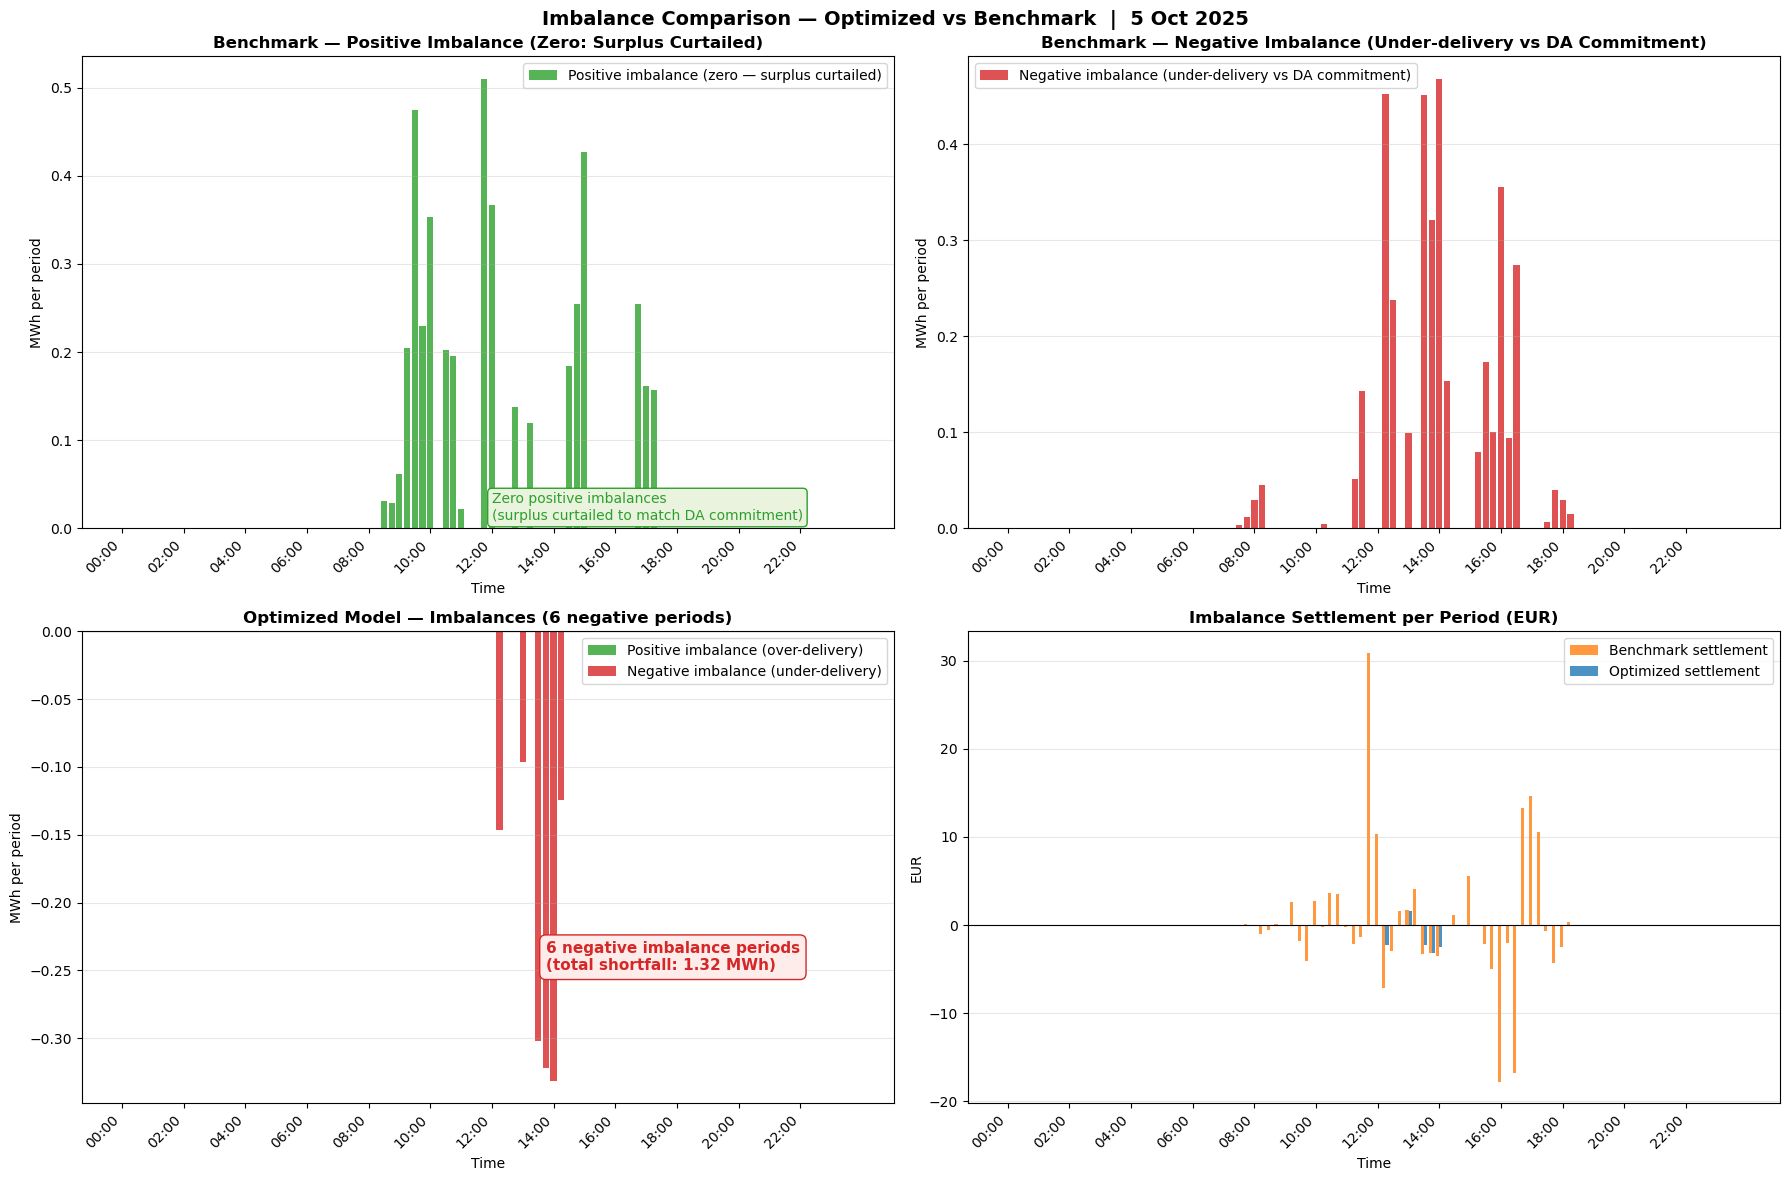

   IMBALANCE COMPARISON SUMMARY
Benchmark positive imbalance:  4.3763 MWh
Benchmark negative imbalance:  3.6425 MWh
Benchmark imbalance settlement: €23.7943
Optimized positive imbalance:  0.0000 MWh
Optimized negative imbalance:  1.3230 MWh
Optimized imbalance settlement: €-8.6435
=== BENCHMARK CORRECTION VERIFICATION ===
benchmark_imb_pos sum: 17.5050 MW  (should be 0.0000)
benchmark_imb_neg sum: 14.5700 MW
benchmark_total_revenue: €-13.36
benchmark_DA_revenue: €-45.89
benchmark_imb_settlement: €23.79


In [252]:

    import matplotlib.pyplot as plt
import numpy as np

periods   = np.arange(96)
time_lbls = [f"{i//4:02d}:{(i%4)*15:02d}" for i in range(96)]
tick_idx  = list(range(0, 96, 8))
tick_lbls = [time_lbls[i] for i in tick_idx]

benchmark_imb_pos_arr = np.array(benchmark_imb_pos)
benchmark_imb_neg_arr = np.array(benchmark_imb_neg)
opt_imb_pos_arr       = np.array(results_df['Imb_pos_MW'])
opt_imb_neg_arr       = np.array(results_df['Imb_neg_MW'])

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Imbalance Comparison — Optimized vs Benchmark  |  5 Oct 2025',
             fontsize=14, fontweight='bold')

# ── Benchmark positive imbalance ──────────────────────────────────────
ax = axes[0, 0]
ax.bar(periods, benchmark_imb_pos_arr / 4, color='#2CA02C', alpha=0.8,
       label='Positive imbalance (zero — surplus curtailed)')
ax.set_title('Benchmark — Positive Imbalance (Zero: Surplus Curtailed)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('MWh per period'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.annotate('Zero positive imbalances\n(surplus curtailed to match DA commitment)',
            xy=(48, 0.01), fontsize=10, color='#2CA02C',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#EAF3DE', edgecolor='#2CA02C'))

# ── Benchmark negative imbalance ──────────────────────────────────────
ax = axes[0, 1]
ax.bar(periods, benchmark_imb_neg_arr / 4, color='#D62728', alpha=0.8,
       label='Negative imbalance (under-delivery vs DA commitment)')
ax.set_title('Benchmark — Negative Imbalance (Under-delivery vs DA Commitment)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('MWh per period'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

# ── Optimized model ───────────────────────────────────────────────────
ax = axes[1, 0]
ax.bar(periods,  opt_imb_pos_arr / 4, color='#2CA02C', alpha=0.8,
       label='Positive imbalance (over-delivery)')
ax.bar(periods, -opt_imb_neg_arr / 4, color='#D62728', alpha=0.8,
       label='Negative imbalance (under-delivery)')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Optimized Model — Imbalances (6 negative periods)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('MWh per period'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
ax.annotate('6 negative imbalance periods\n(total shortfall: 1.32 MWh)',
            xy=(55, -0.25), fontsize=11, color='#D62728', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#FDECEA', edgecolor='#D62728'))

# ── Settlement comparison ─────────────────────────────────────────────
ax = axes[1, 1]
benchmark_settlement = (benchmark_imb_pos_arr * np.array(Imb_p_actual) / 4 -
                        benchmark_imb_neg_arr * np.array(Imb_p_actual) / 4)
opt_settlement = np.array(results_df['Imb_Settlement_EUR'])
ax.bar(periods - 0.2, benchmark_settlement, 0.4,
       color='#FF7F0E', alpha=0.8, label='Benchmark settlement')
ax.bar(periods + 0.2, opt_settlement, 0.4,
       color='#1F77B4', alpha=0.8, label='Optimized settlement')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Imbalance Settlement per Period (EUR)', fontsize=12, fontweight='bold')
ax.set_ylabel('EUR'); ax.set_xlabel('Time')
ax.set_xticks(tick_idx); ax.set_xticklabels(tick_lbls, rotation=45, ha='right')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('imbalance_comparison_3stage.png', dpi=150, bbox_inches='tight')
plt.show()

print('=' * 60)
print('   IMBALANCE COMPARISON SUMMARY')
print('=' * 60)
print(f"Benchmark positive imbalance:  {benchmark_imb_pos_arr.sum()/4:.4f} MWh")
print(f"Benchmark negative imbalance:  {benchmark_imb_neg_arr.sum()/4:.4f} MWh")
print(f"Benchmark imbalance settlement: €{benchmark_settlement.sum():.4f}")
print(f"Optimized positive imbalance:  {opt_imb_pos_arr.sum()/4:.4f} MWh")
print(f"Optimized negative imbalance:  {opt_imb_neg_arr.sum()/4:.4f} MWh")
print(f"Optimized imbalance settlement: €{opt_settlement.sum():.4f}")
print('=' * 60)

# Verify benchmark correction took effect
print("=== BENCHMARK CORRECTION VERIFICATION ===")
print(f"benchmark_imb_pos sum: {sum(benchmark_imb_pos):.4f} MW  (should be 0.0000)")
print(f"benchmark_imb_neg sum: {sum(benchmark_imb_neg):.4f} MW")
print(f"benchmark_total_revenue: €{benchmark_total_revenue:.2f}")
print(f"benchmark_DA_revenue: €{benchmark_DA_revenue:.2f}")
print(f"benchmark_imb_settlement: €{benchmark_imb_settlement:.2f}")

In [254]:
print("=== IMBALANCE CHECK ===")
print(f"Periods with Negative Imbalance: {sum(1 for x in Imb_neg_results if x > 0.001)}")
print(f"Periods with Positive Imbalance: {sum(1 for x in Imb_pos_results if x > 0.001)}")
print(f"Periods with No Imbalance:       {sum(1 for x in Imb_neg_results if x <= 0.001 and Imb_pos_results[Imb_neg_results.index(x)] <= 0.001)}")

=== IMBALANCE CHECK ===
Periods with Negative Imbalance: 6
Periods with Positive Imbalance: 0
Periods with No Imbalance:       90


In [256]:
import pandas as pd

print("=== PERIODS WITH NEGATIVE IMBALANCE ===")
for t in T:
    if Imb_neg_results[t] > 0.001:
        print(f"  Period {t:02d} ({t//4:02d}:{(t%4)*15:02d}) | "
              f"DA committed: {DA_stage2_results[t]:.3f} MW | "
              f"Actual gen: {Generation_actual[t]:.3f} MW | "
              f"Shortfall: {Imb_neg_results[t]:.3f} MW | "
              f"DA price: {DA_p_actual[t]:.2f} EUR/MWh")

=== PERIODS WITH NEGATIVE IMBALANCE ===
  Period 49 (12:15) | DA committed: 0.000 MW | Actual gen: 1.258 MW | Shortfall: 0.587 MW | DA price: -3.04 EUR/MWh
  Period 52 (13:00) | DA committed: 0.000 MW | Actual gen: 1.460 MW | Shortfall: 0.386 MW | DA price: -3.38 EUR/MWh
  Period 54 (13:30) | DA committed: 0.000 MW | Actual gen: 0.636 MW | Shortfall: 1.209 MW | DA price: -3.17 EUR/MWh
  Period 55 (13:45) | DA committed: 0.000 MW | Actual gen: 0.558 MW | Shortfall: 1.287 MW | DA price: -3.46 EUR/MWh
  Period 56 (14:00) | DA committed: 2.393 MW | Actual gen: 0.519 MW | Shortfall: 1.326 MW | DA price: -3.10 EUR/MWh
  Period 57 (14:15) | DA committed: 0.000 MW | Actual gen: 1.347 MW | Shortfall: 0.498 MW | DA price: -3.02 EUR/MWh


In [258]:
# ============================================================
# COMPLETE KPI SUMMARY — All 8 KPIs as defined in project report
# ============================================================
import numpy as np

# ── KPI 1: Total Trading Revenue ──────────────────────────
total_trading_revenue = results_df['Total_Revenue_EUR'].sum()

# ── KPI 2: Total Curtailment Volume ───────────────────────
total_curtailment_mwh = (
    (results_df['Generation_Possible_MW'] - results_df['Generation_Delivered_MW']) / 4
).clip(lower=0).sum()

# ── KPI 3: Offensive Curtailment Revenue ──────────────────
# BCap revenue: capacity payment (EUR/MW * MW committed)
aFRR_cap_revenue = sum(
    aFRR_N_stage1_results[t] * BCap_Neg_p_actual[t]
    for t in T
)
# EAM revenue: activation payment (EUR/MWh * MWh dispatched)
aFRR_eam_revenue = sum(
    aFRR_N_stage3_results[t] / 4 * EAM_p_actual[t]
    for t in T
)
offensive_curtailment_revenue = aFRR_cap_revenue + aFRR_eam_revenue

# ── KPI 4: Offensive Curtailment Volume ───────────────────
offensive_curtailment_mwh = sum(
    aFRR_N_stage3_results[t] / 4 for t in T
)

# ── KPI 5: Defensive Curtailment Savings ──────────────────
# Loss avoided by not selling into negative DA price periods
defensive_curtailment_savings = sum(
    max(0, -DA_p_actual[t]) * 
    max(0, (results_df['Generation_Possible_MW'].iloc[t] - 
            results_df['Generation_Delivered_MW'].iloc[t])) / 4
    for t in T
)

# ── KPI 6: Defensive Curtailment Volume ───────────────────
defensive_curtailment_mwh = sum(
    max(0, (results_df['Generation_Possible_MW'].iloc[t] - 
            results_df['Generation_Delivered_MW'].iloc[t])) / 4
    for t in T
    if DA_p_actual[t] < 0
)

# ── KPI 7: Negative Price EEG Revenue ─────────────────────
# By German EEG law, premium = 0 during negative DA price periods
# This is enforced in the model — value is 0 by definition
negative_price_eeg_revenue = 0.00
total_eeg_revenue = results_df['Market premium_EUR'].sum()

# ── KPI 8: EEG Avoided Curtailment Volume ─────────────────
# Periods where DA price was negative but generation was still
# delivered because EEG premium made it worthwhile
eeg_avoided_curtailment_mwh = sum(
    results_df['Generation_Delivered_MW'].iloc[t] / 4
    for t in T
    if DA_p_actual[t] < 0 and results_df['Generation_Delivered_MW'].iloc[t] > 0
)

# ── PRINT ALL 8 KPIs ──────────────────────────────────────
print("=" * 65)
print("   COMPLETE KPI SUMMARY — 5 October 2025  |  14.11 MW Asset")
print("=" * 65)
print(f"KPI 1 — Total Trading Revenue:              €{total_trading_revenue:.2f}")
print(f"KPI 2 — Total Curtailment Volume:           {total_curtailment_mwh:.4f} MWh")
print()
print(f"KPI 3 — Offensive Curtailment Revenue:")
print(f"         BCap (Capacity) Revenue:           €{aFRR_cap_revenue:.2f}")
print(f"         EAM (Activation) Revenue:          €{aFRR_eam_revenue:.2f}")
print(f"         Total Offensive Revenue:           €{offensive_curtailment_revenue:.2f}")
print()
print(f"KPI 4 — Offensive Curtailment Volume:       {offensive_curtailment_mwh:.4f} MWh")
print()
print(f"KPI 5 — Defensive Curtailment Savings:      €{defensive_curtailment_savings:.2f}")
print(f"KPI 6 — Defensive Curtailment Volume:       {defensive_curtailment_mwh:.4f} MWh")
print()
print(f"KPI 7 — Negative Price EEG Revenue:         €{negative_price_eeg_revenue:.2f}")
print(f"         (Premium = 0 during neg DA prices by German EEG law)")
print(f"         Total EEG Revenue (all periods):   €{total_eeg_revenue:.2f}")
print()
print(f"KPI 8 — EEG Avoided Curtailment Volume:     {eeg_avoided_curtailment_mwh:.4f} MWh")
print(f"         (Generation delivered despite neg DA price — EEG made it viable)")
print("=" * 65)
print(f"\nCross-check:")
print(f"  Offensive + Defensive curtailment:  {offensive_curtailment_mwh + defensive_curtailment_mwh:.4f} MWh")
print(f"  Total curtailment (KPI 2):          {total_curtailment_mwh:.4f} MWh")

   COMPLETE KPI SUMMARY — 5 October 2025  |  14.11 MW Asset
KPI 1 — Total Trading Revenue:              €25.71
KPI 2 — Total Curtailment Volume:           4.3286 MWh

KPI 3 — Offensive Curtailment Revenue:
         BCap (Capacity) Revenue:           €1200.94
         EAM (Activation) Revenue:          €44.86
         Total Offensive Revenue:           €1245.81

KPI 4 — Offensive Curtailment Volume:       8.0880 MWh

KPI 5 — Defensive Curtailment Savings:      €10.07
KPI 6 — Defensive Curtailment Volume:       4.3286 MWh

KPI 7 — Negative Price EEG Revenue:         €0.00
         (Premium = 0 during neg DA prices by German EEG law)
         Total EEG Revenue (all periods):   €8.74

KPI 8 — EEG Avoided Curtailment Volume:     14.9134 MWh
         (Generation delivered despite neg DA price — EEG made it viable)

Cross-check:
  Offensive + Defensive curtailment:  12.4166 MWh
  Total curtailment (KPI 2):          4.3286 MWh


In [259]:
# Verify total revenue including aFRR
total_including_aFRR = (
    results_df['Total_Revenue_EUR'].sum() + 
    aFRR_cap_revenue + 
    aFRR_eam_revenue
)
print(f"Stage 3 revenue (energy markets only):  €{results_df['Total_Revenue_EUR'].sum():.2f}")
print(f"aFRR BCap revenue (Stage 1 locked in):  €{aFRR_cap_revenue:.2f}")
print(f"aFRR EAM revenue (Stage 3):             €{aFRR_eam_revenue:.2f}")
print(f"TRUE total revenue (all markets):       €{total_including_aFRR:.2f}")
print(f"Stage 1 objective (should be close):    €1,276.75")

Stage 3 revenue (energy markets only):  €25.71
aFRR BCap revenue (Stage 1 locked in):  €1200.94
aFRR EAM revenue (Stage 3):             €44.86
TRUE total revenue (all markets):       €1271.52
Stage 1 objective (should be close):    €1,276.75


In [260]:
# ============================================================
# BCap and EAM Price Summary — All 6 Four-Hour Blocks
# ============================================================
import pandas as pd
import numpy as np

# BCap prices per 4-hour block
block_labels = [
    '00:00–04:00', '04:00–08:00', '08:00–12:00',
    '12:00–16:00', '16:00–20:00', '20:00–24:00'
]

# Get unique BCap prices per block
bcap_blocks = []
for b in range(6):
    block_start = b * 16
    block_end   = (b + 1) * 16
    block_price = BCap_Neg_p_actual[block_start]
    bcap_blocks.append(block_price)

# Get EAM prices per block
eam_blocks = []
for b in range(6):
    block_start = b * 16
    block_end   = (b + 1) * 16
    block_avg   = np.mean(EAM_p_actual[block_start:block_end])
    eam_blocks.append(block_avg)

# Print summary
print("=" * 60)
print("   BCap and EAM Price Summary — 5 October 2025")
print("=" * 60)
print(f"{'Block':<20} {'BCap (EUR/MW)':<20} {'EAM Avg (EUR/MWh)':<20}")
print("-" * 60)
for b in range(6):
    print(f"{block_labels[b]:<20} {bcap_blocks[b]:<20.2f} {eam_blocks[b]:<20.2f}")

print("-" * 60)
print(f"{'Overall Mean':<20} {np.mean(bcap_blocks):<20.2f} {np.mean(eam_blocks):<20.2f}")
print(f"{'Min':<20} {min(bcap_blocks):<20.2f} {min(eam_blocks):<20.2f}")
print(f"{'Max':<20} {max(bcap_blocks):<20.2f} {max(eam_blocks):<20.2f}")
print("=" * 60)

# Also print Forecast 2 values for comparison
print(f"\nForecast 2 BCap mean: {np.mean(BCap_Neg_p_f2):.4f} EUR/MW")
print(f"Forecast 2 EAM mean:  {np.mean(EAM_p_f2):.4f} EUR/MWh")
print(f"\nForecast 1 BCap mean: {np.mean(BCap_Neg_p_f1):.4f} EUR/MW")
print(f"Forecast 1 EAM mean:  {np.mean(EAM_p_f1):.4f} EUR/MWh")

   BCap and EAM Price Summary — 5 October 2025
Block                BCap (EUR/MW)        EAM Avg (EUR/MWh)   
------------------------------------------------------------
00:00–04:00          16.47                15.47               
04:00–08:00          16.01                23.17               
08:00–12:00          34.99                6.09                
12:00–16:00          60.72                2.97                
16:00–20:00          24.95                12.26               
20:00–24:00          8.00                 3.26                
------------------------------------------------------------
Overall Mean         26.86                10.53               
Min                  8.00                 2.97                
Max                  60.72                23.17               

Forecast 2 BCap mean: 26.6970 EUR/MW
Forecast 2 EAM mean:  10.6920 EUR/MWh

Forecast 1 BCap mean: 27.0571 EUR/MW
Forecast 1 EAM mean:  10.5183 EUR/MWh


In [261]:
# ============================================================
# Price Statistics During Generation Periods Only
# ============================================================
import numpy as np

gen_mask = np.array(Generation_actual) > 0
gen_periods = sum(gen_mask)

da_gen  = np.array(DA_p_actual)[gen_mask]
id_gen  = np.array(ID_p_actual)[gen_mask]

print("=" * 60)
print("   PRICE STATISTICS DURING GENERATION PERIODS")
print(f"   ({gen_periods} periods with active generation)")
print("=" * 60)
print(f"\nDA Price during generation periods:")
print(f"  Mean:     {np.mean(da_gen):.2f} EUR/MWh")
print(f"  Median:   {np.median(da_gen):.2f} EUR/MWh")
print(f"  Min:      {np.min(da_gen):.2f} EUR/MWh")
print(f"  Max:      {np.max(da_gen):.2f} EUR/MWh")
print(f"  Negative: {sum(da_gen < 0)}/{gen_periods} periods")

print(f"\nID Price during generation periods:")
print(f"  Mean:     {np.mean(id_gen):.2f} EUR/MWh")
print(f"  Median:   {np.median(id_gen):.2f} EUR/MWh")
print(f"  Min:      {np.min(id_gen):.2f} EUR/MWh")
print(f"  Max:      {np.max(id_gen):.2f} EUR/MWh")
print(f"  Negative: {sum(id_gen < 0)}/{gen_periods} periods")
print("=" * 60)

   PRICE STATISTICS DURING GENERATION PERIODS
   (42 periods with active generation)

DA Price during generation periods:
  Mean:     -1.40 EUR/MWh
  Median:   -2.02 EUR/MWh
  Min:      -4.88 EUR/MWh
  Max:      11.00 EUR/MWh
  Negative: 38/42 periods

ID Price during generation periods:
  Mean:     6.22 EUR/MWh
  Median:   0.46 EUR/MWh
  Min:      -4.91 EUR/MWh
  Max:      91.36 EUR/MWh
  Negative: 18/42 periods
